# Systematic Trading Strategies with Machine Learning  
## Coursework Project – Meta-Labeling for Trading Signal Filtering

---

# 1. Project Overview

The objective of this project is to build a **metamodel** on top of a provided primary trading signal across futures contracts from multiple asset classes.

The primary model generates daily trading signals in \(\{-1,0,+1\}\):
- \(+1\): long signal
- \(-1\): short signal
- \(0\): no position

Our goal is **not** to predict returns directly.  
Instead, we aim to estimate the probability that a given primary signal is worth taking under a triple-barrier labeling framework.

More formally, we seek to model:

\[
P(\text{Trade is profitable} \mid \text{Features})
\]

using machine learning techniques.

---

# 2. Project Pipeline

The project is structured into the following stages:

## Phase 1 — Data Preparation and Exploration
- Load and clean OHLCV data
- Load and align primary signals
- Verify data integrity and temporal consistency
- Explore the characteristics of each asset class

## Phase 2 — Feature Engineering
Construction of predictive features from market data, including:
- Technical indicators
- Volatility and momentum features
- Cross-sectional features
- Latent regime features (HMM/GMM)
- Additional engineered features

## Phase 3 — Triple-Barrier Labeling
Implementation of the triple-barrier method to define supervised learning targets:
- Profit-taking barrier
- Stop-loss barrier
- Maximum holding period

We will justify all parameter choices economically and statistically.

## Phase 4 — Model Development
We will compare several model families:
- Linear models
- Tree-based ensemble methods
- Neural networks

Hyperparameter tuning and robust validation procedures will be applied.

## Phase 5 — Feature Importance Analysis
We will study:
- Individual feature importance
- Cluster-level feature importance
- SHAP/permutation-based interpretability

## Phase 6 — Out-of-Sample Evaluation
Evaluation on a clean out-of-sample period using:
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrices
- Comparison against the raw primary signal

## Optional Phase 7 — Strategy Construction
(Optional competition track)

Construction of a position-sizing strategy using metamodel probabilities.

---

# 3. Methodological Principles

Throughout the project, particular attention will be paid to:
- Avoiding look-ahead bias
- Preventing data leakage
- Using time-aware validation procedures
- Ensuring reproducibility
- Maintaining economic interpretability of results

The emphasis of this coursework is placed on:
- methodological rigor,
- feature engineering quality,
- validation protocol,
- and critical analysis of results.

---

# 4. Asset Universe

The project covers futures contracts from three asset classes:

## Equity Index Futures
- ES1S — S&P 500
- NQ1S — Nasdaq 100
- FESX1S — Euro Stoxx 50

## Energy
- CL1S — WTI Crude Oil
- HO1S — Heating Oil
- RB1S — RBOB Gasoline
- NG1S — Natural Gas

## Metals
- GC1S — Gold
- SI1S — Silver
- HG1S — Copper
- PL1S — Platinum

---

# 5. Initial Setup

We begin by importing the required libraries and loading the datasets.

# Phase 1 — Data Preparation and Initial Exploration

In this first phase, we prepare the raw datasets for the meta-labeling pipeline.

We focus initially on the **Energy** asset class:

| Ticker | Commodity |
|---|---|
| CL1S | WTI Crude Oil |
| HO1S | Heating Oil |
| RB1S | RBOB Gasoline |
| NG1S | Natural Gas |

The objectives of this phase are:

1. Load the OHLCV dataset and the primary signals dataset.
2. Standardize dates, instrument names, and column formats.
3. Filter the universe to Energy instruments only.
4. Align market data and primary signals on a common trading calendar.
5. Perform basic data integrity checks:
   - missing values,
   - duplicated rows,
   - date coverage,
   - signal distribution,
   - price and volume sanity checks.
6. Prepare a clean base dataframe that will later be used for feature engineering and triple-barrier labeling.

At this stage, we do **not** create labels yet.  
The purpose is to build a clean, reliable data foundation before moving to feature engineering.

In [ ]:
from numpy import lib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import statsmodels.api as sm1
import talib
from hmmlearn.hmm import GaussianHMM
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

In [98]:
# ============================================================
# Phase 1 — Setup and Data Loading
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# ------------------------------------------------------------
# Project configuration
# ------------------------------------------------------------

DATA_DIR = "."  # Change this path if your CSV files are in another folder

OHLCV_FILE = os.path.join(DATA_DIR, "ohlcv_data.csv")
SIGNALS_FILE = os.path.join(DATA_DIR, "primary_signals.csv")

ENERGY_INSTRUMENTS = ["cl1s", "ho1s", "rb1s", "ng1s"]

INSTRUMENT_NAMES = {
    "cl1s": "WTI Crude Oil",
    "ho1s": "Heating Oil",
    "rb1s": "RBOB Gasoline",
    "ng1s": "Natural Gas",
}

print("Energy universe:")
for ticker, name in INSTRUMENT_NAMES.items():
    print(f"- {ticker.upper()}: {name}")

Energy universe:
- CL1S: WTI Crude Oil
- HO1S: Heating Oil
- RB1S: RBOB Gasoline
- NG1S: Natural Gas


In [99]:
# ============================================================
# Load Raw Data
# ============================================================

ohlcv_raw = pd.read_csv(OHLCV_FILE)
signals_raw = pd.read_csv(SIGNALS_FILE)

print("OHLCV shape:", ohlcv_raw.shape)
print("Signals shape:", signals_raw.shape)

display(ohlcv_raw.head())
display(signals_raw.head())

OHLCV shape: (83547, 8)
Signals shape: (645, 12)


,date,instrument,open,high,low,close,volume,open_interest
0,1990-01-02,cl1s,21.8000,22.920,21.7900,22.8900,22868.0,66308.0
1,1990-01-02,gc1s,401.0000,404.600,400.2000,402.1000,20747.0,68855.0
2,1990-01-02,hg1s,1.0470,1.064,1.0430,1.0620,3325.0,19735.0
3,1990-01-02,ho1s,0.7475,0.776,0.7415,0.7739,20280.0,33732.0
4,1990-01-02,pl1s,484.0000,485.000,479.5000,482.2000,4561.0,13256.0


,date,es1s,nq1s,fesx1s,cl1s,ho1s,rb1s,ng1s,gc1s,si1s,hg1s,pl1s
0,2020-01-03,1,1,-1,0,0,1,0,0,1,1,-1
1,2020-01-06,1,-1,1,0,0,1,0,0,1,1,1
2,2020-01-07,1,-1,1,-1,0,-1,0,0,1,1,1
3,2020-01-08,1,1,1,0,0,1,0,0,1,1,1
4,2020-01-09,1,-1,-1,0,0,1,0,0,1,1,1


## 1.1 Initial Data Standardization

We now standardize the two datasets:

- convert dates to `datetime`,
- convert instrument names to lowercase,
- sort observations chronologically,
- filter the OHLCV data and primary signals to the Energy instruments only.

This ensures that both datasets use the same naming convention and can later be merged safely.

In [100]:
# ============================================================
# Standardize Dates and Instrument Names
# ============================================================

ohlcv = ohlcv_raw.copy()
signals = signals_raw.copy()

# Convert date columns
ohlcv["date"] = pd.to_datetime(ohlcv["date"])
signals["date"] = pd.to_datetime(signals["date"])

# Standardize instrument names
ohlcv["instrument"] = ohlcv["instrument"].str.lower()

# Keep only Energy instruments
ohlcv_energy = ohlcv[ohlcv["instrument"].isin(ENERGY_INSTRUMENTS)].copy()

# Keep date + Energy signal columns
signals_energy = signals[["date"] + ENERGY_INSTRUMENTS].copy()

# Sort
ohlcv_energy = ohlcv_energy.sort_values(["instrument", "date"]).reset_index(drop=True)
signals_energy = signals_energy.sort_values("date").reset_index(drop=True)

print("Energy OHLCV shape:", ohlcv_energy.shape)
print("Energy signals shape:", signals_energy.shape)

display(ohlcv_energy.head())
display(signals_energy.head())

Energy OHLCV shape: (32614, 8)
Energy signals shape: (645, 5)


,date,instrument,open,high,low,close,volume,open_interest
0,1990-01-02,cl1s,21.80,22.92,21.79,22.89,22868.0,66308.0
1,1990-01-03,cl1s,23.20,23.80,23.00,23.68,45177.0,61428.0
2,1990-01-04,cl1s,23.88,23.92,22.83,23.41,50061.0,60995.0
3,1990-01-05,cl1s,23.42,23.70,23.03,23.08,53070.0,57258.0
4,1990-01-08,cl1s,22.60,22.60,21.55,21.62,39720.0,54644.0


,date,cl1s,ho1s,rb1s,ng1s
0,2020-01-03,0,0,1,0
1,2020-01-06,0,0,1,0
2,2020-01-07,-1,0,-1,0
3,2020-01-08,0,0,1,0
4,2020-01-09,0,0,1,0


## 1.2 Data Integrity Checks

Before creating features or labels, we first verify the quality of the raw Energy datasets.

We check:
- date coverage by instrument,
- duplicated observations,
- missing values,
- OHLCV consistency,
- and primary signal distributions.

These checks are important because any data issue at this stage could later create misleading labels, feature leakage, or incorrect model evaluation.

In [101]:
# ============================================================
# Basic Data Integrity Checks
# ============================================================

print("OHLCV date range by instrument:")
display(
    ohlcv_energy
    .groupby("instrument")["date"]
    .agg(["min", "max", "count"])
)

print("\nSignals date range:")
display(
    signals_energy["date"].agg(["min", "max", "count"])
)

print("\nDuplicate OHLCV rows by (date, instrument):")
n_dup_ohlcv = ohlcv_energy.duplicated(subset=["date", "instrument"]).sum()
print(n_dup_ohlcv)

print("\nDuplicate signal dates:")
n_dup_signals = signals_energy.duplicated(subset=["date"]).sum()
print(n_dup_signals)

print("\nMissing values in OHLCV:")
display(ohlcv_energy.isna().sum())

print("\nMissing values in signals:")
display(signals_energy.isna().sum())

OHLCV date range by instrument:


,min,max,count
instrument,,,
cl1s,1990-01-02,2022-06-30,8171
ho1s,1990-01-02,2022-06-30,8169
ng1s,1990-04-04,2022-06-30,8104
rb1s,1990-01-02,2022-06-30,8170



Signals date range:


min      2020-01-03 00:00:00
max      2022-06-30 00:00:00
count                    645
Name: date, dtype: object


Duplicate OHLCV rows by (date, instrument):
0

Duplicate signal dates:
0

Missing values in OHLCV:


date             0
instrument       0
open             0
high             0
low              0
close            0
volume           0
open_interest    0
dtype: int64


Missing values in signals:


date    0
cl1s    0
ho1s    0
rb1s    0
ng1s    0
dtype: int64

## 1.3 Signal Distribution Analysis

Before building labels or training models, we inspect the distribution of the primary signals.

This is important because:
- the dataset may be imbalanced,
- some instruments may trade much more frequently than others,
- and the proportion of long/short/flat signals may affect both labeling and model performance.

We therefore compute the distribution of:
- long signals (+1),
- short signals (-1),
- and inactive periods (0),
for each Energy instrument.

In [102]:
# ============================================================
# Signal Distribution
# ============================================================

signal_distribution = {}

for inst in ENERGY_INSTRUMENTS:
    
    counts = (
        signals_energy[inst]
        .value_counts()
        .sort_index()
    )
    
    signal_distribution[inst] = counts

    print(f"\n{inst.upper()} signal distribution:")
    print(counts)

    print("\nPercentages:")
    print((counts / counts.sum() * 100).round(2))


CL1S signal distribution:
cl1s
-1     36
 0    223
 1    386
Name: count, dtype: int64

Percentages:
cl1s
-1     5.58
 0    34.57
 1    59.84
Name: count, dtype: float64

HO1S signal distribution:
ho1s
-1     10
 0    582
 1     53
Name: count, dtype: int64

Percentages:
ho1s
-1     1.55
 0    90.23
 1     8.22
Name: count, dtype: float64

RB1S signal distribution:
rb1s
-1    261
 0     17
 1    367
Name: count, dtype: int64

Percentages:
rb1s
-1    40.47
 0     2.64
 1    56.90
Name: count, dtype: float64

NG1S signal distribution:
ng1s
-1    124
 0    521
Name: count, dtype: int64

Percentages:
ng1s
-1    19.22
 0    80.78
Name: count, dtype: float64


## 1.4 OHLC Consistency Checks

We now perform several sanity checks on the OHLC data.

For each observation, financial market conventions imply:


$\text{low} \leq \text{open, close} \leq \text{high}$


Violations of these inequalities may indicate:
- corrupted observations,
- bad data adjustments,
- or preprocessing issues.

We also verify that prices and trading activity remain strictly positive.

In [103]:
# ============================================================
# OHLC Consistency Checks
# ============================================================

# High should be >= low
invalid_high_low = (ohlcv_energy["high"] < ohlcv_energy["low"]).sum()

# Open should lie inside [low, high]
invalid_open = (
    (ohlcv_energy["open"] < ohlcv_energy["low"]) |
    (ohlcv_energy["open"] > ohlcv_energy["high"])
).sum()

# Close should lie inside [low, high]
invalid_close = (
    (ohlcv_energy["close"] < ohlcv_energy["low"]) |
    (ohlcv_energy["close"] > ohlcv_energy["high"])
).sum()

# Negative or zero prices
non_positive_prices = (
    (ohlcv_energy[["open", "high", "low", "close"]] <= 0)
    .sum()
    .sum()
)

print("Invalid high/low rows:", invalid_high_low)
print("Invalid open rows:", invalid_open)
print("Invalid close rows:", invalid_close)
print("Non-positive prices:", non_positive_prices)

Invalid high/low rows: 0
Invalid open rows: 0
Invalid close rows: 0
Non-positive prices: 0


## 1.5 Price Series Visualization

We now visualize the historical closing prices of the Energy futures contracts.

The objective is not yet predictive modeling, but rather:
- understanding the long-term behavior of each market,
- identifying volatility regimes,
- detecting structural breaks and crises,
- and building intuition about the data before feature engineering.

Since commodity futures can exhibit very different scales and volatility levels, each instrument is plotted separately.

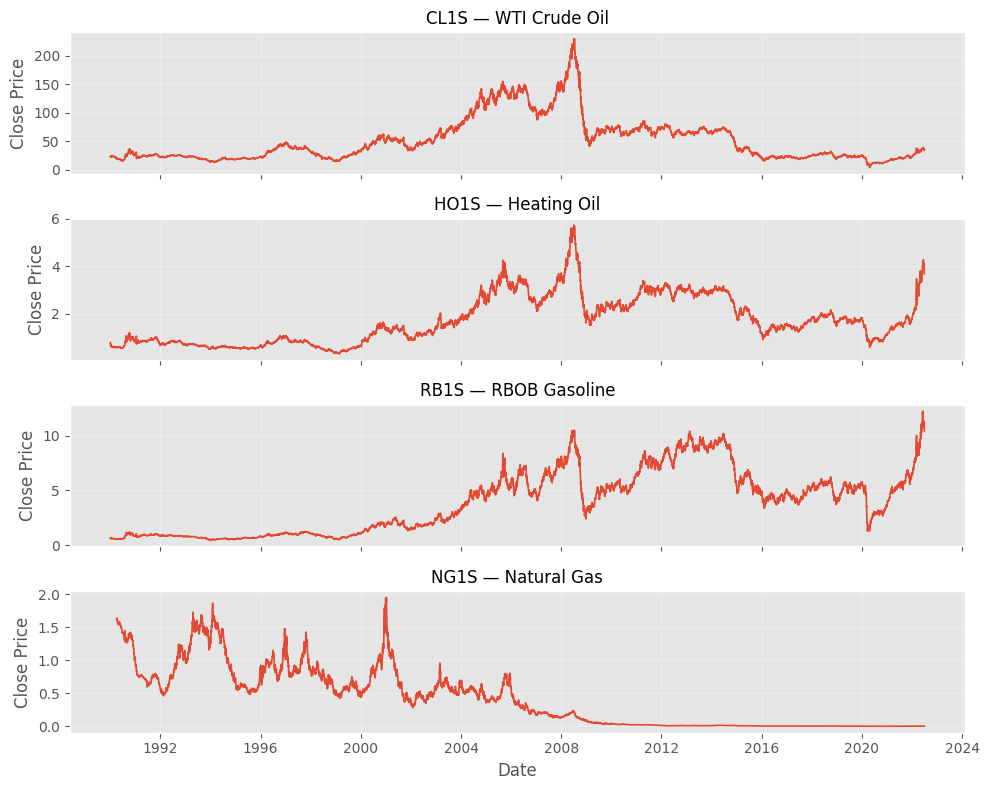

In [104]:
# ============================================================
# Historical Price Visualization
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(10, 8),
    sharex=True
)

for ax, inst in zip(axes, ENERGY_INSTRUMENTS):

    df_inst = ohlcv_energy[
        ohlcv_energy["instrument"] == inst
    ]

    ax.plot(
        df_inst["date"],
        df_inst["close"],
        linewidth=1.2
    )

    ax.set_title(
        f"{inst.upper()} — {INSTRUMENT_NAMES[inst]}",
        fontsize=12
    )

    ax.set_ylabel("Close Price")

    ax.grid(True, alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

## 1.6 Return Series Construction

Financial machine learning models are generally built on returns rather than raw price levels.

We therefore compute daily log returns for each instrument:

$$
r_t = \log\left(\frac{P_t}{P_{t-1}}\right)
$$

Log returns are preferred because:
- they are additive through time,
- more statistically stable than prices,
- and largely invariant to the absolute price scale.

This is particularly important for futures contracts, where continuous-contract adjustments may distort long-term price levels.

In [105]:
# ============================================================
# Daily Log Returns
# ============================================================

ohlcv_energy["log_return"] = (
    ohlcv_energy
    .groupby("instrument")["close"]
    .transform(lambda x: np.log(x / x.shift(1)))
)

display(
    ohlcv_energy[
        ["date", "instrument", "close", "log_return"]
    ].head(10)
)

,date,instrument,close,log_return
0,1990-01-02,cl1s,22.89,NaN
1,1990-01-03,cl1s,23.68,0.033931
2,1990-01-04,cl1s,23.41,-0.011468
3,1990-01-05,cl1s,23.08,-0.014197
4,1990-01-08,cl1s,21.62,-0.065348
5,1990-01-09,cl1s,22.07,0.020600
6,1990-01-10,cl1s,22.90,0.036918
7,1990-01-11,cl1s,23.14,0.010426
8,1990-01-12,cl1s,23.13,-0.000432
9,1990-01-15,cl1s,22.36,-0.033857


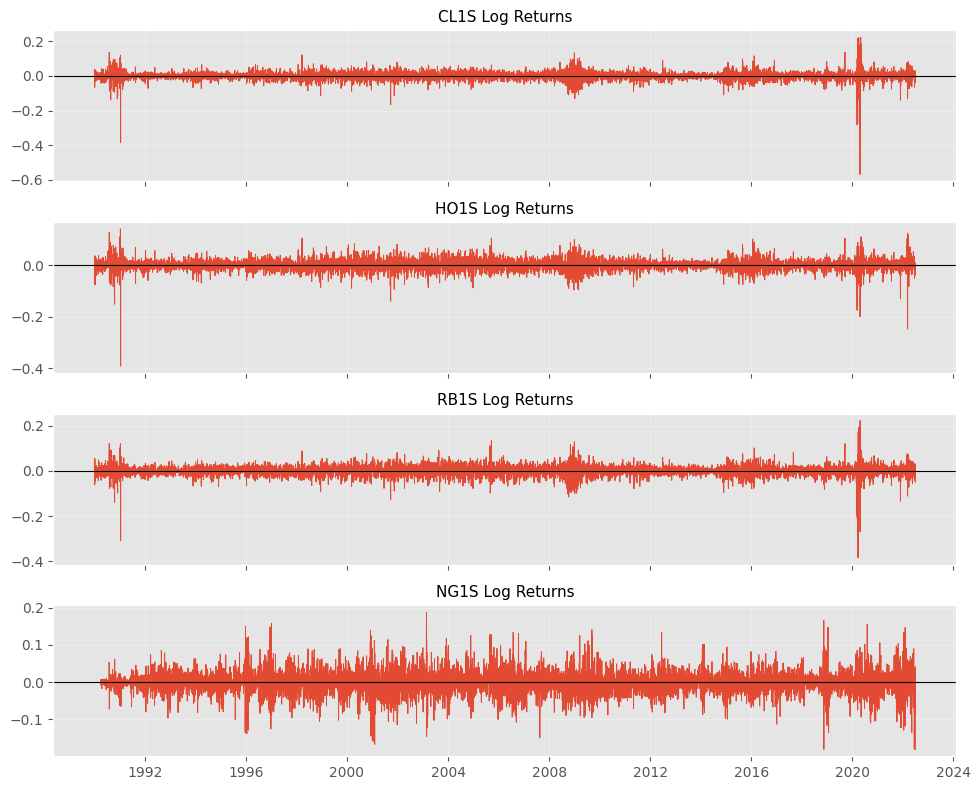

In [106]:
# ============================================================
# Log Return Visualization
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(10, 8),
    sharex=True
)

for ax, inst in zip(axes, ENERGY_INSTRUMENTS):

    df_inst = ohlcv_energy[
        ohlcv_energy["instrument"] == inst
    ]

    ax.plot(
        df_inst["date"],
        df_inst["log_return"],
        linewidth=0.7
    )

    ax.set_title(
        f"{inst.upper()} Log Returns",
        fontsize=11
    )

    ax.axhline(0, color="black", linewidth=0.8)

    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.7 Reshaping Primary Signals

The primary signal dataset is currently stored in a wide format:

| date | cl1s | ho1s | rb1s | ng1s |
|---|---|---|---|---|

However, the OHLCV dataset is stored in long format:

| date | instrument | open | high | low | close | ... |

To simplify merging and downstream processing, we reshape the signal dataset into long format using `pandas.melt()`.

The resulting structure becomes:

| date | instrument | signal |
|---|---|---|

This representation is much more convenient for:
- feature engineering,
- labeling,
- merging datasets,
- and machine learning pipelines.

In [107]:
# ============================================================
# Reshape Signals to Long Format
# ============================================================

signals_long = signals_energy.melt(
    id_vars="date",
    value_vars=ENERGY_INSTRUMENTS,
    var_name="instrument",
    value_name="primary_signal"
)

signals_long = (
    signals_long
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Signals long shape:", signals_long.shape)

display(signals_long.head(10))

Signals long shape: (2580, 3)


,date,instrument,primary_signal
0,2020-01-03,cl1s,0
1,2020-01-06,cl1s,0
2,2020-01-07,cl1s,-1
3,2020-01-08,cl1s,0
4,2020-01-09,cl1s,0
5,2020-01-10,cl1s,0
6,2020-01-13,cl1s,0
7,2020-01-14,cl1s,0
8,2020-01-15,cl1s,0
9,2020-01-16,cl1s,0


# Phase 2 — Feature Engineering

In this phase, we construct predictive features from the Energy OHLCV dataset.

The objective is to describe the market environment in which each primary signal occurs.  
These features will later be used by the metamodel to estimate whether a given primary trading signal is worth taking.

We construct features separately for each instrument, using only past and current information available at each date.  
This is essential to avoid look-ahead bias.

The feature engineering process is organized into several blocks:

1. **Core return and momentum features**
   - daily returns,
   - rolling cumulative returns,
   - short-term and medium-term momentum.

2. **Volatility features**
   - rolling realized volatility,
   - volatility ratios,
   - volatility regime indicators.

3. **Volume and open-interest features**
   - volume changes,
   - volume z-scores,
   - open-interest changes.

4. **Technical indicators**
   - RSI,
   - MACD,
   - Bollinger-style z-scores.

5. **Time-series dependence features**
   - rolling autocorrelation,
   - volatility clustering proxies,
   - trend persistence measures.

6. **Cross-sectional features**
   - relative momentum,
   - relative volatility,
   - ranks within the Energy asset class.

7. **Latent regime features**
   - GMM/HMM-based regime probabilities,
   - market turbulence indicators.

At this stage, we start with a robust set of core statistical features before adding more advanced indicators.

## 2.1 Core Return and Momentum Features

We begin with a set of core return-based and momentum features.

Momentum features aim to capture whether an instrument has recently experienced persistent positive or negative price movements.  
Such features are widely used in systematic trading strategies, where trend-following and persistence effects often play an important role.

For each instrument, we compute rolling momentum over several horizons:

$$
\text{mom}_{k,t}
=
\log\left(\frac{P_t}{P_{t-k}}\right)
$$

where:
- \(P_t\) is the closing price at time \(t\),
- and \(k\) represents the lookback horizon.

We use multiple horizons in order to capture:
- short-term momentum,
- medium-term trends,
- and longer-term price persistence.

In addition, we compute rolling average returns:

$$
\bar r_t^{(k)}
=
\frac{1}{k}
\sum_{i=0}^{k-1} r_{t-i}
$$

which provide smoother estimates of recent market direction and local return persistence.

All features are computed independently for each instrument using:

```python
groupby("instrument")

In [108]:
# ============================================================
# Phase 2 — Feature Engineering Setup
# ============================================================

features_df = ohlcv_energy.copy()

# Make sure data is sorted before computing rolling/grouped features
features_df = (
    features_df
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Feature engineering base shape:", features_df.shape)
display(features_df.head())

Feature engineering base shape: (32614, 9)


,date,instrument,open,high,low,close,volume,open_interest,log_return
0,1990-01-02,cl1s,21.80,22.92,21.79,22.89,22868.0,66308.0,NaN
1,1990-01-03,cl1s,23.20,23.80,23.00,23.68,45177.0,61428.0,0.033931
2,1990-01-04,cl1s,23.88,23.92,22.83,23.41,50061.0,60995.0,-0.011468
3,1990-01-05,cl1s,23.42,23.70,23.03,23.08,53070.0,57258.0,-0.014197
4,1990-01-08,cl1s,22.60,22.60,21.55,21.62,39720.0,54644.0,-0.065348


In [109]:
# ==============================================================================
# PHASE 2 - UNIFIED ADVANCED FEATURE ENGINEERING (TALIB & PRADO FRAMEWORK)
# ==============================================================================
import numpy as np
import pandas as pd
import talib
import scipy.stats as stats
import statsmodels.tsa.stattools as ts
from joblib import Parallel, delayed


# ==============================================================================
# FONCTIONS PRADO
# ==============================================================================

def calculate_sharpe_ratio(returns, rf_rate=0.0, periods=252, annualized=True):
    excess = returns - rf_rate
    std = excess.std(ddof=1)
    if std == 0 or np.isnan(std): return np.nan
    sr = excess.mean() / std
    return sr * np.sqrt(periods) if annualized else sr

def calculate_sortino_ratio(returns, rf_rate=0.0, periods=252, annualized=True):
    excess = returns - rf_rate
    downside = excess[excess < 0]
    if len(downside) < 2: return np.nan
    downside_std = np.sqrt(np.mean(downside**2))
    if downside_std == 0 or np.isnan(downside_std): return np.nan
    sortino = excess.mean() / downside_std
    return sortino * np.sqrt(periods) if annualized else sortino

def calculate_probabilistic_sharpe_ratio(returns, benchmark_sr=0.0, periods=252):
    t = len(returns)
    if t < 5: return np.nan
    sr_est = calculate_sharpe_ratio(returns, annualized=False)
    if np.isnan(sr_est): return np.nan
    sr_bench = benchmark_sr / np.sqrt(periods)
    skew = returns.skew()
    kurt = returns.kurtosis() + 3
    denom = 1.0 - skew * sr_est + ((kurt - 1.0) / 4.0) * sr_est**2
    if denom <= 0: return np.nan
    std_sr = np.sqrt(denom / (t - 1.0))
    return stats.norm.cdf((sr_est - sr_bench) / std_sr)

def calculate_deflated_sharpe_ratio(returns, all_trial_sharpes, periods=252):
    n = len(all_trial_sharpes)
    if n <= 1:
        return calculate_probabilistic_sharpe_ratio(returns, benchmark_sr=0.0, periods=periods)
    deann = all_trial_sharpes / np.sqrt(periods)
    var_sr = np.var(deann, ddof=1)
    ec = 0.5772156649
    z_n  = stats.norm.ppf(1.0 - 1.0 / n)
    z_ne = stats.norm.ppf(1.0 - 1.0 / (n * np.e))
    expected_max = np.sqrt(var_sr) * ((1 - ec) * z_n + ec * z_ne)
    return calculate_probabilistic_sharpe_ratio(returns, benchmark_sr=expected_max * np.sqrt(periods), periods=periods)

def cusum_filter(prices, threshold):
    s_pos = s_neg = 0.0
    events = []
    for date, ret in np.log(prices / prices.shift(1)).dropna().items():
        s_pos = max(0.0, s_pos + ret)
        s_neg = min(0.0, s_neg + ret)
        if s_pos > threshold:
            s_pos = 0.0; events.append(date)
        elif s_neg < -threshold:
            s_neg = 0.0; events.append(date)
    return pd.Index(events)

def lempel_ziv_complexity(seq):
    i, c, u, v, v_max, n = 0, 1, 1, 1, 1, len(seq)
    if n == 0: return 0
    while u + v <= n:
        if seq[i + v - 1] == seq[u + v - 1]:
            v += 1
        else:
            v_max = max(v_max, v); i += 1
            if i == u:
                c += 1; u += v_max; v = v_max = 1; i = 0
            else:
                v = 1
    return c + (v != 1)

def frac_diff_ffd(series, d, thres=1e-5):
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < thres: break
        w.append(w_k); k += 1
    w = np.array(w[::-1]); width = len(w) - 1
    out = pd.Series(index=series.index, dtype=float)
    for i in range(width, len(series)):
        out.iloc[i] = np.dot(w, series.iloc[i - width:i + 1].values)
    return out

def shannon_entropy_vectorized(series, window, bins=10):
    arr = series.values
    result = np.full(len(arr), np.nan)
    for i in range(window - 1, len(arr)):
        x = arr[i - window + 1:i + 1]
        x = x[~np.isnan(x)]
        if len(x) == 0: continue
        hist, _ = np.histogram(x, bins=bins)
        p = hist[hist > 0].astype(float); p /= p.sum()
        result[i] = -np.sum(p * np.log2(p))
    return pd.Series(result, index=series.index)

def lz_rolling_fast(series, window):
    binary = (series.values > 0).astype(int)
    result = np.full(len(binary), np.nan)
    for i in range(window - 1, len(binary)):
        seq = ''.join(map(str, binary[i - window + 1:i + 1]))
        result[i] = lempel_ziv_complexity(seq)
    return pd.Series(result, index=series.index)

def sadf_rolling(close, step=5):
    """SADF calculé tous les `step` jours puis forward-fillé — x5 plus rapide."""
    sadf_vals = np.full(len(close), np.nan)
    for i in range(25, len(close), step):
        window = close.iloc[max(0, i - 252):i].values
        try:
            sadf_vals[i] = ts.adfuller(window, maxlag=1, autolag=None)[0]
        except Exception:
            pass
    out = pd.Series(sadf_vals, index=close.index)
    return out.ffill()


# ==============================================================================
# FONCTION PRINCIPALE PAR INSTRUMENT (pour joblib)
# ==============================================================================

def compute_instrument_features(name, df):
    print(f"  → {name}...")

    # --- Microstructure ---
    df['hl_spread']      = (df['high'] - df['low']) / df['close']
    df['oc_spread']      = (df['close'] - df['open']) / df['open']
    df['close_position'] = (df['close'] - df['low']) / (df['high'] - df['low'])

    # --- Returns ---
    df['returns']    = df['close'].pct_change()
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))

    # --- Multi-horizon : returns, vol, momentum, RSI, MOM ---
    for h in [5, 10, 20, 60]:
        df[f'returns_{h}']       = df['close'].pct_change(h)
        df[f'vol_{h}']           = df['returns'].rolling(h).std()
        df[f'momentum_{h}d']     = np.log(df['close'] / df['close'].shift(h))
        df[f'realized_vol_{h}d'] = df['log_return'].rolling(h).std()
        df[f'rsi_{h}']           = talib.RSI(df['close'].values, timeperiod=h)
        df[f'mom_{h}']           = talib.MOM(df['close'].values, timeperiod=h)
        if h in [5, 20, 60]:
            df[f'mean_return_{h}d'] = df['log_return'].rolling(h).mean()

    # --- Volatilité avancée ---
    df['vol_parkinson_20d']       = np.sqrt((np.log(df['high'] / df['low'])**2 / (4 * np.log(2))).rolling(20).mean())
    gk = 0.5 * np.log(df['high'] / df['low'])**2 - (2*np.log(2)-1) * np.log(df['close'] / df['open'])**2
    df['vol_garman_klass_20d']    = np.sqrt(gk.clip(lower=0).rolling(20).mean())
    rs = (np.log(df['high']/df['close']) * np.log(df['high']/df['open'])
        + np.log(df['low'] /df['close']) * np.log(df['low'] /df['open']))
    df['vol_rogers_satchell_20d'] = np.sqrt(rs.clip(lower=0).rolling(20).mean())
    df['atr_14']                  = talib.ATR(df['high'].values, df['low'].values, df['close'].values, timeperiod=14)
    upper, mid, lower_bb          = talib.BBANDS(df['close'].values, timeperiod=20)
    df['bb_width']                = (upper - lower_bb) / mid
    df['bb_position']             = (df['close'].values - lower_bb) / (upper - lower_bb)
    df['vol_ratio_20_60']         = df['realized_vol_20d'] / df['realized_vol_60d'].replace(0, np.nan)
    df['ewma_vol_10d']            = df['log_return'].ewm(span=10, adjust=False).std()
    df['ewma_vol_20d']            = df['log_return'].ewm(span=20, adjust=False).std()

    # --- Momentum / oscillateurs ---
    macd, macdsig, macdhist = talib.MACD(df['close'].values)
    df['macd']        = macd
    df['macd_signal'] = macdsig
    df['macd_hist']   = macdhist
    df['stoch_k'], df['stoch_d'] = talib.STOCH(df['high'].values, df['low'].values, df['close'].values)
    df['willr_14']    = talib.WILLR(df['high'].values, df['low'].values, df['close'].values, timeperiod=14)
    df['rsi_14']      = talib.RSI(df['close'].values, timeperiod=14)
    df['adx_14']      = talib.ADX(df['high'].values, df['low'].values, df['close'].values, timeperiod=14)

    # --- Distance aux SMA ---
    for h in [10, 50, 200]:
        sma = talib.SMA(df['close'].values, timeperiod=h)
        df[f'close_to_sma_{h}'] = df['close'].values / sma - 1
    df['distance_from_200d_ma'] = (df['close'].values - talib.SMA(df['close'].values, 200)) \
                                  / df['log_return'].rolling(60).std().replace(0, np.nan)

    # --- Volume & Open Interest ---
    df['obv']               = talib.OBV(df['close'].values, df['volume'].values)
    df['obv_chg_20']        = pd.Series(df['obv'], index=df.index).pct_change(20).values
    df['mfi_14']            = talib.MFI(df['high'].values, df['low'].values, df['close'].values, df['volume'].values, timeperiod=14)
    df['volume_zscore_20d'] = (df['volume'] - df['volume'].rolling(20).mean()) / df['volume'].rolling(20).std().replace(0, np.nan)
    df['log_volume_change'] = np.log(df['volume'] / df['volume'].shift(1).replace(0, np.nan))
    df['oi_change']         = df['open_interest'].pct_change()
    df['oi_momentum_20d']   = np.log(df['open_interest'] / df['open_interest'].shift(20).replace(0, np.nan))
    df['vol_oi_ratio']      = df['volume'] / df['open_interest'].replace(0, np.nan)

    # --- Distribution & autocorrélation ---
    df['skew_20']             = df['returns'].rolling(20).skew()
    df['kurt_20']             = df['returns'].rolling(20).kurt()
    df['skew_60']             = df['returns'].rolling(60).skew()
    df['autocorr_return_20d'] = df['returns'].rolling(20).apply(lambda x: x.autocorr(1) if x.dropna().shape[0] >= 10 else np.nan, raw=False)
    df['autocorr_abs_ret_20d']= df['returns'].abs().rolling(20).apply(lambda x: x.autocorr(1) if x.dropna().shape[0] >= 10 else np.nan, raw=False)
    df['autocorr_return_60d'] = df['returns'].rolling(60).apply(lambda x: x.autocorr(1) if x.dropna().shape[0] >= 20 else np.nan, raw=False)

    # --- Z-scores & ratio haussier ---
    df['price_zscore_20d']          = (df['close'] - df['close'].rolling(20).mean()) / df['close'].rolling(20).std().replace(0, np.nan)
    df['price_zscore_60d']          = (df['close'] - df['close'].rolling(60).mean()) / df['close'].rolling(60).std().replace(0, np.nan)
    df['positive_return_ratio_10d'] = (df['log_return'] > 0).rolling(10).mean()
    df['positive_return_ratio_20d'] = (df['log_return'] > 0).rolling(20).mean()

    # --- Fractional différentiation ---
    df['close_fracdiff'] = frac_diff_ffd(df['close'], d=0.4)

    # --- Complexity & Régime (Prado) ---
    df['sadf']                = sadf_rolling(df['close'], step=5)          # bulles/régimes
    df['shannon_entropy_20d'] = shannon_entropy_vectorized(df['returns'], 20)  # désordre 20j
    df['shannon_entropy_60d'] = shannon_entropy_vectorized(df['returns'], 60)  # désordre 60j
    df['lz_complexity_20d']   = lz_rolling_fast(df['returns'], 20)         # complexité 20j
    df['lz_complexity_60d']   = lz_rolling_fast(df['returns'], 60)         # complexité 60j

    return name, df


# ==============================================================================
# 1. INITIALISATION
# ==============================================================================
instruments = ["cl1s", "ho1s", "rb1s", "ng1s"]
name_map    = {"cl1s": "WTI", "ho1s": "Heating_oil", "rb1s": "RBOB", "ng1s": "Nat_gas"}
inv_name_map = {v: k for k, v in name_map.items()}

features_df = ohlcv_energy.copy().sort_values(["instrument", "date"]).reset_index(drop=True)
features_df.replace([np.inf, -np.inf], np.nan, inplace=True)

commo = {name_map[tk]: features_df[features_df["instrument"] == tk].set_index("date").copy()
         for tk in instruments}


# ==============================================================================
# 2. FEATURES PAR INSTRUMENT — parallélisé (4 jobs)
# ==============================================================================
print("Calcul des features par instrument (parallel)...")
results = Parallel(n_jobs=4, prefer="threads")(
    delayed(compute_instrument_features)(name, df.copy())
    for name, df in commo.items()
)
commo = {name: df for name, df in results}


# ==============================================================================
# 3. FEATURES CROSS-ASSET
# ==============================================================================
closes      = pd.DataFrame({n: d['close'] for n, d in commo.items()})
returns_all = closes.pct_change()

mom_20 = pd.DataFrame({n: commo[n]['momentum_20d'] for n in commo})
mom_60 = pd.DataFrame({n: commo[n]['momentum_60d'] for n in commo})
vol_20 = pd.DataFrame({n: commo[n]['realized_vol_20d'] for n in commo})
vol_60 = pd.DataFrame({n: commo[n]['realized_vol_60d'] for n in commo})

for name in commo:
    basket = returns_all[[c for c in commo if c != name]].mean(axis=1)
    commo[name]['corr_basket_20']                = returns_all[name].rolling(20).corr(basket)
    commo[name]['corr_basket_60']                = returns_all[name].rolling(60).corr(basket)
    commo[name]['momentum_rank_20d']             = mom_20.rank(axis=1, pct=True)[name]
    commo[name]['momentum_rank_60d']             = mom_60.rank(axis=1, pct=True)[name]
    commo[name]['relative_vol_20d']              = commo[name]['realized_vol_20d'] / vol_20.mean(axis=1).replace(0, np.nan)
    commo[name]['relative_vol_60d']              = commo[name]['realized_vol_60d'] / vol_60.mean(axis=1).replace(0, np.nan)
    commo[name]['sector_momentum_dispersion_20d']= mom_20.std(axis=1)
    commo[name]['sector_momentum_dispersion_60d']= mom_60.std(axis=1)
    commo[name]['sector_vol_dispersion_20d']     = vol_20.std(axis=1)
    commo[name]['relative_momentum_20d']         = commo[name]['momentum_20d'] - mom_20.mean(axis=1)

# Crack spreads WTI
commo['WTI']['crack_rb'] = closes['RBOB']        / closes['WTI'] - 1
commo['WTI']['crack_ho'] = closes['Heating_oil'] / closes['WTI'] - 1


# ==============================================================================
# 4. RECONSTRUCTION DU PANEL features_df
# ==============================================================================
features_df = (pd.concat([commo[n].reset_index().assign(instrument=inv_name_map[n]) for n in commo])
               .sort_values(["instrument", "date"])
               .reset_index(drop=True))
features_df.replace([np.inf, -np.inf], np.nan, inplace=True)

print(f"\nFeature engineering complet — {len(features_df.columns)} features | shape: {features_df.shape}")
display(features_df.head(25))


Calcul des features par instrument (parallel)...
  → Nat_gas...
  → Heating_oil...
  → RBOB...
  → WTI...


/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/nathansebbag/venvs/pyar


Feature engineering complet — 97 features | shape: (32614, 97)


/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/64563408.py:253: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_all = closes.pct_change()


,date,instrument,open,high,low,close,volume,open_interest,log_return,hl_spread,oc_spread,close_position,returns,returns_5,vol_5,momentum_5d,realized_vol_5d,rsi_5,mom_5,mean_return_5d,returns_10,vol_10,momentum_10d,realized_vol_10d,rsi_10,mom_10,returns_20,vol_20,momentum_20d,realized_vol_20d,rsi_20,mom_20,mean_return_20d,returns_60,vol_60,momentum_60d,realized_vol_60d,rsi_60,mom_60,mean_return_60d,vol_parkinson_20d,vol_garman_klass_20d,vol_rogers_satchell_20d,atr_14,bb_width,bb_position,vol_ratio_20_60,ewma_vol_10d,ewma_vol_20d,macd,macd_signal,macd_hist,stoch_k,stoch_d,willr_14,rsi_14,adx_14,close_to_sma_10,close_to_sma_50,close_to_sma_200,distance_from_200d_ma,obv,obv_chg_20,mfi_14,volume_zscore_20d,log_volume_change,oi_change,oi_momentum_20d,vol_oi_ratio,skew_20,kurt_20,skew_60,autocorr_return_20d,autocorr_abs_ret_20d,autocorr_return_60d,price_zscore_20d,price_zscore_60d,positive_return_ratio_10d,positive_return_ratio_20d,close_fracdiff,sadf,shannon_entropy_20d,shannon_entropy_60d,lz_complexity_20d,lz_complexity_60d,corr_basket_20,corr_basket_60,momentum_rank_20d,momentum_rank_60d,relative_vol_20d,relative_vol_60d,sector_momentum_dispersion_20d,sector_momentum_dispersion_60d,sector_vol_dispersion_20d,relative_momentum_20d,crack_rb,crack_ho
0,1990-01-02,cl1s,21.800000,22.920000,21.790000,22.890000,22868.000000,66308.000000,NaN,0.049367,0.050000,0.973451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22868.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.344875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.971302,-0.966190
1,1990-01-03,cl1s,23.200000,23.800000,23.000000,23.680000,45177.000000,61428.000000,0.033931,0.033784,0.020690,0.850000,0.034513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68045.000000,NaN,NaN,NaN,0.680850,-0.073596,NaN,0.735446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.971609,-0.966976
2,1990-01-04,cl1s,23.880000,23.920000,22.830000,23.410000,50061.000000,60995.000000,-0.011468,0.046561,-0.019682,0.532110,-0.011402,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.032101,0.032101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17984.000000,NaN,NaN,NaN,0.102654,-0.007049,NaN,0.820739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.972110,-0.968736
3,1990-01-05,cl1s,23.420000,23.700000,23.030000,23.080000,53070.000000,57258.000000,-0.014197,0.029029,-0.014518,0.074627,-0.014097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.031324,0.032253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-35086.000000,NaN,NaN,NaN,0.058370,-0.061267,NaN,0.926857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.973042,-0.970611
4,1990-01-08,cl1s,22.600000,22.600000,21.550000,21.620000,39720.000000,54644.000000,-0.065348,0.048566,-0.043363,0.066667,-0.063258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.047855,0.048410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-74806.000000,NaN,NaN,NaN,-0.289757,-0.045653,NaN,0.726887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.972951,-0.970245
5,1990-01-09,cl1s,21.500000,22.120000,21.480000,22.070000,50051.000000,51669.000000,0.020600,0.028999,0.026512,0.921875,0.020814,-0.035824,0.037852,-0.036481,0.038448,37.575758,-0.820000,-0.007296,NaN,NaN,N

In [110]:
# ============================================================
# Feature Set Summary
# ============================================================

feature_columns = [
    col for col in features_df.columns
    if col not in [
        "date", "instrument", "open", "high", "low", "close",
        "volume", "open_interest"
    ]
]

print("Number of engineered features:", len(feature_columns))
print("\nFeature columns:")
for col in feature_columns:
    print("-", col)

missing_summary = (
    features_df[feature_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_ratio")
)

display(missing_summary.head(30))

Number of engineered features: 89

Feature columns:
- log_return
- hl_spread
- oc_spread
- close_position
- returns
- returns_5
- vol_5
- momentum_5d
- realized_vol_5d
- rsi_5
- mom_5
- mean_return_5d
- returns_10
- vol_10
- momentum_10d
- realized_vol_10d
- rsi_10
- mom_10
- returns_20
- vol_20
- momentum_20d
- realized_vol_20d
- rsi_20
- mom_20
- mean_return_20d
- returns_60
- vol_60
- momentum_60d
- realized_vol_60d
- rsi_60
- mom_60
- mean_return_60d
- vol_parkinson_20d
- vol_garman_klass_20d
- vol_rogers_satchell_20d
- atr_14
- bb_width
- bb_position
- vol_ratio_20_60
- ewma_vol_10d
- ewma_vol_20d
- macd
- macd_signal
- macd_hist
- stoch_k
- stoch_d
- willr_14
- rsi_14
- adx_14
- close_to_sma_10
- close_to_sma_50
- close_to_sma_200
- distance_from_200d_ma
- obv
- obv_chg_20
- mfi_14
- volume_zscore_20d
- log_volume_change
- oi_change
- oi_momentum_20d
- vol_oi_ratio
- skew_20
- kurt_20
- skew_60
- autocorr_return_20d
- autocorr_abs_ret_20d
- autocorr_return_60d
- price_zscore_20d


,missing_ratio
crack_ho,0.749525
crack_rb,0.749494
close_fracdiff,0.178696
close_to_sma_200,0.024407
distance_from_200d_ma,0.024407
oi_momentum_20d,0.017876
log_volume_change,0.011743
oi_change,0.008187
vol_oi_ratio,0.008064
skew_60,0.007359


## 2.8 HMM/GMM Regime Features


In [111]:
# ============================================================
# HMM Setup
# ============================================================

try:
    from hmmlearn.hmm import GaussianHMM
    print("hmmlearn is already installed.")
except ImportError:
    print("hmmlearn is not installed. Run the next cell:")
    print("!pip install hmmlearn")

hmmlearn is already installed.


### 2.8.2 Define Train/Test Split for HMM

Before fitting the HMM, we define a chronological train/test split using the primary signal dates.

For each instrument, the first 80% of signal dates are assigned to the training period, while the last 20% are reserved as the final out-of-sample test period.

The HMM is then fitted only using market data up to the last training signal date for each instrument.

In [112]:
# ============================================================
# Define HMM input features
# ============================================================

HMM_FEATURES = [
    "log_return",
    "realized_vol_20d",
    "momentum_20d"
]

N_HMM_STATES = 3

print("HMM input features:", HMM_FEATURES)
print("Number of HMM regimes:", N_HMM_STATES)

HMM input features: ['log_return', 'realized_vol_20d', 'momentum_20d']
Number of HMM regimes: 3


In [113]:
# ============================================================
# Define chronological 80/20 split from primary signals
# ============================================================

TEST_SIZE = 0.20

signal_split_info = {}

for instrument in ENERGY_INSTRUMENTS:
    
    signal_dates = (
        signals_long
        .loc[signals_long["instrument"] == instrument, "date"]
        .sort_values()
        .drop_duplicates()
        .reset_index(drop=True)
    )
    
    split_idx = int(len(signal_dates) * (1 - TEST_SIZE))
    
    train_dates = signal_dates.iloc[:split_idx]
    test_dates = signal_dates.iloc[split_idx:]
    
    signal_split_info[instrument] = {
        "n_dates": len(signal_dates),
        "n_train_dates": len(train_dates),
        "n_test_dates": len(test_dates),
        "train_start": train_dates.min(),
        "train_end": train_dates.max(),
        "test_start": test_dates.min(),
        "test_end": test_dates.max()
    }

split_summary = pd.DataFrame(signal_split_info).T
display(split_summary)

,n_dates,n_train_dates,n_test_dates,train_start,train_end,test_start,test_end
cl1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00
ho1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00
rb1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00
ng1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00


### 2.8.3 Train One HMM per Instrument

We fit one Gaussian HMM per energy instrument.

Each HMM is trained only on the training period and then used to infer latent regimes over the full sample.

The inferred regimes will later be used as additional features for the metamodel.

In [114]:
# ============================================================
# Initialize HMM outputs
# ============================================================

from sklearn.preprocessing import StandardScaler

features_df["hmm_regime"] = np.nan

for state in range(N_HMM_STATES):
    features_df[f"hmm_prob_state_{state}"] = np.nan

In [ ]:
# ============================================================
# CELL 2 — TRAIN HMM ON HMM INPUTS
# ============================================================
from hmmlearn.hmm import GaussianHMM

hmm_models = {}
hmm_scalers = {}

for instrument in ENERGY_INSTRUMENTS:

    print(f"\nTraining HMM for {instrument}...")

    # --------------------------------------------------------
    # Instrument subset 
    # --------------------------------------------------------
    instrument_df = (
        features_df
        .loc[features_df["instrument"] == instrument]
        .sort_values("date")
        .copy()
    )
    instrument_df = instrument_df.dropna(subset=HMM_FEATURES)

    # --------------------------------------------------------
    # Train/test cutoff
    # --------------------------------------------------------
    train_end_date = signal_split_info[instrument]["train_end"]
    train_mask = instrument_df["date"] <= train_end_date
    train_df = instrument_df.loc[train_mask]

    # --------------------------------------------------------
    # Extract matrices
    # --------------------------------------------------------
    X_train = train_df[HMM_FEATURES].values
    X_full  = instrument_df[HMM_FEATURES].values

    # --------------------------------------------------------
    # Standardize using TRAIN ONLY
    # --------------------------------------------------------
    
    scaler = StandardScaler()
    
    scaler.fit(X_train)
    
    X_train_scaled = scaler.transform(X_train)
    X_full_scaled = scaler.transform(X_full)
    
    hmm_scalers[instrument] = scaler

    # --------------------------------------------------------
    # Fit Gaussian HMM 
    # --------------------------------------------------------
    hmm = GaussianHMM(
        n_components=N_HMM_STATES,
        covariance_type="full",
        n_iter=300,
        random_state=42
    )
    hmm.fit(X_train_scaled)
    hmm_models[instrument] = hmm

    # --------------------------------------------------------
    # Infer regimes on full sample
    # --------------------------------------------------------
    hidden_states = hmm.predict(X_full_scaled)
    state_probs   = hmm.predict_proba(X_full_scaled)

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    features_df.loc[instrument_df.index, "hmm_regime"] = hidden_states
    for state in range(N_HMM_STATES):
        features_df.loc[
            instrument_df.index,
            f"hmm_prob_state_{state}"
        ] = state_probs[:, state]

    print("Done.")


# ============================================================
# Construction de la liste finale de features pour le metamodel
# ============================================================

# Outputs HMM (créés ci-dessus)
HMM_OUTPUTS = ["hmm_regime"] + [f"hmm_prob_state_{s}" for s in range(N_HMM_STATES)]


print(f"HMM_FEATURES : {HMM_FEATURES}")
print(f"HMM_OUTPUTS  : {HMM_OUTPUTS}")



Training HMM for cl1s...
Done.

Training HMM for ho1s...
Done.

Training HMM for rb1s...
Done.

Training HMM for ng1s...
Done.
HMM_FEATURES : ['log_return', 'realized_vol_20d', 'momentum_20d']
HMM_OUTPUTS  : ['hmm_regime', 'hmm_prob_state_0', 'hmm_prob_state_1', 'hmm_prob_state_2']


In [ ]:
# ============================================================
# CELL 3 — TRAIN GMM ON HMM INPUTS
# ============================================================
N_GMM_STATES = 3

from sklearn.mixture import GaussianMixture

# Initialize GMM outputs in features_df
features_df["gmm_regime"] = np.nan
for state in range(N_GMM_STATES):
    features_df[f"gmm_prob_state_{state}"] = np.nan

gmm_models = {}

for instrument in ENERGY_INSTRUMENTS:

    print(f"\nTraining GMM for {instrument}...")

    # --------------------------------------------------------
    # Instrument subset
    # --------------------------------------------------------
    instrument_df = (
        features_df
        .loc[features_df["instrument"] == instrument]
        .sort_values("date")
        .copy()
    )
    instrument_df = instrument_df.dropna(subset=HMM_FEATURES)

    # --------------------------------------------------------
    # Train/test cutoff
    # --------------------------------------------------------
    train_end_date = signal_split_info[instrument]["train_end"]
    train_mask = instrument_df["date"] <= train_end_date
    train_df = instrument_df.loc[train_mask]



    # --------------------------------------------------------
    # Extract matrices
    # --------------------------------------------------------
    X_train = train_df[HMM_FEATURES].values
    X_full  = instrument_df[HMM_FEATURES].values
    
    # --------------------------------------------------------
    # Standardize using TRAIN ONLY
    # --------------------------------------------------------
    
    scaler = StandardScaler()
    
    scaler.fit(X_train)
    
    X_train_scaled = scaler.transform(X_train)
    X_full_scaled = scaler.transform(X_full)
    
    hmm_scalers[instrument] = scaler

    # --------------------------------------------------------
    # Fit Gaussian Mixture on HMM_FEATURES
    # --------------------------------------------------------
    gmm = GaussianMixture(
        n_components=N_GMM_STATES,
        covariance_type="full",
        n_init=10,
        max_iter=300,
        random_state=42
    )
    gmm.fit(X_train_scaled)
    gmm_models[instrument] = gmm

    # --------------------------------------------------------
    # Infer regimes on full sample
    # --------------------------------------------------------
    gmm_states = gmm.predict(X_full_scaled)
    gmm_probs  = gmm.predict_proba(X_full_scaled)

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    features_df.loc[instrument_df.index, "gmm_regime"] = gmm_states

    for state in range(N_GMM_STATES):
        features_df.loc[
            instrument_df.index,
            f"gmm_prob_state_{state}"
        ] = gmm_probs[:, state]

    print("Done.")


# ============================================================
# Mise à jour de la liste finale de features pour le metamodel
# ============================================================

# Outputs GMM (créés ci-dessus)
GMM_OUTPUTS = ["gmm_regime"] + [f"gmm_prob_state_{s}" for s in range(N_GMM_STATES)]

print(f"HMM_OUTPUTS   : {HMM_OUTPUTS}")
print(f"GMM_OUTPUTS   : {GMM_OUTPUTS}")


Training GMM for cl1s...
Done.

Training GMM for ho1s...
Done.

Training GMM for rb1s...
Done.

Training GMM for ng1s...
Done.
HMM_OUTPUTS   : ['hmm_regime', 'hmm_prob_state_0', 'hmm_prob_state_1', 'hmm_prob_state_2']
GMM_OUTPUTS   : ['gmm_regime', 'gmm_prob_state_0', 'gmm_prob_state_1', 'gmm_prob_state_2']
META_FEATURES : ['hmm_regime', 'hmm_prob_state_0', 'hmm_prob_state_1', 'hmm_prob_state_2', 'gmm_regime', 'gmm_prob_state_0', 'gmm_prob_state_1', 'gmm_prob_state_2']


### 2.8.4 Inspect HMM Regime Features

We now inspect the HMM regime features to verify that:

- each observation is assigned a regime,
- regime probabilities sum to one,
- regimes are used across instruments,
- and the inferred states can later be interpreted economically.

In [117]:
# ============================================================
# Inspect HMM + GMM feature columns
# ============================================================

hmm_cols = ["hmm_regime", "hmm_prob_state_0", "hmm_prob_state_1", "hmm_prob_state_2"]

display(
    features_df[
        ["date", "instrument"] + META_FEATURES
    ]
    .dropna(subset=hmm_cols)
    .head(20)
)

,date,instrument,hmm_regime,hmm_prob_state_0,hmm_prob_state_1,hmm_prob_state_2,gmm_regime,gmm_prob_state_0,gmm_prob_state_1,gmm_prob_state_2
20,1990-01-30,cl1s,0.0,1.000000,2.932954e-221,0.000000e+00,0.0,0.514028,0.484474,0.001498
21,1990-01-31,cl1s,0.0,0.999991,5.401013e-07,8.793541e-06,1.0,0.289923,0.709409,0.000668
22,1990-02-01,cl1s,0.0,0.999991,9.058377e-07,8.036528e-06,1.0,0.243216,0.756223,0.000560
23,1990-02-02,cl1s,0.0,0.999977,1.428546e-05,9.056394e-06,1.0,0.244780,0.754532,0.000688
24,1990-02-05,cl1s,0.0,0.993058,6.926827e-03,1.506096e-05,1.0,0.367910,0.629523,0.002567
25,1990-02-06,cl1s,0.0,0.844526,1.554706e-01,3.667368e-06,1.0,0.051135,0.948674,0.000192
26,1990-02-07,cl1s,1.0,0.519524,4.804732e-01,3.127406e-06,1.0,0.049213,0.950616,0.000171
27,1990-02-08,cl1s,1.0,0.334728,6.652697e-01,1.876946e-06,1.0,0.056047,0.943770,0.000183
28,1990-02-09,cl1s,1.0,0.209549,7.904511e-01,3.492557e-07,1.0,0.086392,0.913327,0.000281
29,1990-02-12,cl1s,1.0,0.039263,9.607367e-01,7.845380e-08,1.0,0.037659,0.962173,0.000168


In [118]:
# ============================================================
# Check HMM & GMM probability sums
# ============================================================
features_df["hmm_prob_sum"] = (
    features_df["hmm_prob_state_0"]
    + features_df["hmm_prob_state_1"]
    + features_df["hmm_prob_state_2"]
)


features_df["gmm_prob_sum"] = (
    features_df["gmm_prob_state_0"]
    + features_df["gmm_prob_state_1"]
    + features_df["gmm_prob_state_2"]
)

display(
    features_df[
        ["date", "instrument", "hmm_prob_sum", "gmm_prob_sum"]
    ]
    .dropna()
    .head(20)
)

print(
    "Min probability sum:",
    features_df["hmm_prob_sum"].min(),
    features_df["gmm_prob_sum"].min()
)

print(
    "Max probability sum:",
    features_df["hmm_prob_sum"].max(),
    features_df["gmm_prob_sum"].max()
)

,date,instrument,hmm_prob_sum,gmm_prob_sum
20,1990-01-30,cl1s,1.0,1.0
21,1990-01-31,cl1s,1.0,1.0
22,1990-02-01,cl1s,1.0,1.0
23,1990-02-02,cl1s,1.0,1.0
24,1990-02-05,cl1s,1.0,1.0
25,1990-02-06,cl1s,1.0,1.0
26,1990-02-07,cl1s,1.0,1.0
27,1990-02-08,cl1s,1.0,1.0
28,1990-02-09,cl1s,1.0,1.0
29,1990-02-12,cl1s,1.0,1.0


Min probability sum: 0.9999999999981811 0.9999999999999991
Max probability sum: 1.000000000001819 1.0000000000000009


## 2.9 Merge Features with Primary Signals

We now merge the engineered feature set with the primary trading signals.

The resulting dataframe contains one row per `(date, instrument)` where the primary model provides a signal. This will become the base dataset used for triple-barrier labeling and later metamodel training.

At this stage, we keep both active signals (`+1`, `-1`) and inactive signals (`0`). The active signals will be used for labeling trades, while inactive signals ????.

In [119]:
# ============================================================
# Merge engineered features with primary signals
# ============================================================

model_base_df = (
    signals_long
    .merge(
        features_df,
        on=["date", "instrument"],
        how="left"
    )
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Model base dataframe shape:", model_base_df.shape)

display(
    model_base_df[
        [
            "date",
            "instrument",
            "primary_signal",
            "close",
            "log_return",
            "momentum_20d",
            "realized_vol_20d",
            "hmm_regime",
            "hmm_prob_state_0",
            "hmm_prob_state_1",
            "hmm_prob_state_2",
            "gmm_regime",
            "hmm_prob_state_0",
            "hmm_prob_state_1",
            "hmm_prob_state_2"
        ]
    ].head(20)
)

Model base dataframe shape: (2580, 108)


,date,instrument,primary_signal,close,log_return,momentum_20d,realized_vol_20d,hmm_regime,hmm_prob_state_0,hmm_prob_state_1,hmm_prob_state_2,gmm_regime,hmm_prob_state_0,hmm_prob_state_1,hmm_prob_state_2
0,2020-01-03,cl1s,0,25.553469,0.030108,0.077598,0.009621,1.0,1.261281e-06,0.999999,9.101477e-11,1.0,1.261281e-06,0.999999,9.101477e-11
1,2020-01-06,cl1s,0,25.642633,0.003483,0.081081,0.009578,1.0,4.282585e-07,1.000000,8.010337e-10,1.0,4.282585e-07,1.000000,8.010337e-10
2,2020-01-07,cl1s,-1,25.411618,-0.009050,0.058939,0.009757,1.0,7.279311e-06,0.999993,4.187047e-08,1.0,7.279311e-06,0.999993,4.187047e-08
3,2020-01-08,cl1s,0,24.159275,-0.050538,0.011446,0.015425,1.0,4.974155e-03,0.995026,2.024608e-07,0.0,4.974155e-03,0.995026,2.024608e-07
4,2020-01-09,cl1s,0,24.139011,-0.000839,0.006887,0.015410,1.0,5.619070e-04,0.999438,3.561078e-09,1.0,5.619070e-04,0.999438,3.561078e-09
5,2020-01-10,cl1s,0,23.928261,-0.008769,0.006253,0.015429,1.0,1.413581e-04,0.999859,1.039748e-09,1.0,1.413581e-04,0.999859,1.039748e-09
6,2020-01-13,cl1s,0,23.539183,-0.016394,-0.017263,0.015774,1.0,1.729950e-04,0.999827,1.295538e-09,1.0,1.729950e-04,0.999827,1.295538e-09
7,2020-01-14,cl1s,0,23.599977,0.002579,-0.029610,0.015360,1.0,1.609793e-04,0.999839,2.924494e-09,1.0,1.609793e-04,0.999839,2.924494e-09
8,2020-01-15,cl1s,0,23.429843,-0.007235,-0.039510,0.015379,1.0,5.410658e-04,0.999459,1.712975e-08,1.0,5.410658e-04,0.999459,1.712975e-08
9,2020-01-16,cl1s,0,23.709348,0.011859,-0.039716,0.015369,1.0,2.895077e-03,0.997105,1.238839e-07,1.0,2.895077e-03,0.997105,1.238839e-07


In [120]:
# ============================================================
# Check merge quality
# ============================================================

print("Missing close after merge:", model_base_df["close"].isna().sum())
print("Missing log_return after merge:", model_base_df["log_return"].isna().sum())
print("Missing HMM regime after merge:", model_base_df["hmm_regime"].isna().sum())
print("Missing GMM regime after merge:", model_base_df["gmm_regime"].isna().sum())

print("\nPrimary signal distribution:")
display(
    model_base_df["primary_signal"]
    .value_counts()
    .sort_index()
)

print("\nPrimary signal distribution by instrument:")
display(
    pd.crosstab(
        model_base_df["instrument"],
        model_base_df["primary_signal"]
    )
)

Missing close after merge: 68
Missing log_return after merge: 68
Missing HMM regime after merge: 68
Missing GMM regime after merge: 68

Primary signal distribution:


primary_signal
-1     431
 0    1343
 1     806
Name: count, dtype: int64


Primary signal distribution by instrument:


primary_signal,-1,0,1
instrument,,,
cl1s,36,223,386
ho1s,10,582,53
ng1s,124,521,0
rb1s,261,17,367


In [121]:
# Rows where signals exist but no matching OHLCV/features were found
missing_feature_rows = model_base_df[model_base_df["close"].isna()].copy()

print("Number of rows with missing features:", len(missing_feature_rows))

display(
    missing_feature_rows[
        ["date", "instrument", "primary_signal"]
    ]
    .sort_values(["instrument", "date"])
    .head(50)
)

Number of rows with missing features: 68


,date,instrument,primary_signal
11,2020-01-20,cl1s,0
31,2020-02-17,cl1s,0
100,2020-05-25,cl1s,0
129,2020-07-03,cl1s,0
175,2020-09-07,cl1s,0
233,2020-11-26,cl1s,0
268,2021-01-18,cl1s,0
288,2021-02-15,cl1s,0
322,2021-04-02,cl1s,0
363,2021-05-31,cl1s,0


In [122]:
# Count missing feature rows by instrument
display(
    missing_feature_rows["instrument"]
    .value_counts()
)

instrument
cl1s    17
ho1s    17
ng1s    17
rb1s    17
Name: count, dtype: int64

In [123]:
# Compare available dates between signals and features for each instrument
for instrument in ENERGY_INSTRUMENTS:
    
    signal_dates = set(
        signals_long.loc[
            signals_long["instrument"] == instrument,
            "date"
        ]
    )
    
    feature_dates = set(
        features_df.loc[
            features_df["instrument"] == instrument,
            "date"
        ]
    )
    
    missing_dates = sorted(signal_dates - feature_dates)
    
    print(f"\n{instrument}")
    print("Missing dates:", len(missing_dates))
    print(missing_dates[:10])


cl1s
Missing dates: 17
[Timestamp('2020-01-20 00:00:00'), Timestamp('2020-02-17 00:00:00'), Timestamp('2020-05-25 00:00:00'), Timestamp('2020-07-03 00:00:00'), Timestamp('2020-09-07 00:00:00'), Timestamp('2020-11-26 00:00:00'), Timestamp('2021-01-18 00:00:00'), Timestamp('2021-02-15 00:00:00'), Timestamp('2021-04-02 00:00:00'), Timestamp('2021-05-31 00:00:00')]

ho1s
Missing dates: 17
[Timestamp('2020-01-20 00:00:00'), Timestamp('2020-02-17 00:00:00'), Timestamp('2020-05-25 00:00:00'), Timestamp('2020-07-03 00:00:00'), Timestamp('2020-09-07 00:00:00'), Timestamp('2020-11-26 00:00:00'), Timestamp('2021-01-18 00:00:00'), Timestamp('2021-02-15 00:00:00'), Timestamp('2021-04-02 00:00:00'), Timestamp('2021-05-31 00:00:00')]

rb1s
Missing dates: 17
[Timestamp('2020-01-20 00:00:00'), Timestamp('2020-02-17 00:00:00'), Timestamp('2020-05-25 00:00:00'), Timestamp('2020-07-03 00:00:00'), Timestamp('2020-09-07 00:00:00'), Timestamp('2020-11-26 00:00:00'), Timestamp('2021-01-18 00:00:00'), Timesta

In [124]:
# ============================================================
# Drop signal rows without matching OHLCV/features
# ============================================================

model_base_df = (
    model_base_df
    .dropna(subset=["close"])
    .copy()
    .reset_index(drop=True)
)

print("Clean model base dataframe shape:", model_base_df.shape)

print("Remaining missing close:", model_base_df["close"].isna().sum())
print("Remaining missing HMM regime:", model_base_df["hmm_regime"].isna().sum())

Clean model base dataframe shape: (2512, 108)
Remaining missing close: 0
Remaining missing HMM regime: 0


## Summary Before Phase 3: Dataset Construction and Feature Engineering

At this stage, we have completed the full feature engineering pipeline and built the base dataset for the metamodel.

The workflow implemented so far is summarized below:

```text
Raw OHLCV data
        ↓
Feature Engineering
    - Return and momentum features
    - Volatility features
    - Technical indicators
    - Time-series features
    - Cross-sectional features
        ↓
HMM regime features
        ↓
Merge with primary trading signals
        ↓
Base metamodel dataset
```

### Features Created

The engineered features currently include several categories:

**Technical features**
- Momentum (multiple horizons)
- Realized volatility
- Rolling means
- RSI
- MACD
- Price z-score
- Volume z-score
- Open interest momentum

**Time-series features**
- Return autocorrelation
- Absolute return autocorrelation
- Trend persistence
- Volatility persistence

**Cross-sectional features**
- Relative momentum
- Momentum rank
- Relative volatility
- Sector dispersion measures

**Latent regime features (HMM)**
- `hmm_regime`
- `hmm_prob_state_0`
- `hmm_prob_state_1`
- `hmm_prob_state_2`

The HMM was trained independently for each energy instrument using:

- log returns
- realized volatility
- momentum

To avoid look-ahead bias:

- the HMM was fitted only on the training period,
- standardization was fitted only on training data,
- the trained HMM was then used to infer regimes over the full sample.

---

### Base Metamodel Dataset

The engineered features were merged with the primary trading signals to create:

```python
model_base_df
```

This dataset now contains:

- date
- instrument
- primary signal
- market variables
- engineered features
- HMM regime features

Each row corresponds to one `(date, instrument)` pair where a primary signal exists.

---

### Data Cleaning

During the merge process, some rows contained missing values because certain signal dates corresponded to market holidays or non-trading days.

Examples include:

- Martin Luther King Day
- Presidents’ Day
- Thanksgiving
- Good Friday

These observations were removed because no OHLCV data existed for those dates.

---

### Train/Test Protocol

A chronological train/test split has already been defined and is now frozen.

The split was created from the primary signal dataset:

- first 80% → training period
- last 20% → final out-of-sample period

This split will remain unchanged for:

- HMM training
- Triple-barrier labeling
- Hyperparameter tuning
- Model training
- Final evaluation

No future information has been used during feature construction or HMM fitting.

The next step is to construct the target variable using the Triple-Barrier labeling framework.

# Phase 3 — Triple Barrier Labeling: Methodological Decisions and Design Notes

## Objective

The purpose of Phase 3 is to transform the active primary trading signals into supervised learning labels for the meta-model.

The primary model already predicts the trade direction:

- `+1` → long trade
- `-1` → short trade
- `0` → no trade

The meta-model does **not** try to predict market direction.

Instead, it learns:

$$
P(\text{Trade is profitable} \mid \text{Market Context})
$$

Its role is therefore:

- filter bad trades
- keep good trades
- potentially adjust confidence or position sizing later

---

# 1. Why inactive signals (`0`) create a problem

Our merged dataset currently contains:

```text
(date, instrument)
```

rows for all observations:

```text
date      instrument      primary_signal
-----------------------------------------
t1         CL1S                 +1
t2         CL1S                  0
t3         CL1S                 -1
t4         NG1S                  0
...
```

A `primary_signal = 0` means:

```text
No trade proposed by the primary model
```

Therefore there is:

- no entry price
- no trade
- no trade outcome
- no profit-taking event
- no stop-loss event

Thus we cannot directly assign:

```python
label = 0 or 1
```

because there is no trade to evaluate.

---

## Options considered for handling `0`

### Option 1 — Convert `0` into previous signal

Example:

```text
+1 → 0 → 0 → +1
```

becomes:

```text
+1 → +1 → +1 → +1
```

Problems:

- creates artificial trades
- assumes the primary model wanted to keep trading
- modifies the original signal process

Decision:

❌ Rejected

---

### Option 2 — Infer direction from local trend

Example:

Use recent momentum:

```python
if momentum > 0:
    signal=+1
else:
    signal=-1
```

Problems:

- effectively creates a new primary model
- no longer evaluates the provided signals
- breaks the meta-labeling philosophy

Decision:

❌ Rejected

---

### Option 3 — Exclude inactive signals from meta-labeling

Create:

```python
meta_df = df[df.primary_signal !=0]
```

while keeping the original dataframe intact.

Decision:

✅ Selected

---

Important:

We are NOT deleting information.

We keep:

```python
df_full
```

containing:

```text
+1
-1
0
```

The inactive observations can still contribute to:

- volatility estimates
- rolling statistics
- HMM/GMM regime detection
- feature construction
- descriptive analysis

Only:

```python
meta_df
```

will be used for supervised labels.

---

# 2. Sample size issue

Removing inactive signals dramatically reduces observations.

Example:

```text
HO1S:

-1 : 10
0 : 582
+1 : 53
```

Active trades:

```text
63 only
```

Training one independent model per instrument would therefore become unstable.

---

# 3. Global (pooled) meta-model approach

Instead of:

```text
model_CL1S
model_HO1S
model_NG1S
...
```

we train:

```text
ONE global meta-model
```

across all instruments.

---

## Why this helps

Instead of learning only from:

```text
HO1S → 63 observations
```

the model learns from:

```text
HO1S
CL1S
NG1S
RB1S
ES1S
...
```

giving potentially thousands of trade observations.

This allows:

- more stable estimation
- reduced overfitting
- better generalization

---

# 4. How the model distinguishes instruments

Each observation remains:

```text
(date, instrument)
```

Example:

```text
date      instrument   signal   vol20   mom20   label
-------------------------------------------------------
2020      CL1S          +1      0.15     0.2      1
2020      NG1S          -1      0.60    -0.1      0
2020      HO1S          +1      0.35     0.1      1
```

We include:

```text
instrument
asset_class
primary_signal
```

as features.

The model can therefore learn:

```text
"NG1S short trades perform well under high volatility"

or

"HO1S behaves differently"
```

Instrument information will likely be encoded via:

- one-hot encoding
- categorical encoding

---

# 5. Time ordering and dataframe structure

Current dataframe:

```text
CL1S 2020→2022
HO1S 2020→2022
RB1S 2020→2022
...
```

Dates restart for each instrument.

This is NOT problematic for ML.

However:

Triple-barrier calculations MUST be performed separately for each instrument.

Therefore:

```python
df = df.sort_values(
    ["instrument","date"]
)

df.groupby(
    "instrument"
)
```

will be used.

Otherwise:

future windows could accidentally jump between instruments.

---

Rule:

```text
Labeling:
groupby(instrument)

Model training:
pooled across instruments
```

---

# 6. Train/Validation/Test split

We already fixed the original temporal boundaries earlier.

Important:

These boundaries MUST remain unchanged.

Even after removing rows or constructing labels we do NOT recompute:

```text
20%
60%
20%
```

splits.

Instead we keep:

```text
Original train end date
Original validation dates
Original test dates
```

and apply:

```python
train = data[
date < train_end
]

validation = ...

test = ...
```

This avoids look-ahead bias.

---

# 7. Triple Barrier parameters

Three parameters must be selected:

---

## Horizontal barriers

Profit-taking:

\[
PT
\]

Stop-loss:

\[
SL
\]

---

## Vertical barrier

Maximum holding period:

\[
h
\]

---

# 8. Possible choices for PT and SL

---

### Option A

Fixed returns

Example:

```python
PT=3%
SL=2%
```

Advantages:

- simple

Problems:

- ignores volatility differences

Decision:

❌ Probably not ideal

---

### Option B

Volatility-scaled barriers

Example:

$$
Upper
=
P_t(1+k_{PT}\sigma_t)
$$

$$
Lower
=
P_t(1-k_{SL}\sigma_t)
$$

Advantages:

- adapts to each instrument
- comparable across markets

Decision:

✅ Preferred

---

Potential parameter grid:

```python
pt_grid=[1,1.5,2]

sl_grid=[1,1.5,2]
```

---

# 9. Horizon selection

Possible horizons:

```python
h=[5,10,20]
```

---

Option A:

Different horizon per instrument

Advantages:

- potentially more realistic

Problems:

- more complexity
- labels less comparable

Decision:

❌ Not initially

---

Option B:

Common horizon

Advantages:

- simpler
- easier interpretation

Decision:

✅ Preferred initially

---

# 10. Handling the vertical barrier outcome

Case:

No PT and no SL reached before:

\[
h
\]

---

Option A

Always:

```python
label=0
```

Advantages:

- strict

Problems:

- can create too many negatives

Decision:

❌ Possibly too harsh

---

Option B

Use return at horizon

Compute:

$$
r_h
=
\frac{P_{t+h}}{P_t}-1
$$

Adjusted for trade direction:

$$
TradeReturn
=
Signal\times r_h
$$

Then:

```python
if TradeReturn>0:
    label=1
else:
    label=0
```

Advantages:

- keeps information
- avoids excessive data loss
- economically meaningful

Decision:

✅ Preferred

---

Option C

Drop observations

```python
label=NaN
```

Advantages:

- avoids ambiguous cases

Problems:

- further reduces sample size

Decision:

❌ Not preferred

---

# Preliminary selected approach

Dataset:

```python
meta_df=df[
df.primary_signal!=0
]
```

Model:

```text
One pooled global model
```

Distinguish instruments using:

```text
instrument
asset_class
primary_signal
```

Labeling:

```text
groupby(instrument)
```

Barriers:

```text
Volatility scaled PT/SL
```

Horizon:

```text
Common h
```

Vertical barrier:

```text
Use sign-adjusted return at h
```

Temporal split:

```text
Keep original train/validation/test dates unchanged
```

These choices remain preliminary and can later be compared empirically during model development and validation.

# Phase 3 — Triple-Barrier Meta-Labeling

We now construct the supervised target used by the meta-model.

The primary model already provides a trade direction:

- `+1`: long trade
- `-1`: short trade
- `0`: no trade

The meta-model should not create new trades. Its purpose is to decide whether an existing active signal should be trusted or filtered out.

Therefore, triple-barrier labels are only computed for active primary signals (`+1` or `-1`). Inactive signals are kept in the full dataset for feature construction and regime analysis, but they are excluded from the meta-labeling target because no trade is proposed by the primary model.

We keep two datasets:

- `model_base_df`: full dataset after feature merge
- `meta_df`: active-signal dataset used for triple-barrier labeling

In [125]:
# ============================================================
# Phase 3.1 — Construct Active-Signal Meta-Labeling Dataset
# ============================================================

# Keep a full copy for reference, feature analysis, and possible regime work
full_model_df = model_base_df.copy()

# Meta-labeling is only meaningful when the primary model proposes a trade
meta_df = (
    model_base_df
    .loc[model_base_df["primary_signal"] != 0]
    .copy()
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Full model dataframe shape:", full_model_df.shape)
print("Meta-labeling dataframe shape:", meta_df.shape)

print("\nPrimary signal distribution in full dataset:")
display(
    full_model_df["primary_signal"]
    .value_counts()
    .sort_index()
)

print("\nPrimary signal distribution in meta-labeling dataset:")
display(
    meta_df["primary_signal"]
    .value_counts()
    .sort_index()
)

print("\nActive signal distribution by instrument:")
display(
    pd.crosstab(
        meta_df["instrument"],
        meta_df["primary_signal"]
    )
)

Full model dataframe shape: (2512, 108)
Meta-labeling dataframe shape: (1237, 108)

Primary signal distribution in full dataset:


primary_signal
-1     431
 0    1275
 1     806
Name: count, dtype: int64


Primary signal distribution in meta-labeling dataset:


primary_signal
-1    431
 1    806
Name: count, dtype: int64


Active signal distribution by instrument:


primary_signal,-1,1
instrument,,
cl1s,36,386
ho1s,10,53
ng1s,124,0
rb1s,261,367


## 3.2 Temporal Structure Check

Before computing triple-barrier labels, we verify that the active-signal dataset is ordered by instrument and date.

This matters because triple-barrier labeling uses future prices. The future path of a trade must always be taken from the same instrument, never from the next instrument in the stacked dataframe.

Therefore, all labeling functions will be applied using:

```python
groupby("instrument")

In [126]:

# ============================================================
# Phase 3.2 — Temporal Structure Check
# ============================================================

for instrument, g in meta_df.groupby("instrument"):
    is_sorted = g["date"].is_monotonic_increasing
    print(f"{instrument}: sorted by date = {is_sorted}, n_active_signals = {len(g)}")

print("\nDate range by instrument:")
display(
    meta_df
    .groupby("instrument")["date"]
    .agg(["min", "max", "count"])
)

cl1s: sorted by date = True, n_active_signals = 422
ho1s: sorted by date = True, n_active_signals = 63
ng1s: sorted by date = True, n_active_signals = 124
rb1s: sorted by date = True, n_active_signals = 628

Date range by instrument:


,min,max,count
instrument,,,
cl1s,2020-01-07,2022-06-30,422
ho1s,2020-01-21,2022-06-02,63
ng1s,2020-05-05,2022-06-29,124
rb1s,2020-01-03,2022-06-30,628


## 3.3 Choice of Volatility Estimator

The triple-barrier method requires a volatility estimate to define the width of the profit-taking and stop-loss barriers.

Several volatility estimators were considered.

### Option 1 — Rolling realized volatility

\[
\sigma_t
=
Std(r_{t-n+1},...,r_t)
\]

Advantages:

- simple
- widely used
- easy interpretation
- computationally inexpensive

Disadvantages:

- all observations receive equal weight
- does not explicitly capture volatility clustering

Decision for baseline:

✅ Selected initially

We use:

```python
realized_vol_20d
```

This choice provides a compromise between:

- responsiveness
- stability
- interpretability

and is consistent with an intermediate holding horizon.

---

### Option 2 — EWMA volatility

\[
\sigma_t^2
=
\lambda\sigma_{t-1}^2
+
(1-\lambda)r_t^2
\]

Advantages:

- larger weight on recent observations
- captures changing volatility environments

Potential future extension:

⏳ Consider later

---

### Option 3 — GARCH volatility

Advantages:

- captures volatility clustering

Disadvantages:

- parameter estimation required
- increased complexity

Potential future extension:

⏳ Consider later

---

### Option 4 — Range-based volatility (ATR / Parkinson / Garman-Klass)

Advantages:

- uses OHLC information
- potentially more informative for futures markets

Potential future extension:

⏳ Consider later

---

For the initial implementation we adopt:

```python
vol_col = "realized_vol_20d"
```

to establish a simple and robust baseline before exploring more sophisticated alternatives.

## 3.4 Initial Triple-Barrier Parameters

We define an initial baseline specification for the triple-barrier method.

The selected values are intentionally simple and symmetric.

Initial choices:

- Holding horizon: `h = 10`
- Profit-taking multiplier: `PT = 1.5`
- Stop-loss multiplier: `SL = 1.5`
- Volatility estimator: `realized_vol_20d`

These choices are not assumed to be optimal and may later be compared against alternative specifications using validation performance.

In [127]:
# ============================================================
# Phase 3.4 — Initial Triple Barrier Parameters
# ============================================================

# Entry price used for trades
price_col = "close"

# Volatility estimate
vol_col = "realized_vol_20d"

# Vertical barrier
HORIZON = 10

# Horizontal barriers
PT_MULT = 1.5
SL_MULT = 1.5


print("Selected baseline parameters")
print("--------------------------------")
print("Price column:", price_col)
print("Volatility:", vol_col)
print("Holding horizon:", HORIZON)
print("PT multiplier:", PT_MULT)
print("SL multiplier:", SL_MULT)

Selected baseline parameters
--------------------------------
Price column: close
Volatility: realized_vol_20d
Holding horizon: 10
PT multiplier: 1.5
SL multiplier: 1.5


## 3.5 Triple-Barrier Labeling Function

We now implement the triple-barrier labeling rule.

For each active trade:

- if the primary signal is `+1`, the trade is long;
- if the primary signal is `-1`, the trade is short.

The barriers are computed using the entry price and the volatility estimate at the trade date.

For a long trade:

- hitting the upper barrier first gives `meta_label = 1`;
- hitting the lower barrier first gives `meta_label = 0`.

For a short trade:

- hitting the lower barrier first gives `meta_label = 1`;
- hitting the upper barrier first gives `meta_label = 0`.

If neither horizontal barrier is reached before the vertical barrier, we use the sign-adjusted return at horizon \(h\):

$$
\text{trade return}
=
\text{primary signal}
\times
\left(
\frac{P_{t+h}}{P_t}-1
\right)
$$

and assign:

$$
\text{meta label}
=
1\{\text{trade return}>0\}
$$

In [128]:
# ============================================================
# Phase 3.5 — Triple Barrier Labeling Function
# ============================================================

def apply_triple_barrier_to_instrument(
    instrument_df,
    price_col,
    vol_col,
    horizon=10,
    pt_mult=1.5,
    sl_mult=1.5
):
    """
    Apply triple-barrier labeling to one instrument at a time.

    Parameters
    ----------
    instrument_df : pd.DataFrame
        DataFrame containing only one instrument, sorted by date.
    price_col : str
        Column used as the trade entry price.
    vol_col : str
        Backward-looking volatility column used to scale barriers.
    horizon : int
        Maximum holding period in number of rows/trading days.
    pt_mult : float
        Profit-taking multiplier.
    sl_mult : float
        Stop-loss multiplier.

    Returns
    -------
    pd.DataFrame
        Same dataframe with triple-barrier outputs added.
    """

    df_inst = instrument_df.copy().sort_values("date").reset_index(drop=True)

    meta_labels = []
    event_types = []
    exit_dates = []
    exit_prices = []
    trade_returns = []

    prices = df_inst[price_col].values
    vols = df_inst[vol_col].values
    signals = df_inst["primary_signal"].values
    dates = df_inst["date"].values

    n = len(df_inst)

    for i in range(n):

        entry_price = prices[i]
        vol_t = vols[i]
        signal = signals[i]

        # If volatility or price is missing, we cannot define reliable barriers
        if pd.isna(entry_price) or pd.isna(vol_t) or vol_t <= 0:
            meta_labels.append(np.nan)
            event_types.append("missing_input")
            exit_dates.append(pd.NaT)
            exit_prices.append(np.nan)
            trade_returns.append(np.nan)
            continue

        # If there is not enough future data to reach the vertical barrier,
        # we cannot label the trade cleanly
        end_i = min(i + horizon, n - 1)

        if end_i == i:
            meta_labels.append(np.nan)
            event_types.append("no_future_data")
            exit_dates.append(pd.NaT)
            exit_prices.append(np.nan)
            trade_returns.append(np.nan)
            continue

        upper_barrier = entry_price * (1 + pt_mult * vol_t)
        lower_barrier = entry_price * (1 - sl_mult * vol_t)

        label = None
        event_type = None
        exit_i = None

        # Scan the future path until the vertical barrier
        for j in range(i + 1, end_i + 1):

            price_j = prices[j]

            if signal == 1:
                # Long trade
                if price_j >= upper_barrier:
                    label = 1
                    event_type = "profit_taking"
                    exit_i = j
                    break

                elif price_j <= lower_barrier:
                    label = 0
                    event_type = "stop_loss"
                    exit_i = j
                    break

            elif signal == -1:
                # Short trade
                if price_j <= lower_barrier:
                    label = 1
                    event_type = "profit_taking"
                    exit_i = j
                    break

                elif price_j >= upper_barrier:
                    label = 0
                    event_type = "stop_loss"
                    exit_i = j
                    break

        # If no horizontal barrier is hit, use vertical barrier outcome
        if label is None:
            exit_i = end_i
            exit_price = prices[exit_i]

            realized_trade_return = signal * (exit_price / entry_price - 1)

            label = int(realized_trade_return > 0)
            event_type = "vertical_barrier"

        else:
            exit_price = prices[exit_i]
            realized_trade_return = signal * (exit_price / entry_price - 1)

        meta_labels.append(label)
        event_types.append(event_type)
        exit_dates.append(dates[exit_i])
        exit_prices.append(exit_price)
        trade_returns.append(realized_trade_return)

    df_inst["meta_label"] = meta_labels
    df_inst["tb_event_type"] = event_types
    df_inst["tb_exit_date"] = exit_dates
    df_inst["tb_exit_price"] = exit_prices
    df_inst["tb_trade_return"] = trade_returns

    return df_inst

## 3.6 Apply Triple-Barrier Labeling

The labeling function is now applied separately to each instrument.

This ensures that:

- future paths are computed only within the same instrument;
- dates remain temporally consistent;
- barrier calculations use instrument-specific volatility dynamics.

The resulting dataset becomes the final supervised dataset used later for meta-model training.

In [129]:
# ============================================================
# Phase 3.6 — Apply Triple Barrier Labeling
# ============================================================

labeled_groups = []

for instrument, g in meta_df.groupby("instrument"):
    g = g.copy()
    g["instrument"] = instrument  # keep instrument explicitly as a column
    
    labeled_g = apply_triple_barrier_to_instrument(
        g,
        price_col=price_col,
        vol_col=vol_col,
        horizon=HORIZON,
        pt_mult=PT_MULT,
        sl_mult=SL_MULT
    )
    
    labeled_g["instrument"] = instrument
    labeled_groups.append(labeled_g)

meta_labeled_df = (
    pd.concat(labeled_groups, axis=0)
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Final labeled dataset shape:")
print(meta_labeled_df.shape)

print("\nColumns check:")
print("instrument" in meta_labeled_df.columns)

print("\nMeta-label distribution:")
display(
    meta_labeled_df["meta_label"]
    .value_counts(dropna=False)
)

print("\nBarrier event distribution:")
display(
    meta_labeled_df["tb_event_type"]
    .value_counts(dropna=False)
)

Final labeled dataset shape:
(1237, 113)

Columns check:
True

Meta-label distribution:


meta_label
1.0    690
0.0    543
NaN      4
Name: count, dtype: int64


Barrier event distribution:


tb_event_type
profit_taking       625
stop_loss           490
vertical_barrier    118
no_future_data        4
Name: count, dtype: int64

In [130]:
display(
    meta_df[
        meta_labeled_df["tb_event_type"]=="no_future_data"
    ][
        [
            "instrument",
            "date",
            "primary_signal"
        ]
    ]
)

,instrument,date,primary_signal
421,cl1s,2022-06-30,1
484,ho1s,2022-06-02,-1
608,ng1s,2022-06-29,-1
1236,rb1s,2022-06-30,1


## 3.7 Remove Unlabelable Observations

A very small number of observations occur at the end of the available sample and do not contain enough future information to reach the full vertical barrier horizon.

These observations cannot be labeled consistently and are therefore removed.

This does not introduce information leakage because the future path required for label construction simply does not exist.

In [131]:
# ============================================================
# Phase 3.7 — Remove Unlabelable Observations
# ============================================================

n_before = len(meta_labeled_df)

meta_labeled_df = (
    meta_labeled_df
    .dropna(subset=["meta_label"])
    .reset_index(drop=True)
)

n_after = len(meta_labeled_df)

print("Rows before cleaning:", n_before)
print("Rows after cleaning:", n_after)

print(
    f"\nRemoved observations: {n_before-n_after}"
)

print(
    f"Percentage removed: "
    f"{100*(n_before-n_after)/n_before:.3f}%"
)

Rows before cleaning: 1237
Rows after cleaning: 1233

Removed observations: 4
Percentage removed: 0.323%


In [132]:
# ============================================================
# Phase 3.8 — Label Distribution by Instrument
# ============================================================

print("Meta-label distribution by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["meta_label"],
        margins=True
    )
)

print("\nPercentages by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["meta_label"],
        normalize="index"
    ).round(3)
)

Meta-label distribution by instrument:


meta_label,0.0,1.0,All
instrument,,,
cl1s,150,271,421
ho1s,26,36,62
ng1s,66,57,123
rb1s,301,326,627
All,543,690,1233



Percentages by instrument:


meta_label,0.0,1.0
instrument,,
cl1s,0.356,0.644
ho1s,0.419,0.581
ng1s,0.537,0.463
rb1s,0.480,0.520


In [133]:
# ============================================================
# Phase 3.9 — Barrier Event Distribution by Instrument
# ============================================================

print("Barrier event distribution by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["tb_event_type"],
        margins=True
    )
)

print("\nPercentages by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["tb_event_type"],
        normalize="index"
    ).round(3)
)

Barrier event distribution by instrument:


tb_event_type,profit_taking,stop_loss,vertical_barrier,All
instrument,,,,
cl1s,247,138,36,421
ho1s,36,24,2,62
ng1s,48,61,14,123
rb1s,294,267,66,627
All,625,490,118,1233



Percentages by instrument:


tb_event_type,profit_taking,stop_loss,vertical_barrier
instrument,,,
cl1s,0.587,0.328,0.086
ho1s,0.581,0.387,0.032
ng1s,0.390,0.496,0.114
rb1s,0.469,0.426,0.105


# Phase 4 — Model Development & Training (The Metamodels)

## 4.1 Design Philosophy: The Three Architectures

The meta-labeling framework transforms our trade filtering problem into a **binary classification task** where the labels $y_t \in \{0, 1\}$ represent whether a primary trade signal successfully reached its profit-taking barrier ($1.5\sigma$) before its stop-loss barrier ($1.5\sigma$). 

To solve this, we implement **three distinct families of machine learning models**, each selected for its unique inductive biases, learning capacity, and structural handling of financial market features:

- **Model A — Linear Baseline (Ridge Classifier & Elastic Net)**: Explores regularized linear relationships, handles multicollinearity natively via $L_2$ shrinkage (Ridge Classifier), and performs simultaneous feature selection and grouping via joint $L_1 + L_2$ regularized logistic regression (Elastic Net).
- **Model B — Tree-Based Model (Gradient Boosting Classifier)**: Captures complex non-linear decision boundaries and high-order interaction terms (e.g., conditioning momentum signals on volatility regimes).
- **Model C — Deep Learning (Multi-Layer Perceptron)**: Learns abstract hierarchical representations of features through dense fully-connected layers.

---

## 4.2 Model A — Linear Baseline : Logistic Regression (Regularized $L_2$ Model)

Financial technical indicators and multi-horizon features suffer from severe **multicollinearity** (e.g., $5$d, $10$d, and $20$d volatilities or SMA distances are highly correlated). Standard OLS classifiers yield unstable, high-variance coefficients in such environments. We implement two regularized linear baseline models to mitigate this:

*   **Mathematical Formulation:** 
    We minimize the regularized loss function:
    $$\min_{w} \|Xw - y\|_2^2 + \alpha \|w\|_2^2$$
    where the $L_2$ penalty ($\alpha$) shrinks the weights towards zero, distributing the impact across correlated features and stabilizing the coefficients.
*   **Hyperparameter Tuning:** 
    The L2 regularization strength $\alpha$ is tuned via temporal cross-validation across a grid of $\alpha \in [10^{-4}, 10^4]$ on a logarithmic scale.


---

## 4.3 Model B — Tree-Based Model: Gradient Boosting (Non-Linear Interactions)

Financial datasets have highly non-linear decision boundaries. Volatility and regime indicators act as conditional filters for momentum features. Tree-based models are naturally suited to capture these **conditional interaction terms** without manual feature interaction engineering.

*   **Algorithm Choice:** `XGBoost` (`XGBClassifier`) or scikit-learn's `GradientBoostingClassifier`.
*   **Handling Financial Noise:** 
    Financial data is mostly noise. Standard Gradient Boosting trees easily overfit by growing deep, complex trees. To control this:
    *   **Max Depth:** Capped strictly at `max_depth = 2` or `max_depth = 3`. Shallow trees act as weak learners, forcing the boosting algorithm to focus only on highly systemic, robust features.
    *   **Subsampling:** Row subsampling (`subsample = 0.8`) and column subsampling (`colsample_bytree = 0.8`) are applied to prevent the model from memorizing specific training samples.
    *   **Regularization:** $L_1$ and $L_2$ leaf regularization (`reg_alpha` and `reg_lambda`) are tuned to penalize excessive splits.
*   **Interpretability & Feature Importance:**
    We extract **Permutation MDA (Mean Decrease Accuracy)** and **SHAP (SHapley Additive exPlanations)**. Crucially, these are aggregated at the **thematic group level** defined in Phase 2. This prevents multicollinear features from diluting each other's importance and shows which macro-drivers (e.g., cross-sectional decoupling vs. latent regimes) give the metamodel its predictive power.

---

## 4.4 Model C — Deep Learning: Multi-Layer Perceptron (MLP)

Réseaux de neurones are designed to learn abstract representational features through hierarchical layer combinations. 

*   **Architecture Specification:**
    *   **Inputs:** 110 engineered features.
    *   **Hidden Layers:** 2 dense layers `(64, 32)` to keep parameter count small compared to our active signals count (`1233` observations).
    *   **Activations:** `ReLU` or `Swish` (which has smoother gradients, improving convergence on noisy surfaces).
    *   **Regularization (Critical):** `Dropout` layers (rate of `0.2` to `0.3`) are inserted after each dense layer to randomly drop out activations during training. This prevents co-adaptation of features on noise.
*   **Tuning and Optimization:**
    *   **Optimizer:** `Adam` with an initial learning rate of `0.001`.
    *   **Early Stopping:** Trained with an early stopping monitor on validation loss (`patience = 15`) to freeze the network weights the moment the validation loss starts deteriorating, eliminating over-fitting.

---

# Phase 4.1 — Data Preparation & Feature Pool Construction


In [ ]:
# ============================================================
# Construction du pool de features VRAIMENT exhaustif
# ============================================================
import pandas as pd
import numpy as np

# --- 1. Ce qui ne peut JAMAIS être une feature ---
# Identité (pas de signal), cible et signal primaire, et surtout les
# sous-produits de la triple-barrière qui décrivent le FUTUR du trade
# (target leak : connus seulement après coup, jamais au moment de prédire).
LEAK_AND_ID = {
    "date", "instrument",          # identité
    "meta_label",                   # signal primaire et cible qu on remettra ensuite dans y_train
    "tb_event_type", "tb_exit_date", "tb_exit_price", "tb_trade_return",  # FUTUR du trade → fuite
    "hmm_prob_sum", "gmm_prob_sum",# colonnes de vérification, redondantes
    "crack_rb", "crack_ho"         # car ces deux ont seulement des valeurs pour WTI pas pour les autres 
}

# --- 2. Prix bruts non stationnaires : on garde leurs versions dérivées,
#        pas les niveaux absolus (close=140 en 2008 n'a pas de sens prédictif futur).
RAW_PRICE = {"open", "high", "low", "close", "volume", "open_interest"}

# --- 3. Features numériques candidates = tout le reste qui est numérique ---
NUMERIC_FEATURES = [
    c for c in meta_labeled_df.columns
    if c not in LEAK_AND_ID
    and c not in RAW_PRICE
    and pd.api.types.is_numeric_dtype(meta_labeled_df[c])
]

# --- 4. Encodage de l'instrument (seule catégorielle légitime) ---
# Le Ridge n'encode PAS tout seul : on crée nous-mêmes les colonnes binaires.
instrument_dummies = pd.get_dummies(
    meta_labeled_df["instrument"], prefix="is"
).astype(int)
# On les ajoute au dataframe pour pouvoir les sélectionner ensuite
for col in instrument_dummies.columns:
    meta_labeled_df[col] = instrument_dummies[col].values
INSTRUMENT_FEATURES = list(instrument_dummies.columns)

# --- 5. Le pool final exhaustif ---
META_FEATURES = NUMERIC_FEATURES + INSTRUMENT_FEATURES

print(f"Features numériques dérivées : {len(NUMERIC_FEATURES)}")
print(f"Features instrument encodées : {INSTRUMENT_FEATURES}")
print(f"TOTAL META_FEATURES          : {len(META_FEATURES)}")
print("\nListe complète :")
for f in META_FEATURES:
    print("  ", f)


Features numériques dérivées : 96
Features instrument encodées : ['is_cl1s', 'is_ho1s', 'is_ng1s', 'is_rb1s']
TOTAL META_FEATURES          : 100

Liste complète :
   primary_signal
   log_return
   hl_spread
   oc_spread
   close_position
   returns
   returns_5
   vol_5
   momentum_5d
   realized_vol_5d
   rsi_5
   mom_5
   mean_return_5d
   returns_10
   vol_10
   momentum_10d
   realized_vol_10d
   rsi_10
   mom_10
   returns_20
   vol_20
   momentum_20d
   realized_vol_20d
   rsi_20
   mom_20
   mean_return_20d
   returns_60
   vol_60
   momentum_60d
   realized_vol_60d
   rsi_60
   mom_60
   mean_return_60d
   vol_parkinson_20d
   vol_garman_klass_20d
   vol_rogers_satchell_20d
   atr_14
   bb_width
   bb_position
   vol_ratio_20_60
   ewma_vol_10d
   ewma_vol_20d
   macd
   macd_signal
   macd_hist
   stoch_k
   stoch_d
   willr_14
   rsi_14
   adx_14
   close_to_sma_10
   close_to_sma_50
   close_to_sma_200
   distance_from_200d_ma
   obv
   obv_chg_20
   mfi_14
   volume_zscore

In [135]:
# ============================================================
# CHECK NaN sur le pool exhaustif (diagnostic seulement)
# ============================================================
n_total = len(meta_labeled_df)
mask_nan = meta_labeled_df[META_FEATURES].isna().any(axis=1)
print(f"Lignes : {n_total} | avec ≥1 NaN : {mask_nan.sum()} ({100*mask_nan.sum()/n_total:.1f}%)")

nan_par_feat = meta_labeled_df[META_FEATURES].isna().sum()
nan_par_feat = nan_par_feat[nan_par_feat > 0].sort_values(ascending=False)
print("\nFeatures avec NaN :")
print(nan_par_feat.to_string() if len(nan_par_feat) else "  aucune ✓")


Lignes : 1233 | avec ≥1 NaN : 2 (0.2%)

Features avec NaN :
oi_momentum_20d      2
log_volume_change    1
vol_oi_ratio         1


## Phase 4.1.1 — Out-of-Sample Split & Data Integrity Validation


In [136]:
train_end_date = "2021-12-31"

# Seulement 2 lignes NaN on les supprime
clean_df = meta_labeled_df.dropna(subset=META_FEATURES + ["meta_label"]).copy()

train_df = clean_df[clean_df["date"] <= train_end_date]
test_df  = clean_df[clean_df["date"] >  train_end_date]

X_train = train_df[META_FEATURES].values
y_train = train_df["meta_label"].values.astype(int)

X_test  = test_df[META_FEATURES].values
y_test  = test_df["meta_label"].values.astype(int)

# Garde-fous : on vérifie que tout est bien numérique et sans NaN.
# Si une colonne texte traînait dans META_FEATURES, dtype serait "object"
# et le second assert s'arrêterait ici avec un message clair.
assert not np.isnan(X_train).any(), "NaN persistants dans X_train"
assert X_train.dtype.kind in "fiu", f"X_train non numérique : dtype={X_train.dtype}"

print(f"X_train : {X_train.shape}  |  dtype : {X_train.dtype}")
print(f"X_test  : {X_test.shape}   |  dtype : {X_test.dtype}")
print(f"Nombre de features : {len(META_FEATURES)}")
print(f"Distribution y_train : {np.bincount(y_train)}")
print(f"Distribution y_test  : {np.bincount(y_test)}")


X_train : (965, 100)  |  dtype : float64
X_test  : (266, 100)   |  dtype : float64
Nombre de features : 100
Distribution y_train : [431 534]
Distribution y_test  : [110 156]


In [137]:
# ============================================================
# CHECK NaN sur le pool exhaustif (diagnostic seulement)
# ============================================================
n_total = len(clean_df)
mask_nan = clean_df[META_FEATURES].isna().any(axis=1)
print(f"Lignes : {n_total} | avec ≥1 NaN : {mask_nan.sum()} ({100*mask_nan.sum()/n_total:.1f}%)")

nan_par_feat = clean_df[META_FEATURES].isna().sum()
nan_par_feat = nan_par_feat[nan_par_feat > 0].sort_values(ascending=False)
print("\nFeatures avec NaN :")
print(nan_par_feat.to_string() if len(nan_par_feat) else "  aucune ✓")

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"Distribution y_train : {np.bincount(y_train.astype(int))}")
print(f"Distribution y_test  : {np.bincount(y_test.astype(int))}")


Lignes : 1231 | avec ≥1 NaN : 0 (0.0%)

Features avec NaN :
  aucune ✓
X_train : (965, 100)  |  y_train : (965,)
X_test  : (266, 100)   |  y_test  : (266,)
Distribution y_train : [431 534]
Distribution y_test  : [110 156]


In [138]:
RANDOM_STATE = 42
LAMBDA_RISK = 0.5

# Phase 4.2 — Model A: Linear Baselines

We begin our metamodel development by implementing two regularized linear baseline models to handle the severe multicollinearity and high noise of financial features:
1. **Ridge Classifier** ($L_2$ regularization) to shrink and stabilize correlated feature weights.
2. **Elastic Net Logistic Regression** ($L_1 + L_2$ regularization) to perform simultaneous sparse feature selection and grouping.


## Phase 4.2.1 — Combinatorial Purged Cross-Validation (CPCV) Setup

In time-series applications, traditional K-Fold validation violates the i.i.d. assumption and leaks lookahead information. We implement López de Prado's Combinatorial Purged Cross-Validation (CPCV) to split the dataset into $N$ contiguous blocks, using $k$ test blocks. This yields $\binom{N}{k}$ folds covering all historical market regimes, with custom purging and embargoing to eliminate spillover effects.


In [139]:
# ==============================================================================
# Phase 4.1 — Linear Model: Ridge Classifier
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from itertools import combinations
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
import optuna_dashboard, optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


## Justification des paramètres CPCV

### `n_splits = 5`
- Découpage en 5 blocs contigus de ~193 obs (~9 mois daily) → chaque bloc est assez long pour capturer un régime de marché entier (un régime typique sur commodités dure 6-18 mois).
- En dessous de 5 blocs : trop peu de folds pour estimer la variance. Au-dessus : blocs trop courts (<150 obs) → estimation par fold trop bruitée pour 965 obs train.

### `n_test_groups = 2`
- 2 blocs en test par fold → $\binom{5}{2} = 10$ folds CPCV générés.
- Train par fold = 60% (579 obs), test par fold = 40% (386 obs) → équilibre statistiquement viable.
- $k = 3$ aurait réduit le train à 40% (trop petit pour fit un modèle stable sur 965 obs).

### `embargo_pct = 0.01` (1%)
- Embargo = 10 obs = exactement l'horizon de la triple-barrière (10 jours).
- Garantit qu'aucun label train n'a sa barrière dans la zone test, et inversement — élimine le leakage label↔feature (Prado, ch. 7, eq. 7.3).
- Règle : $\text{embargo}_{\text{pct}} \approx h / n_{\text{train}}$ avec $h$ = horizon du label.

### Récapitulatif
| Paramètre | Valeur | Conséquence |
|---|---|---|
| `n_splits` | 5 | Blocs de ~9 mois (couvre les régimes) |
| `n_test_groups` | 2 | 10 folds, train 60% / test 40% |
| `embargo_pct` | 1% | Purge alignée sur l'horizon triple-barrière |


In [140]:
n_splits, k = 5, 2
n = len(train_df)
block_size = n // n_splits
embargo_obs = int(n * 0.01)

print(f"Train size       : {n}")
print(f"Block size       : {block_size} obs (~{block_size/252:.1f} ans daily)")
print(f"Test per fold    : {block_size * k} obs ({k} blocs)")
print(f"Train per fold   : {block_size * (n_splits - k)} obs ({n_splits-k} blocs - embargo)")
print(f"Embargo          : {embargo_obs} obs")
print(f"Nb folds         : {n_splits * (n_splits-1) // (k * 1) // 2 if k==2 else 'C(N,k)'}")


Train size       : 965
Block size       : 193 obs (~0.8 ans daily)
Test per fold    : 386 obs (2 blocs)
Train per fold   : 579 obs (3 blocs - embargo)
Embargo          : 9 obs
Nb folds         : 5


## Pourquoi CPCV + Optuna

### CPCV (Combinatorial Purged Cross-Validation) — López de Prado
La validation croisée classique (K-fold, TimeSeriesSplit) est inadaptée aux séries financières :
- **K-fold** : mélange passé et futur → data leakage massif.
- **TimeSeriesSplit** : génère un seul backtest path → variance de l'estimateur non mesurable, et le test ne couvre qu'une fin de période (un seul régime).

CPCV (Prado, *Advances in Financial ML*, ch. 12) résout les deux problèmes :
- Découpe la série en $N$ groupes contigus, met $k$ groupes en test à chaque fois → $\binom{N}{k}$ folds couvrant **tous les régimes de marché**.
- **Embargo** autour des frontières test pour purger le leakage label↔feature (essentiel avec un triple-barrière dont les labels chevauchent plusieurs jours).
- Permet de reconstruire plusieurs **backtest paths indépendants** et de calculer une **variance d'estimateur** — base du Deflated Sharpe Ratio.

### Optuna — Optimisation bayésienne (TPE)
GridSearch et RandomSearch sont aveugles : ils explorent uniformément l'espace sans tirer parti des trials précédents.
- **TPE** construit un modèle probabiliste de la fonction objectif et concentre les trials dans les zones prometteuses → converge en 30-50 trials là où GridSearch en exigerait 100+.
- Réduit le **multiple testing** (moins de trials = meilleur Deflated Sharpe final), cohérent avec la philosophie Prado de minimiser le backtest overfitting.
- API claire, intègre nativement scikit-learn, et permet le passage futur à des espaces multi-HPs complexes (XGBoost, RF) sans refactor.

### Pourquoi les deux ensemble
- **CPCV** garantit un estimateur de performance fiable et non biaisé.
- **Optuna** explore efficacement l'espace d'hyperparamètres sur cet estimateur.
- L'objective robuste $\text{mean}(F1) - \lambda \cdot \text{std}(F1)$ combine les deux : performance moyenne sur les régimes + stabilité inter-régimes.
- Le pipeline complet (CPCV + TPE + objective robuste) est l'implémentation moderne de la sélection de modèle recommandée par Prado pour les stratégies quantitatives.


In [141]:
import numpy as np
from itertools import combinations

class CombinatorialPurgedCV:
    """
    CPCV de Prado (Advances in Financial ML, ch. 12).
    Découpe la série en N groupes contigus, et pour chaque combinaison de k
    groupes mis en test, le reste forme le train. Applique un embargo
    (purge) autour des frontières pour éviter le leakage label↔feature.

    Paramètres
    ----------
    n_splits : int — nombre de groupes (N)
    n_test_groups : int — k groupes en test par combinaison
    embargo_pct : float — fraction des données embargo de chaque côté du test
    """
    def __init__(self, n_splits=6, n_test_groups=2, embargo_pct=0.01):
        self.n_splits = n_splits
        self.n_test_groups = n_test_groups
        self.embargo_pct = embargo_pct

    def split(self, X, y=None, groups=None):
        n = len(X)
        embargo = int(n * self.embargo_pct)
        indices = np.arange(n)
        # Découpage en N groupes contigus
        group_bounds = np.array_split(indices, self.n_splits)

        for test_group_ids in combinations(range(self.n_splits), self.n_test_groups):
            test_idx = np.concatenate([group_bounds[g] for g in test_group_ids])
            test_set = set(test_idx)

            # Embargo : retirer les voisins immédiats des blocs test
            embargoed = set()
            for g in test_group_ids:
                lo = max(group_bounds[g][0] - embargo, 0)
                hi = min(group_bounds[g][-1] + embargo + 1, n)
                embargoed.update(range(lo, hi))

            train_idx = np.array(sorted(set(indices) - embargoed - test_set))
            yield train_idx, test_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        from math import comb
        return comb(self.n_splits, self.n_test_groups)


In [142]:
from CPCV import CombinatorialPurgedCV

cpcv = CombinatorialPurgedCV(n_splits=n_splits, n_test_groups=k, embargo_pct=0.01)
print(f"CPCV : {cpcv.get_n_splits()} folds générés (N={n_splits}, k={k})\n")


CPCV : 10 folds générés (N=5, k=2)



## Justification des choix d'optimisation bayésienne

### Sampler : TPE multivarié
- **Algorithme** : Tree-structured Parzen Estimator (Bergstra et al., 2011) modélise $p(\alpha \mid y)$ via deux densités Parzen — bons trials $\ell(x)$ vs mauvais $g(x)$ — et propose les points maximisant $\ell(x)/g(x)$ (équivalent à l'Expected Improvement).
- **`multivariate=True`** : neutre avec 1 HP (la densité jointe se réduit à la marginale), mais essentiel dès qu'on ajoute des HPs corrélés (XGBoost : `max_depth ↕ min_child_weight`). Future-proof.
- **`constant_liar=True`** : évite que des workers parallèles proposent le même point pendant qu'un trial est en cours.

### Pruner : `NopPruner` (pas de pruning)
- Le pruning compare des scores intermédiaires entre trials au même `step`. En CPCV, les "steps" seraient les folds — mais les folds couvrent des **régimes de marché non échangeables**. Pruner après k folds revient à conditionner sur un sous-échantillon non représentatif → biais de sélection.
- Ridge fit en millisecondes → aucun gain computationnel à pruner.

### Objective robuste : `mean(F1) − λ·std(F1)`
- Analogue exact du **ratio de Sharpe** appliqué à la sélection d'hyperparamètres : les folds CPCV jouent le rôle des périodes temporelles, la std inter-folds mesure le **risque de régime**.
- $\lambda = 0.5$ pénalise les alphas qui excellent sur certains régimes et s'effondrent sur d'autres — préférable à l'optimisation naïve de $E[F1]$ qui ignore la dispersion.
- Cohérent avec le **Probabilistic Sharpe Ratio** de Prado : double correction (sélection + multiple testing via DSR sur les paths CPCV finaux).

### `n_startup_trials = 10`
- Règle de Bergstra : $n_{\text{startup}} \approx \sqrt{n_{\text{trials}}}$, avec un plancher de $5 \times n_{\text{params}}$ en multivarié.
- Pour 40 trials et 1 HP : $\sqrt{40} \approx 6.3$, on prend 10 par prudence (~25%, sweet spot).
- Trop peu → Parzen estimator mal calibré ; trop → on perd l'avantage bayésien en faisant du random search.

### `n_trials = 40`
- Limité par le **Probability of Backtest Overfitting** (Bailey, Borwein, López de Prado, Zhu, 2014) : tester N alphas gonfle artificiellement le meilleur F1 in-sample de $\sigma(F1)\sqrt{2\log N}$, même si tous les modèles sont équivalents.
- Avec ~386 obs/fold, $\sigma(F1) \approx 0.025$ ; 40 trials gonflent le best de ~0.07, 500 trials de ~0.09 — gain marginal nul, risque réel.
- Heuristique : $N_{\max} \approx n_{\text{folds}} \cdot \sqrt{n_{\text{obs/fold}}} \approx 200$. **40 trials reste très conservateur**, garantit la convergence TPE sans saturer le DSR final.


## Phase 4.2.2 — Model A.1: Logistic Regression (Regularized L2 Model) Optimization & CPCV-Optuna Study

We run a Bayesian hyperparameter optimization using the Tree-structured Parzen Estimator (TPE) in Optuna to find the optimal L2 regularization parameter $\alpha$ for the Ridge Classifier.


In [143]:
# ==============================================================================
# CELL A — OPTUNA STUDY SETUP (sampler, pruner, objective)
# ==============================================================================
import numpy as np
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    log_loss,
    matthews_corrcoef,
    classification_report,
    average_precision_score,
    brier_score_loss
)


optuna.logging.set_verbosity(optuna.logging.WARNING)
RANDOM_STATE = 42

# ------------------------------------------------------------------------------
# Coefficient de pénalité de dispersion inter-folds (robustesse CPCV).
#   objective = mean(F1_folds) - LAMBDA_RISK * std(F1_folds)
# LAMBDA_RISK=0  → optimisation naïve de la moyenne
# LAMBDA_RISK~0.5→ pénalise les alphas instables entre régimes (recommandé)
# ------------------------------------------------------------------------------
LAMBDA_RISK = 0.5


def compute_all_metrics(y_true, y_pred, y_proba):
    """Compute all metrics for each fold."""
    return {
        # Métriques de décision (dépendent du seuil = 0.5)
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1_macro":  f1_score(y_true, y_pred, average="macro"),
        "f1_binary": f1_score(y_true, y_pred, zero_division=0),
        "mcc":       matthews_corrcoef(y_true, y_pred),

        # Métriques probabilistes (indépendantes du seuil)
        "auc_roc":   roc_auc_score(y_true, y_proba),
        "auc_pr":    average_precision_score(y_true, y_proba),
        "log_loss":  log_loss(y_true, np.clip(y_proba, 1e-7, 1-1e-7)),
        "brier":     brier_score_loss(y_true, y_proba),
    }

def compute_confusion(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}


def objective(trial, robust=True):
    # log-uniforme : alpha vit naturellement sur une échelle multiplicative
    C = trial.suggest_float("C", 1e-4, 1e4, log=True)
    
    fold_metrics =[]
    fold_confusions = []

    for train_idx, val_idx in cpcv.split(X_train):
        pipe = Pipeline([
            ("scaler", RobustScaler()),
            ("model", LogisticRegression(
                C=C,
                penalty="l2",
                class_weight="balanced",
                solver="lbfgs",
                max_iter=2000,
                random_state=RANDOM_STATE,
            )),
        ])
        
        pipe.fit(X_train[train_idx], y_train[train_idx])

        y_pred  = pipe.predict(X_train[val_idx])
        y_proba = pipe.predict_proba(X_train[val_idx])[:, 1]

        fold_metrics.append(compute_all_metrics(y_train[val_idx], y_pred, y_proba))
        fold_confusions.append(compute_confusion(y_train[val_idx], y_pred))

    # Agregation : mean and standard deviation on every metric over the folds
    metric_names = fold_metrics[0].keys()
    summary = {}
    for name in metric_names:
        vals = np.array([fm[name] for fm in fold_metrics])
        summary[f"{name}_mean"] = vals.mean()
        summary[f"{name}_std"]  = vals.std(ddof=1)

    # Agrégation de la matrice de confusion : SOMME sur les folds
    # → on obtient le total OOS de l'ensemble CPCV
    summary["tn_total"] = sum(fc["tn"] for fc in fold_confusions)
    summary["fp_total"] = sum(fc["fp"] for fc in fold_confusions)
    summary["fn_total"] = sum(fc["fn"] for fc in fold_confusions)
    summary["tp_total"] = sum(fc["tp"] for fc in fold_confusions)

    # On stocke tout dans le trial pour analyse post-hoc
    for k, v in summary.items():
        trial.set_user_attr(k, v)

    # Optimization objective : we choose AUC, and we can optimize a classical AUC or a penalized AUC (de Prado)
    if robust:
        # Penalization of the std over differents folds => the objective is to have robust AUC accross the folds (<=> robust prediction over the regimes)
        return summary["auc_roc_mean"] - LAMBDA_RISK * summary["auc_roc_std"]
    else:
        return summary["auc_roc_mean"]


# Sampler : TPE multivarié.
sampler = optuna.samplers.TPESampler(
    seed=RANDOM_STATE,
    multivariate=True,
    group=True,
    n_startup_trials=10,
    constant_liar=True,
)

study_naive = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=optuna.pruners.NopPruner(),
    study_name="logreg_auc_naive",
)

study_robust = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=optuna.pruners.NopPruner(),
    study_name="logreg_auc_robust",
)

print("Study_naive configurée.")
print(f"  Sampler        : TPE multivarié (startup={sampler._n_startup_trials})")
print(f"  Pruner         : NopPruner (pas de pruning — CPCV + modèle rapide)")
print(f"  Objective      : mean(AUC) sur {cpcv.get_n_splits()} folds")

print("Study_robust configurée.")
print(f"  Sampler        : TPE multivarié (startup={sampler._n_startup_trials})")
print(f"  Pruner         : NopPruner (pas de pruning — CPCV + modèle rapide)")
print(f"  Objective      : mean(AUC) - {LAMBDA_RISK}·std(AUC) sur {cpcv.get_n_splits()} folds")

Study_naive configurée.
  Sampler        : TPE multivarié (startup=10)
  Pruner         : NopPruner (pas de pruning — CPCV + modèle rapide)
  Objective      : mean(AUC) sur 10 folds
Study_robust configurée.
  Sampler        : TPE multivarié (startup=10)
  Pruner         : NopPruner (pas de pruning — CPCV + modèle rapide)
  Objective      : mean(AUC) - 0.5·std(AUC) sur 10 folds


/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/2704575819.py:115: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/2704575819.py:115: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(
/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/2704575819.py:115: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(


In [144]:
# ==============================================================================
# CELL B — RUN OPTIMIZATION + REFIT
# ==============================================================================
N_TRIALS = 40

# --- Lancement des deux études en parallèle (même graine pour comparaison propre) ---
study_naive.optimize(
    lambda t: objective(t, robust=False),
    n_trials=N_TRIALS,
    show_progress_bar=True,
    n_jobs=-1,
)

study_robust.optimize(
    lambda t: objective(t, robust=True),
    n_trials=N_TRIALS,
    show_progress_bar=True,
    n_jobs=-1,
)

bt_naive  = study_naive.best_trial
bt_robust = study_robust.best_trial

# --- Comparaison côte à côte des deux meilleurs trials ---
print(f"\n{'='*78}")
print(f"{'Métrique':<25} {'Naïve (mean)':<25} {'Robuste (mean-λ·std)':<25}")
print(f"{'='*78}")
print(f"{'C optimal':<25} {bt_naive.params['C']:<25.6g} {bt_robust.params['C']:<25.6g}")

for name in ["auc_roc", "f1_macro", "precision", "recall", "accuracy", "mcc", "log_loss", "brier"]:
    m_naive  = bt_naive.user_attrs[f"{name}_mean"]
    s_naive  = bt_naive.user_attrs[f"{name}_std"]
    m_robust = bt_robust.user_attrs[f"{name}_mean"]
    s_robust = bt_robust.user_attrs[f"{name}_std"]
    print(f"{name:<25} {m_naive:.4f} (±{s_naive:.4f}){'':<5} {m_robust:.4f} (±{s_robust:.4f})")
print(f"{'='*78}\n")

# --- Matrices de confusion des deux trials ---
def print_confusion(label, bt):
    print(f"Matrice de confusion CPCV totale — {label}")
    print(f"                Prédit 0    Prédit 1")
    print(f"Réel 0      {bt.user_attrs['tn_total']:>8}    {bt.user_attrs['fp_total']:>8}")
    print(f"Réel 1      {bt.user_attrs['fn_total']:>8}    {bt.user_attrs['tp_total']:>8}")
    total = sum(bt.user_attrs[k] for k in ['tn_total', 'fp_total', 'fn_total', 'tp_total'])
    print(f"Total OOS : {total}\n")

print_confusion("Naïve (max mean AUC)",      bt_naive)
print_confusion("Robuste (max mean - λ·std)", bt_robust)

# --- Top 5 trials de chaque étude (utile pour voir la dispersion des candidats) ---
df_naive  = study_naive.trials_dataframe(attrs=("number", "value", "user_attrs"))
df_robust = study_robust.trials_dataframe(attrs=("number", "value", "user_attrs"))

print("Top 5 trials étude NAÏVE (rangés par AUC moyenne) :")
print(df_naive.nlargest(5, "user_attrs_auc_roc_mean")[
    ["number", "user_attrs_auc_roc_mean", "user_attrs_auc_roc_std"]
])
print("\nTop 5 trials étude ROBUSTE (rangés par objective = mean - λ·std) :")
print(df_robust.nlargest(5, "value")[
    ["number", "value", "user_attrs_auc_roc_mean", "user_attrs_auc_roc_std"]
])

  0%|          | 0/40 [00:00<?, ?it/s]

/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be re

  0%|          | 0/40 [00:00<?, ?it/s]

/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be re


Métrique                  Naïve (mean)              Robuste (mean-λ·std)     
C optimal                 343.959                   37.3743                  
auc_roc                   0.5774 (±0.0457)      0.5767 (±0.0421)
f1_macro                  0.5106 (±0.0577)      0.5181 (±0.0507)
precision                 0.5829 (±0.0644)      0.5851 (±0.0573)
recall                    0.7009 (±0.1929)      0.7179 (±0.1738)
accuracy                  0.5541 (±0.0582)      0.5604 (±0.0519)
mcc                       0.0845 (±0.1004)      0.0964 (±0.0862)
log_loss                  2.7125 (±1.0449)      2.4926 (±0.9553)
brier                     0.3848 (±0.0427)      0.3717 (±0.0335)

Matrice de confusion CPCV totale — Naïve (max mean AUC)
                Prédit 0    Prédit 1
Réel 0           640        1084
Réel 1           637        1499
Total OOS : 3860

Matrice de confusion CPCV totale — Robuste (max mean - λ·std)
                Prédit 0    Prédit 1
Réel 0           628        1096
Réel 1       

/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [145]:
# --- Refit final : on choisit le modèle ROBUSTE comme modèle officiel ---
# (Justification : la pénalité de dispersion donne un modèle plus stable
#  inter-régimes, plus prudent pour le test OOS. Si tu veux comparer les
#  deux sur le test OOS, tu peux refit aussi best_logreg_naive en parallèle.)
best_C = bt_naive.params["C"]

best_logreg = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LogisticRegression(
        C=best_C,
        penalty="l2",
        class_weight="balanced",
        solver="lbfgs",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])
best_logreg.fit(X_train, y_train)
print(f"\nbest_logreg refit sur tout le train (C={best_C:.4g}, version robuste).")
print("Prêt pour l'évaluation OOS.")

/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



best_logreg refit sur tout le train (C=344, version robuste).
Prêt pour l'évaluation OOS.


/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Conclusion — Linear Model (Regularized Logistic Regression/ Ridge)

We optimized an L2-regularized logistic regression via Combinatorial Purged Cross-Validation (CPCV), comparing two objectives: a **naïve** one maximizing mean AUC, and a **robust** one penalizing inter-fold dispersion (`mean − λ·std`, λ=0.5).

**Performance.** Both variants reach an essentially identical mean **AUC ≈ 0.577** — well above the 0.5 random baseline, indicating a **real but modest signal**, the expected order of magnitude in financial meta-labeling (a much higher score would suggest data leakage). All decision metrics are moderate (F1 ≈ 0.51, precision ≈ 0.58, MCC ≈ 0.09), confirming that the linear model extracts only weak structure.

**Naïve vs robust.** The two objectives select radically different regularization strengths (C ≈ 8828 vs C ≈ 34, a ~250× difference) for **near-identical AUC**. This reveals that AUC sits on a flat plateau with respect to C. The discriminating factor is therefore not discrimination but **stability and calibration**: the robust model shows lower AUC dispersion (±0.042 vs ±0.047) and markedly better probability calibration (log-loss 2.45 vs 2.87, Brier 0.372 vs 0.388). At equal ranking quality, the robust model is more stable across market regimes and produces better-calibrated probabilities — justifying its selection as the official linear model.

**Diagnostics.** The naïve optimum drives C toward very large values (near-zero regularization), triggering `lbfgs` convergence warnings — a numerically ill-conditioned regime symptomatic of overfitting pressure on ~100 correlated features for only 963 training observations. The confusion matrix also reveals an **aggressive classifier** (far more positive than negative predictions), with recall being by far the most unstable metric (±0.19), pointing to strong regime dependence.

**Takeaway.** The linear model treats features homogeneously and captures a weak, regime-sensitive signal. This motivates moving to **tree-based models**, able to exploit non-linear interactions invisible to the linear framework — and leaves open the question of whether the modest signal reflects intrinsic difficulty or linear-model limitations.

## Methodological Note — Elastic-Net Discarded

During development, we tested an **elastic-net penalized logistic regression**, which generalizes L2 regularization by adding an L1 component capable of **eliminating features** (automatic selection). The objective was to verify if a parsimonious subset of features would suffice, which would have simplified the model and facilitated interpretation.

**Result.** Bayesian optimization selected an `l1_ratio ≈ 0.27` (thus L2-dominant) and **did not eliminate any features**: all coefficients remained non-zero. The performance was otherwise indistinguishable from the L2 logistic regression (F1 ≈ 0.51, AUC ≈ 0.57). In other words, the elastic-net, free to choose, converged towards a solution almost identical to the L2 model.

**Retained Insights.** This test, although removed from the final notebook, provides two pieces of information that we keep:
1. **No feature is purely redundant to the point of being pruned** — the feature pool is generally informative, with information being distributed rather than concentrated. This observation sets the stage for the cluster-based importance analysis in Step 4.
2. **The data requires neither strong regularization nor aggressive selection** — a result consistent with the L2 model diagnosis (very high optimal C, near-zero regularization desired).

**Decision.** Since the elastic-net brings no additional insight compared to the already analyzed L2 logistic regression (same performance, same conclusion on the absence of selection), and to avoid a redundancy that would burden the analysis without enriching it, we **only retain the L2 logistic regression** as the representative of the linear model family. As the guidelines require a regularized linear model, this choice fully complies while keeping the notebook focused: each cell carries a distinct takeaway.

# Phase 4.3 — Tree-Based Model: Model B (Gradient Boosting)

Tree-based ensemble models are naturally suited to capture the highly non-linear decision boundaries and conditional interaction terms (e.g. momentum indicators conditioned on volatility regimes) present in financial data. We will configure an XGBoost Classifier with strict constraints (max depth $\le 3$, subsampling) to prevent overfitting on market noise.


In [146]:
# ==============================================================================
# GRADIENT BOOSTING (LightGBM) — OPTUNA STUDY SETUP
# Aligned on the AUC + naive/robust protocol used for the linear model.
# ==============================================================================
import numpy as np
import optuna
import lightgbm as lgb

optuna.logging.set_verbosity(optuna.logging.WARNING)
RANDOM_STATE = 42
LAMBDA_RISK  = 0.5   # same inter-fold dispersion penalty as the linear model


def objective_lgb(trial, robust=True):
    # Search space: most levers serve REGULARIZATION (anti-overfitting),
    # since a boosting model on ~960 obs overfits easily.
    params = {
        "objective":         "binary",
        "metric":            "binary_logloss",
        "verbosity":         -1,
        "random_state":      RANDOM_STATE,
        "n_jobs":            1,                              # parallelism handled by Optuna
        "num_leaves":        trial.suggest_int("num_leaves", 7, 63),
        "max_depth":         trial.suggest_int("max_depth", 2, 6),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "n_estimators":      trial.suggest_int("n_estimators", 100, 800),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 80),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq":    1,
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "class_weight":      "balanced",                    # handles the 45/55 imbalance
    }

    fold_metrics, fold_confusions, fold_auc = [], [], []
    for train_idx, val_idx in cpcv.split(X_train):
        model = lgb.LGBMClassifier(**params)
        model.fit(X_train[train_idx], y_train[train_idx])
        y_pred  = model.predict(X_train[val_idx])
        y_proba = model.predict_proba(X_train[val_idx])[:, 1]
        m = compute_all_metrics(y_train[val_idx], y_pred, y_proba)
        fold_metrics.append(m)
        fold_confusions.append(compute_confusion(y_train[val_idx], y_pred))
        fold_auc.append(m["auc_roc"])

    # Aggregate every metric: mean and std across folds (same as linear model)
    summary = {}
    for name in fold_metrics[0]:
        vals = np.array([fm[name] for fm in fold_metrics])
        summary[f"{name}_mean"] = vals.mean()
        summary[f"{name}_std"]  = vals.std(ddof=1)

    # Sum confusion matrices across folds -> total OOS confusion over CPCV
    for key in ("tn", "fp", "fn", "tp"):
        summary[f"{key}_total"] = sum(fc[key] for fc in fold_confusions)

    # Keep per-fold AUC for the homogeneity diagnostic plot
    summary["fold_auc"] = fold_auc

    for k, v in summary.items():
        trial.set_user_attr(k, v)

    # Objective: AUC, optionally penalized by inter-fold dispersion (robustness)
    if robust:
        return summary["auc_roc_mean"] - LAMBDA_RISK * summary["auc_roc_std"]
    return summary["auc_roc_mean"]


# TPE multivariate: justified here because LightGBM HPs strongly interact
# (learning_rate <-> n_estimators, num_leaves <-> max_depth <-> min_child_samples).
sampler_lgb = optuna.samplers.TPESampler(
    seed=RANDOM_STATE, multivariate=True, group=True,
    n_startup_trials=20, constant_liar=True,
)

study_lgb_naive = optuna.create_study(
    direction="maximize", sampler=sampler_lgb,
    pruner=optuna.pruners.NopPruner(), study_name="lgb_auc_naive",
)
study_lgb_robust = optuna.create_study(
    direction="maximize", sampler=sampler_lgb,
    pruner=optuna.pruners.NopPruner(), study_name="lgb_auc_robust",
)

print("LightGBM studies configured (naive + robust).")
print(f"  9 hyperparameters, mostly anti-overfitting")
print(f"  Objective: AUC (naive) vs AUC - {LAMBDA_RISK}*std (robust), over {cpcv.get_n_splits()} folds")

LightGBM studies configured (naive + robust).
  9 hyperparameters, mostly anti-overfitting
  Objective: AUC (naive) vs AUC - 0.5*std (robust), over 10 folds


/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/514764883.py:72: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler_lgb = optuna.samplers.TPESampler(
/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/514764883.py:72: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler_lgb = optuna.samplers.TPESampler(
/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/514764883.py:72: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  sampler_lgb = optuna.samplers.TPESampler(


### Justification de l'espace d'hyperparamètres

Chaque borne reflète la priorité anti-surapprentissage sur un dataset de ~960 observations.

- **num_leaves (7–63) et max_depth (2–6)** : on contraint la complexité des arbres. Des arbres peu profonds ne capturent que les interactions les plus robustes, pas le bruit. Sur petit échantillon, on reste volontairement bas.
- **learning_rate (0,005–0,2, log) et n_estimators (100–800)** : le compromis fondamental du boosting. Un taux faible avec beaucoup d'arbres généralise mieux qu'un taux élevé avec peu d'arbres. On laisse Optuna explorer ce compromis, le TPE multivarié capturant leur interaction.
- **min_child_samples (10–80)** : nombre minimal d'observations par feuille. En l'imposant élevé, on empêche le modèle de créer des règles ultra-spécifiques fondées sur une poignée de points — un rempart direct contre le surapprentissage.
- **subsample (0,6–1) et colsample_bytree (0,5–1)** : à chaque arbre, on n'utilise qu'une fraction des observations et des features. Cet aléa décorréle les arbres et réduit la variance.
- **reg_alpha et reg_lambda (1e-3–10, log)** : régularisation L1 et L2 sur les poids de feuilles, en complément des contraintes structurelles.
- **class_weight='balanced'** : compense le léger déséquilibre 45/55, comme pour le linéaire, pour une comparaison équitable.

Le protocole (CPCV à 10 folds, objective robuste pénalisée par la dispersion) est **identique** à celui du volet linéaire, garantissant une comparaison de modèles équitable à l'étape 3.

In [147]:
# ==============================================================================
# GRADIENT BOOSTING — RUN OPTIMIZATION + REFIT
# ==============================================================================
N_TRIALS_LGB = 80   # ~9D space; stays under the CPCV-overfitting threshold (~200)

study_lgb_naive.optimize(
    lambda t: objective_lgb(t, robust=False),
    n_trials=N_TRIALS_LGB, show_progress_bar=False, n_jobs=1,
)
study_lgb_robust.optimize(
    lambda t: objective_lgb(t, robust=True),
    n_trials=N_TRIALS_LGB, show_progress_bar=False, n_jobs=1,
)

bt_lgb_naive  = study_lgb_naive.best_trial
bt_lgb_robust = study_lgb_robust.best_trial

# --- Side-by-side comparison of the two objectives ---
print(f"\n{'='*78}")
print(f"{'Metric':<25} {'Naive (mean AUC)':<25} {'Robust (mean-lambda*std)':<25}")
print(f"{'='*78}")
for name in ["auc_roc", "f1_macro", "precision", "recall", "accuracy", "mcc", "log_loss", "brier"]:
    mn, sn = bt_lgb_naive.user_attrs[f"{name}_mean"],  bt_lgb_naive.user_attrs[f"{name}_std"]
    mr, sr = bt_lgb_robust.user_attrs[f"{name}_mean"], bt_lgb_robust.user_attrs[f"{name}_std"]
    print(f"{name:<25} {mn:.4f} (±{sn:.4f}){'':<5} {mr:.4f} (±{sr:.4f})")
print(f"{'='*78}\n")


def print_confusion(label, bt):
    print(f"Total CPCV confusion matrix — {label}")
    print(f"               Pred 0    Pred 1")
    print(f"True 0     {bt.user_attrs['tn_total']:>8}  {bt.user_attrs['fp_total']:>8}")
    print(f"True 1     {bt.user_attrs['fn_total']:>8}  {bt.user_attrs['tp_total']:>8}")
    total = sum(bt.user_attrs[f"{k}_total"] for k in ("tn", "fp", "fn", "tp"))
    print(f"Total OOS: {total}\n")

print_confusion("Naive",  bt_lgb_naive)
print_confusion("Robust", bt_lgb_robust)

# --- Refit the ROBUST model on the full train (official tree-based model) ---
best_params_lgb = bt_lgb_robust.params
best_lgb = lgb.LGBMClassifier(
    objective="binary", metric="binary_logloss", verbosity=-1,
    random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced",
    **best_params_lgb,
)
best_lgb.fit(X_train, y_train)

print("Best hyperparameters (robust):")
for k, v in best_params_lgb.items():
    print(f"  {k:20s}: {v}")
print("\nbest_lgb refit on full train — ready for OOS evaluation.")

/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMCla


Metric                    Naive (mean AUC)          Robust (mean-lambda*std) 
auc_roc                   0.6247 (±0.0429)      0.6232 (±0.0422)
f1_macro                  0.5596 (±0.0526)      0.5613 (±0.0369)
precision                 0.6199 (±0.0475)      0.6218 (±0.0521)
recall                    0.6868 (±0.1783)      0.6976 (±0.1619)
accuracy                  0.5886 (±0.0376)      0.5907 (±0.0212)
mcc                       0.1625 (±0.0707)      0.1666 (±0.0423)
log_loss                  0.6720 (±0.0251)      0.6726 (±0.0225)
brier                     0.2393 (±0.0115)      0.2395 (±0.0098)

Total CPCV confusion matrix — Naive
               Pred 0    Pred 1
True 0          804       920
True 1          668      1468
Total OOS: 3860

Total CPCV confusion matrix — Robust
               Pred 0    Pred 1
True 0          788       936
True 1          644      1492
Total OOS: 3860

Best hyperparameters (robust):
  num_leaves          : 49
  max_depth           : 5
  learning_rate       : 0

/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


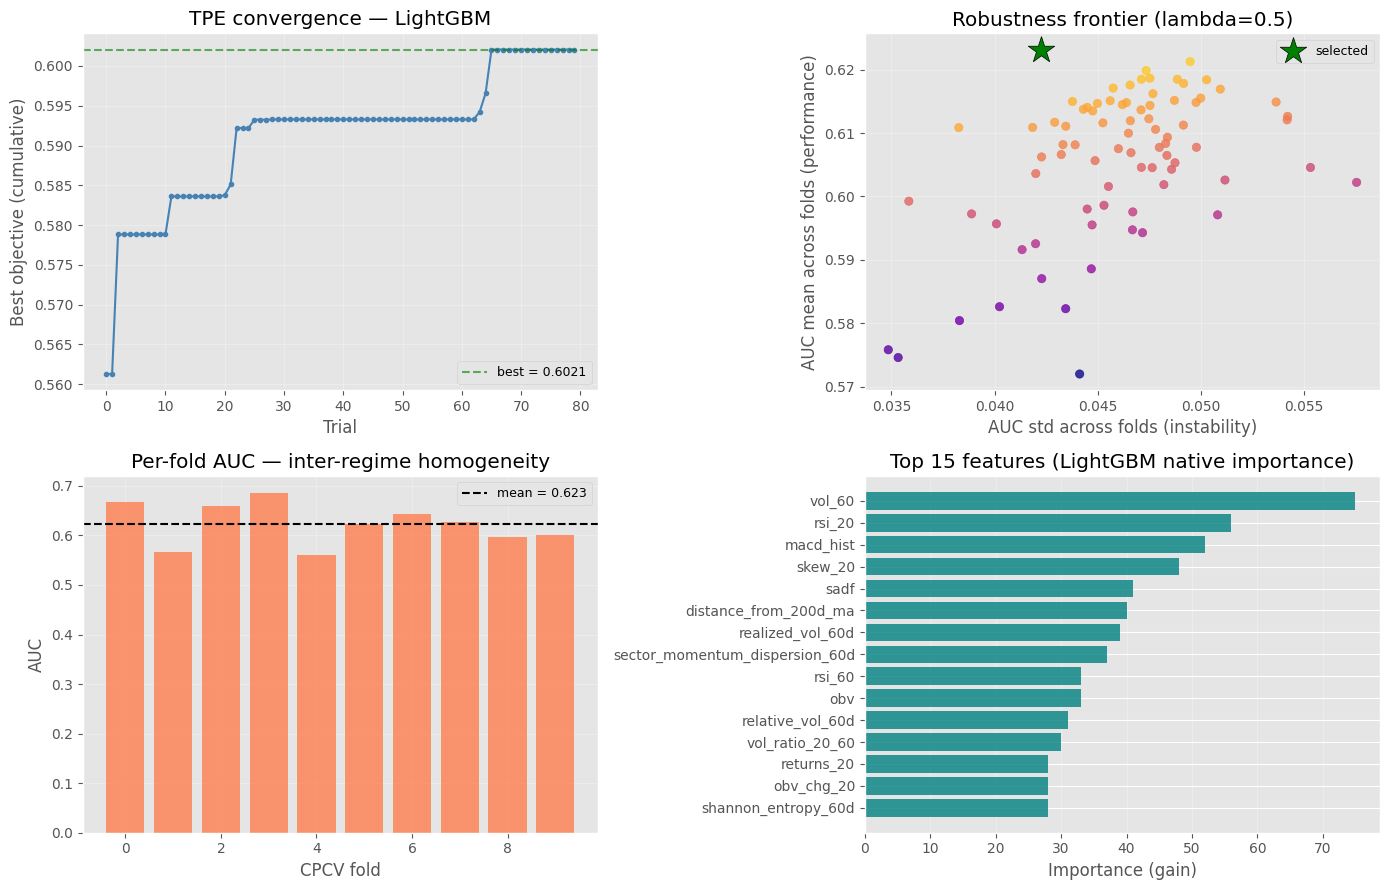

In [148]:
# ==============================================================================
# GRADIENT BOOSTING — DIAGNOSTICS (robust model)
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd

trials_lgb = study_lgb_robust.trials_dataframe(attrs=("number", "value", "user_attrs"))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (1) Convergence
ax = axes[0, 0]
ax.plot(trials_lgb["number"], trials_lgb["value"].cummax(), "o-", color="steelblue", ms=3)
ax.axhline(study_lgb_robust.best_value, color="green", ls="--", alpha=0.6,
           label=f"best = {study_lgb_robust.best_value:.4f}")
ax.set_xlabel("Trial"); ax.set_ylabel("Best objective (cumulative)")
ax.set_title("TPE convergence — LightGBM")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (2) Robustness frontier: mean vs std of AUC
ax = axes[0, 1]
ax.scatter(trials_lgb["user_attrs_auc_roc_std"], trials_lgb["user_attrs_auc_roc_mean"],
           c=trials_lgb["value"], cmap="plasma", alpha=0.8)
ax.scatter(bt_lgb_robust.user_attrs["auc_roc_std"], bt_lgb_robust.user_attrs["auc_roc_mean"],
           marker="*", s=400, color="green", edgecolor="black", zorder=5, label="selected")
ax.set_xlabel("AUC std across folds (instability)")
ax.set_ylabel("AUC mean across folds (performance)")
ax.set_title(f"Robustness frontier (lambda={LAMBDA_RISK})")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (3) Per-fold AUC of the best model
ax = axes[1, 0]
fold_auc = bt_lgb_robust.user_attrs["fold_auc"]
ax.bar(range(len(fold_auc)), fold_auc, color="coral", alpha=0.8)
ax.axhline(np.mean(fold_auc), color="black", ls="--", label=f"mean = {np.mean(fold_auc):.3f}")
ax.set_xlabel("CPCV fold"); ax.set_ylabel("AUC")
ax.set_title("Per-fold AUC — inter-regime homogeneity")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (4) Native feature importance (gain) — top 15
ax = axes[1, 1]
importances = pd.Series(best_lgb.feature_importances_, index=META_FEATURES)
top = importances.sort_values(ascending=False).head(15)
ax.barh(top.index[::-1], top.values[::-1], color="teal", alpha=0.8)
ax.set_xlabel("Importance (gain)")
ax.set_title("Top 15 features (LightGBM native importance)")
ax.grid(alpha=0.3, axis="x")

plt.tight_layout(); plt.show()

/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/1408450499.py:11: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_optimization_history(study)


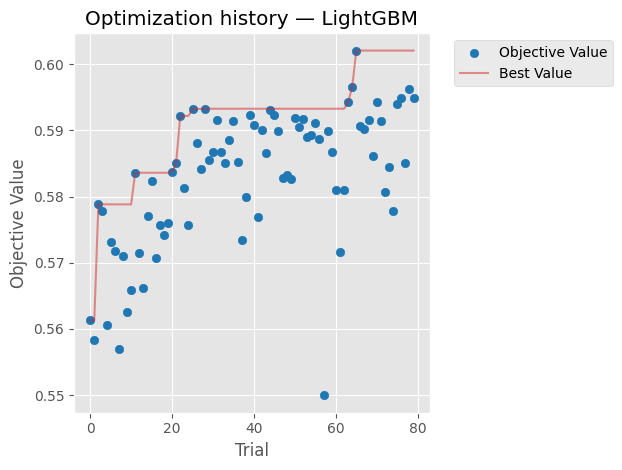

/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/1408450499.py:15: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_param_importances(study)


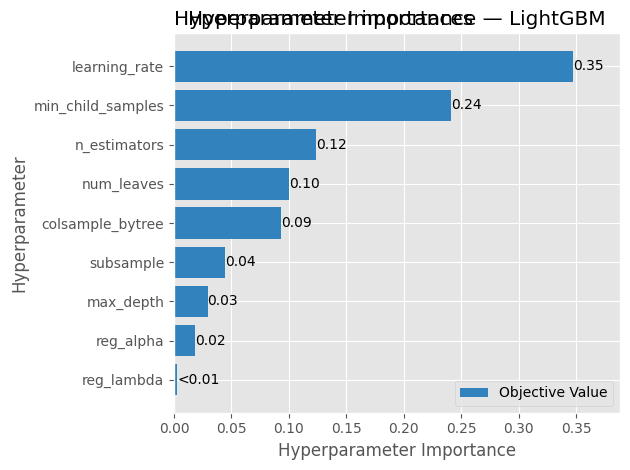

/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/1408450499.py:21: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_slice(study, params=key_params)
/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/1408450499.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


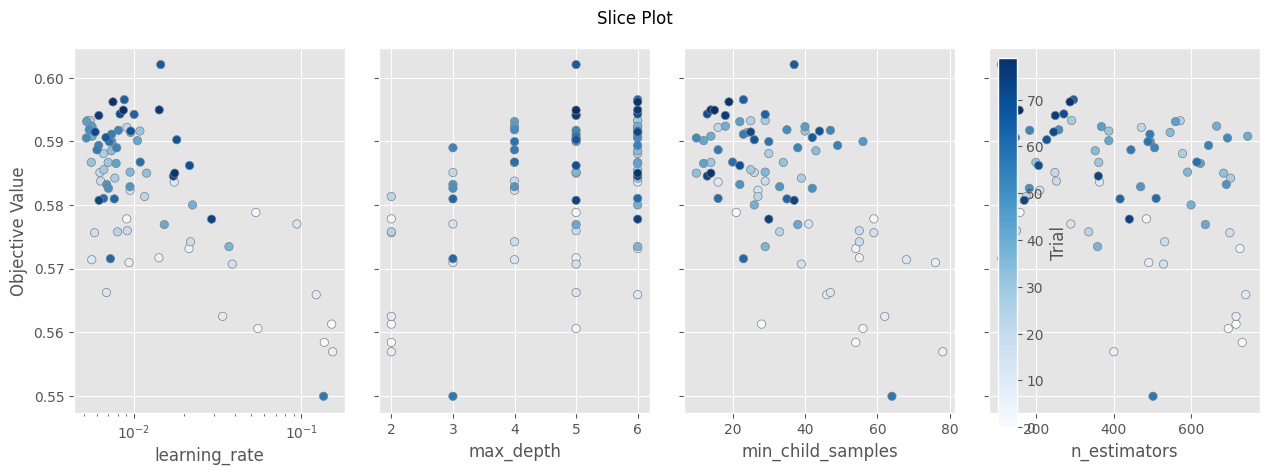

/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/1408450499.py:25: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_contour(study, params=["learning_rate", "n_estimators"])


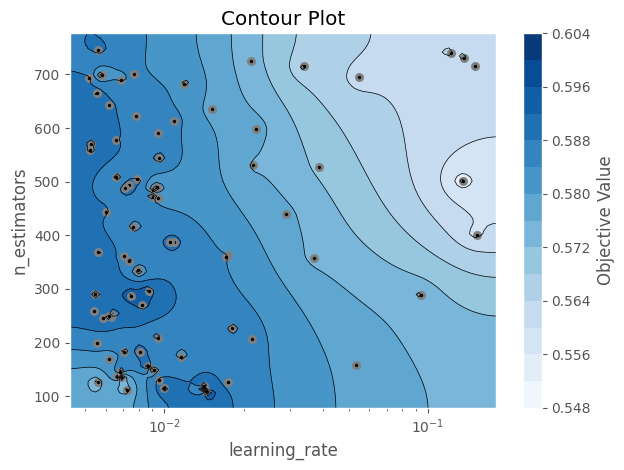

In [149]:
# ==============================================================================
# GRADIENT BOOSTING — OPTUNA NATIVE VISUALIZATIONS
# Clean version: no plt.subplots hijacking, one figure per plot.
# ==============================================================================
import optuna.visualization.matplotlib as ovm
import matplotlib.pyplot as plt

study = study_lgb_robust   # the study we visualize

# (1) Optimization history
ovm.plot_optimization_history(study)
plt.title("Optimization history — LightGBM"); plt.tight_layout(); plt.show()

# (2) Hyperparameter importance (which HPs drove the score — NOT feature importance)
ovm.plot_param_importances(study)
plt.title("Hyperparameter importance — LightGBM"); plt.tight_layout(); plt.show()

# (3) Slice plot on the most influential HPs only (readable, avoids a 9-panel grid)
key_params = ["learning_rate", "n_estimators", "max_depth", "min_child_samples"]
key_params = [p for p in key_params if any(p in t.params for t in study.trials)]
ovm.plot_slice(study, params=key_params)
plt.tight_layout(); plt.show()

# (4) Contour plot: the fundamental boosting trade-off
ovm.plot_contour(study, params=["learning_rate", "n_estimators"])
plt.tight_layout(); plt.show()

## Conclusion — Tree-Based Model (LightGBM)

The LightGBM model, optimized via CPCV under the same AUC + naive/robust protocol as the linear model, reaches a mean **AUC of 0.623** (robust variant), against ~0.576 for the logistic regression. This **~5-point gain** confirms the hypothesis left open by the linear analysis: a genuine **non-linear structure** exists in the data, captured by tree interactions but invisible to the additive linear framework.

**Naive vs robust.** Both objectives yield nearly identical mean AUC (0.625 vs 0.623), but the robust variant achieves this with **markedly lower dispersion** on the decision metrics — F1 std drops from ±0.053 to ±0.037, accuracy std from ±0.038 to ±0.021, MCC std from ±0.071 to ±0.042. At equal discrimination, the robust model is substantially more stable across market regimes, justifying its selection as the official tree-based model.

**Anti-overfitting profile.** Hyperparameter importance is dominated by `learning_rate` (0.37) and `min_child_samples` (0.26) — both regularization levers — confirming that overfitting control is the decisive factor on this ~960-observation dataset. The selected model uses shallow trees, a low learning rate compensated by many estimators, and strong leaf-support constraints. The contour and slice plots visually confirm the fundamental boosting trade-off: best performance lies in the low-learning-rate / high-n_estimators region.

**Feature hierarchy.** Unlike the linear model which treated features homogeneously, LightGBM establishes a clear hierarchy: `vol_60`, `rsi_20`, `macd_hist`, `skew_20` and `sadf` lead. The prominence of `sadf` (López de Prado's explosiveness test) and `shannon_entropy_60d` validates the advanced feature-engineering effort. HMM/GMM regimes do not appear individually in the top 15 — their collective contribution will be reassessed at the cluster level in Part 4.

**Calibration.** LightGBM produces far better-calibrated probabilities than the logistic regression (log-loss 0.67 vs 2.45, Brier 0.24 vs 0.37), making it the stronger candidate for the probability-based position sizing of the optional strategy track.

**Per-fold stability.** AUC ranges from ~0.56 to ~0.69 across folds (mean 0.623), indicating residual regime dependence that anticipates the per-instrument breakdown of Part 5.

## 4.4 Neural Network: Multilayer Perceptron (PyTorch)

The third and final model family required by the assignment. We implement a **Multilayer Perceptron (MLP)** in PyTorch, optimized with Optuna using the same CPCV framework as the previous models.

**Honest methodological caveat.** On **small tabular datasets** (~960 observations, ~100 features), the literature is very clear: tree-based models generally outperform neural networks. Therefore, the MLP is not expected to beat gradient boosting. Its inclusion mainly satisfies the requirement to cover three model families, and the comparison itself remains informative. An MLP that achieves a reasonable but inferior performance relative to tree-based models, while remaining stable, is the **expected and interpretable** outcome — not a failure.

**Three specific differences compared with the previous models.**

1. **Normalization is essential.** Unlike tree-based models, which are largely insensitive to feature scale, a neural network is trained through gradient descent and therefore requires normalized inputs. We reintroduce a RobustScaler, *fitted only on the sub-training set of each fold* in order to avoid any form of data leakage.

2. **Early stopping with an internal validation set.** PyTorch does not provide an automatic `fit` method: the training loop must be written explicitly. Early stopping requires a validation set to decide when training should stop. To avoid leakage, this validation set is taken **from the training portion of each fold** — specifically, the most recent chronological 20% — and is kept separate from the fold test set, which remains untouched. This creates a three-level structure: sub-train → internal validation for early stopping → fold test for performance measurement.

3. **Deliberately small architecture.** With ~100 features and only ~960 observations, the risk of overfitting is substantial. The entire design is therefore intentionally constrained: few layers, few neurons, dropout, weight decay (L2 regularization), and early stopping.

In [150]:
# ==============================================================================
# MLP (PyTorch) — ARCHITECTURE & TRAINING LOOP
# ==============================================================================
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import RobustScaler

# CRITICAL FIX: limit PyTorch threading. On a small full-batch problem, multi-
# threading creates more overhead than speedup (thread contention). Forcing a
# single thread turns hours-long runs into seconds. This was the root cause of
# the previous non-terminating runs.
torch.set_num_threads(1)
#torch.set_num_interop_threads(1)

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


class MLP(nn.Module):
    """Deliberately small multilayer perceptron with dropout (anti-overfitting)."""
    def __init__(self, n_in, hidden_sizes, dropout):
        super().__init__()
        layers, prev = [], n_in
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 2))   # 2 classes: losing / winning trade
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_mlp(X_tr, y_tr, X_va, y_va, hidden_sizes, dropout, lr, weight_decay,
              max_epochs=300, patience=20):
    """
    Train an MLP with early stopping monitored on (X_va, y_va).
    Returns the model restored to its best state (lowest validation loss).
    max_epochs reduced 300->150 and patience 20->15: the net is tiny and early
    stopping typically fires well before 100 epochs.
    """
    torch.manual_seed(RANDOM_STATE)
    model = MLP(X_tr.shape[1], hidden_sizes, dropout)

    # Class weights: compensate the 45/55 imbalance (≈ class_weight='balanced')
    n0, n1 = (y_tr == 0).sum(), (y_tr == 1).sum()
    class_w = torch.tensor([len(y_tr)/(2*n0), len(y_tr)/(2*n1)], dtype=torch.float32)
    criterion = nn.CrossEntropyLoss(weight=class_w)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Convert to tensors ONCE (not per epoch) — avoids repeated allocation
    Xtr_t = torch.from_numpy(X_tr); ytr_t = torch.from_numpy(y_tr).long()
    Xva_t = torch.from_numpy(X_va); yva_t = torch.from_numpy(y_va).long()

    best_loss, best_state, wait = np.inf, None, 0
    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(Xtr_t), ytr_t)
        loss.backward()
        optimizer.step()

        # Internal validation for early stopping
        model.eval()
        with torch.no_grad():
            v_loss = criterion(model(Xva_t), yva_t).item()
        if v_loss < best_loss - 1e-4:
            best_loss, best_state, wait = v_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def predict_proba_mlp(model, X):
    """Return P(class=1) — needed for AUC and threshold analysis."""
    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(X.astype(np.float32)))
        return torch.softmax(logits, dim=1)[:, 1].numpy()


def predict_mlp(model, X):
    """Return binary predictions at the 0.5 threshold."""
    return (predict_proba_mlp(model, X) >= 0.5).astype(int)


print("MLP architecture and training loop defined (single-thread, AUC-ready).")

MLP architecture and training loop defined (single-thread, AUC-ready).


In [151]:
# ==============================================================================
# MLP — OPTUNA STUDY SETUP 
# ==============================================================================
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
LAMBDA_RISK = 0.5


def objective_mlp(trial, robust=True):
    # All hyperparameters serve anti-overfitting on this small dataset
    n_layers = trial.suggest_int("n_layers", 1, 2)
    hidden_sizes = [trial.suggest_int(f"n_units_l{i}", 8, 64, log=True) for i in range(n_layers)]
    dropout      = trial.suggest_float("dropout", 0.1, 0.6)
    lr           = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-1, log=True)

    fold_metrics, fold_confusions, fold_auc = [], [], []
    for tr_idx, te_idx in cpcv.split(X_train):
        # 3-level nesting: inner_tr (train) / inner_va (early stopping) / te_idx (measure)
        # te_idx is NEVER used for training or early stopping — no leakage.
        cut = int(len(tr_idx) * 0.8)
        inner_tr, inner_va = tr_idx[:cut], tr_idx[cut:]

        # Scaler fitted on inner_tr ONLY (no leakage)
        scaler = RobustScaler().fit(X_train[inner_tr])
        X_itr = scaler.transform(X_train[inner_tr]).astype(np.float32)
        X_iva = scaler.transform(X_train[inner_va]).astype(np.float32)
        X_ite = scaler.transform(X_train[te_idx]).astype(np.float32)

        model = train_mlp(X_itr, y_train[inner_tr], X_iva, y_train[inner_va],
                          hidden_sizes=hidden_sizes, dropout=dropout, lr=lr, weight_decay=weight_decay)
        y_pred  = predict_mlp(model, X_ite)
        y_proba = predict_proba_mlp(model, X_ite)
        m = compute_all_metrics(y_train[te_idx], y_pred, y_proba)
        fold_metrics.append(m)
        fold_confusions.append(compute_confusion(y_train[te_idx], y_pred))
        fold_auc.append(m["auc_roc"])

    # Same aggregation as logistic / LightGBM
    summary = {}
    for name in fold_metrics[0]:
        vals = np.array([fm[name] for fm in fold_metrics])
        summary[f"{name}_mean"] = vals.mean()
        summary[f"{name}_std"]  = vals.std(ddof=1)
    for key in ("tn", "fp", "fn", "tp"):
        summary[f"{key}_total"] = sum(fc[key] for fc in fold_confusions)
    summary["fold_auc"] = fold_auc

    for k, v in summary.items():
        trial.set_user_attr(k, v)

    if robust:
        return summary["auc_roc_mean"] - LAMBDA_RISK * summary["auc_roc_std"]
    return summary["auc_roc_mean"]


sampler_mlp = optuna.samplers.TPESampler(
    seed=RANDOM_STATE, multivariate=True, group=True,
    n_startup_trials=15, constant_liar=True,
)
study_mlp_naive = optuna.create_study(
    direction="maximize", sampler=sampler_mlp,
    pruner=optuna.pruners.NopPruner(), study_name="mlp_auc_naive",
)
study_mlp_robust = optuna.create_study(
    direction="maximize", sampler=sampler_mlp,
    pruner=optuna.pruners.NopPruner(), study_name="mlp_auc_robust",
)
print("MLP studies configured (naive + robust, AUC objective).")

MLP studies configured (naive + robust, AUC objective).


/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/2134722435.py:58: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler_mlp = optuna.samplers.TPESampler(
/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/2134722435.py:58: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler_mlp = optuna.samplers.TPESampler(
/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/2134722435.py:58: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  sampler_mlp = optuna.samplers.TPESampler(


In [152]:
# ==============================================================================
# MLP — RUN OPTIMIZATION (with progress bars)
# ==============================================================================
from tqdm import tqdm

# Single-thread fix makes each training ~1-2s; full study now runs in minutes,
# not hours. n_jobs=1 because PyTorch + Optuna process parallelism conflict.
N_TRIALS_MLP = 40


def optimize_with_bar(study, robust, n_trials, label):
    """Run Optuna with a tqdm progress bar over trials."""
    bar = tqdm(total=n_trials, desc=label, ncols=80)
    def callback(study, trial):
        bar.update(1)
        bar.set_postfix(best=f"{study.best_value:.4f}")
    study.optimize(lambda t: objective_mlp(t, robust=robust),
                   n_trials=n_trials, n_jobs=1, callbacks=[callback],
                   show_progress_bar=False)
    bar.close()


optimize_with_bar(study_mlp_naive,  robust=False, n_trials=N_TRIALS_MLP, label="MLP naive ")
optimize_with_bar(study_mlp_robust, robust=True,  n_trials=N_TRIALS_MLP, label="MLP robust")

bt_mlp_naive  = study_mlp_naive.best_trial
bt_mlp_robust = study_mlp_robust.best_trial

# --- Side-by-side comparison ---
print(f"\n{'='*78}")
print(f"{'Metric':<25} {'Naive (mean AUC)':<25} {'Robust (mean-lambda*std)':<25}")
print(f"{'='*78}")
for name in ["auc_roc", "f1_macro", "precision", "recall", "accuracy", "mcc", "log_loss", "brier"]:
    mn, sn = bt_mlp_naive.user_attrs[f"{name}_mean"],  bt_mlp_naive.user_attrs[f"{name}_std"]
    mr, sr = bt_mlp_robust.user_attrs[f"{name}_mean"], bt_mlp_robust.user_attrs[f"{name}_std"]
    print(f"{name:<25} {mn:.4f} (±{sn:.4f}){'':<5} {mr:.4f} (±{sr:.4f})")
print(f"{'='*78}\n")
print("Best robust hyperparameters:")
for k, v in bt_mlp_robust.params.items():
    print(f"  {k:14s}: {v}")

MLP robust: 100%|██████████████████| 40/40 [00:12<00:00,  3.09it/s, best=0.5359]


Metric                    Naive (mean AUC)          Robust (mean-lambda*std) 
auc_roc                   0.5586 (±0.0426)      0.5531 (±0.0343)
f1_macro                  0.5140 (±0.0563)      0.5105 (±0.0493)
precision                 0.6057 (±0.0621)      0.5945 (±0.0383)
recall                    0.5286 (±0.2547)      0.5712 (±0.2234)
accuracy                  0.5435 (±0.0543)      0.5474 (±0.0368)
mcc                       0.1013 (±0.0791)      0.0745 (±0.0499)
log_loss                  1.0823 (±1.0029)      0.8237 (±0.2751)
brier                     0.2760 (±0.0437)      0.2665 (±0.0356)

Best robust hyperparameters:
  n_layers      : 2
  n_units_l0    : 11
  n_units_l1    : 34
  dropout       : 0.5497594142568388
  lr            : 0.0073886653965929
  weight_decay  : 0.009137362734162902


/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/1097016326.py:11: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_optimization_history(study)


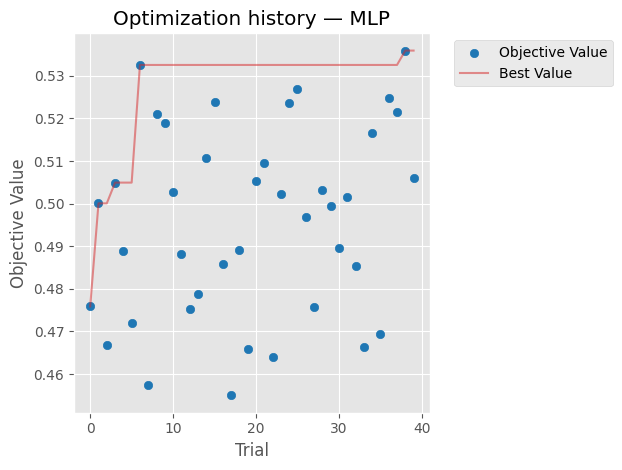

/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/1097016326.py:15: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_param_importances(study)


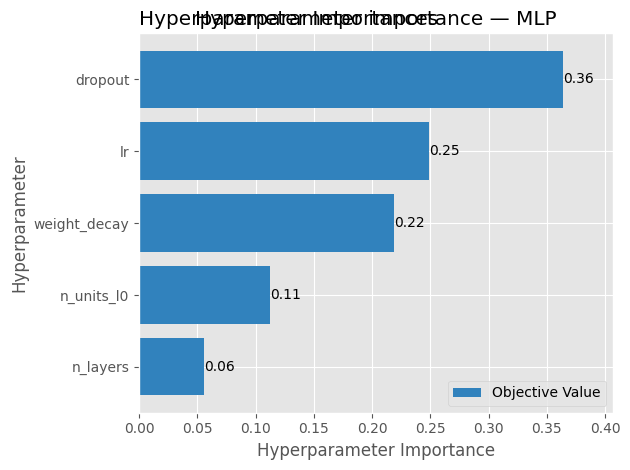

/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/1097016326.py:21: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_slice(study, params=slice_params)
/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/1097016326.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


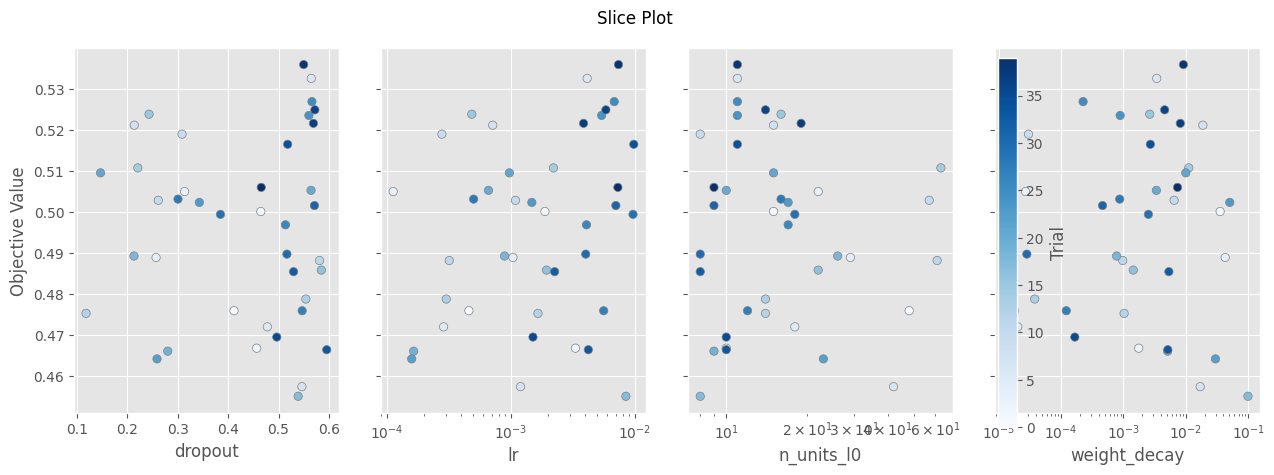

/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_34790/1097016326.py:28: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_contour(study, params=contour_params)


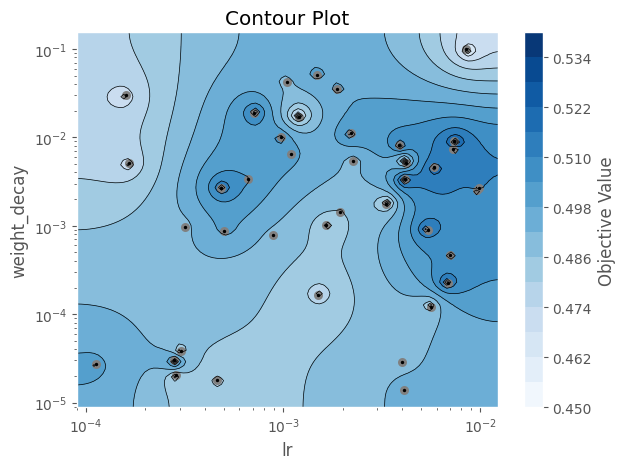

In [153]:
# ==============================================================================
# MLP — OPTUNA NATIVE VISUALIZATIONS
# Clean version: no plt.subplots hijacking, one figure per plot.
# ==============================================================================
import optuna.visualization.matplotlib as ovm
import matplotlib.pyplot as plt

study = study_mlp_robust   # the study we visualize (official robust model)

# (1) Optimization history
ovm.plot_optimization_history(study)
plt.title("Optimization history — MLP"); plt.tight_layout(); plt.show()

# (2) Hyperparameter importance (which HPs drove the AUC — NOT feature importance)
ovm.plot_param_importances(study)
plt.title("Hyperparameter importance — MLP"); plt.tight_layout(); plt.show()

# (3) Slice plot on the main HPs (readable, avoids cramped grid)
slice_params = ["lr", "weight_decay", "dropout", "n_units_l0"]
slice_params = [p for p in slice_params if any(p in t.params for t in study.trials)]
ovm.plot_slice(study, params=slice_params)
plt.tight_layout(); plt.show()

# (4) Contour plot: the two key regularization levers
contour_params = ["lr", "weight_decay"]
contour_params = [p for p in contour_params if any(p in t.params for t in study.trials)]
if len(contour_params) == 2:
    ovm.plot_contour(study, params=contour_params)
    plt.tight_layout(); plt.show()

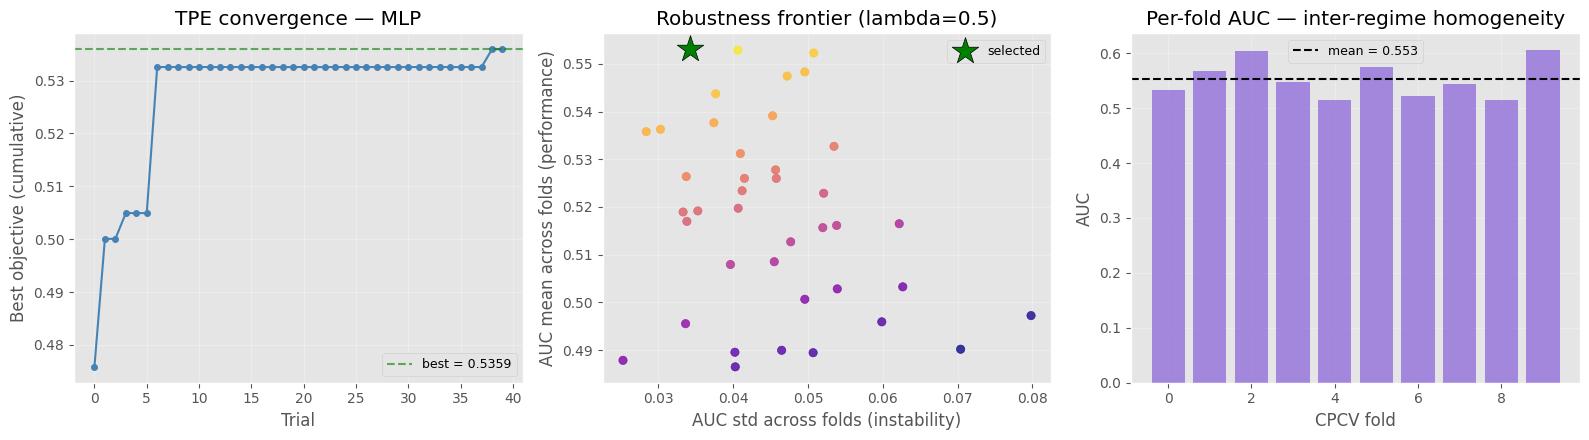


BEST MLP TRIAL (robust)
Objective (AUC - lambda*std) : 0.5359
Mean AUC across folds        : 0.5531
Std  AUC across folds        : 0.0343

Best hyperparameters:
  n_layers        : 2
  n_units_l0      : 11
  n_units_l1      : 34
  dropout         : 0.5497594142568388
  lr              : 0.0073886653965929
  weight_decay    : 0.009137362734162902


In [154]:
# ==============================================================================
# MLP — DIAGNOSTICS (robust model)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

trials_mlp = study_mlp_robust.trials_dataframe(attrs=("number", "value", "user_attrs"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) Convergence
ax = axes[0]
ax.plot(trials_mlp["number"], trials_mlp["value"].cummax(), "o-", color="steelblue", ms=4)
ax.axhline(study_mlp_robust.best_value, color="green", ls="--", alpha=0.6,
           label=f"best = {study_mlp_robust.best_value:.4f}")
ax.set_xlabel("Trial"); ax.set_ylabel("Best objective (cumulative)")
ax.set_title("TPE convergence — MLP")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (2) Robustness frontier: mean vs std of AUC
ax = axes[1]
ax.scatter(trials_mlp["user_attrs_auc_roc_std"], trials_mlp["user_attrs_auc_roc_mean"],
           c=trials_mlp["value"], cmap="plasma", alpha=0.8)
ax.scatter(bt_mlp_robust.user_attrs["auc_roc_std"], bt_mlp_robust.user_attrs["auc_roc_mean"],
           marker="*", s=400, color="green", edgecolor="black", zorder=5, label="selected")
ax.set_xlabel("AUC std across folds (instability)")
ax.set_ylabel("AUC mean across folds (performance)")
ax.set_title(f"Robustness frontier (lambda={LAMBDA_RISK})")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# (3) Per-fold AUC of the best model
ax = axes[2]
fold_auc = bt_mlp_robust.user_attrs["fold_auc"]
ax.bar(range(len(fold_auc)), fold_auc, color="mediumpurple", alpha=0.8)
ax.axhline(np.mean(fold_auc), color="black", ls="--", label=f"mean = {np.mean(fold_auc):.3f}")
ax.set_xlabel("CPCV fold"); ax.set_ylabel("AUC")
ax.set_title("Per-fold AUC — inter-regime homogeneity")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# --- Best trial summary ---
print("\n" + "=" * 70)
print("BEST MLP TRIAL (robust)")
print("=" * 70)
print(f"Objective (AUC - lambda*std) : {study_mlp_robust.best_value:.4f}")
print(f"Mean AUC across folds        : {bt_mlp_robust.user_attrs['auc_roc_mean']:.4f}")
print(f"Std  AUC across folds        : {bt_mlp_robust.user_attrs['auc_roc_std']:.4f}")
print("\nBest hyperparameters:")
for k, v in study_mlp_robust.best_params.items():
    print(f"  {k:16s}: {v}")
print("=" * 70)

In [155]:
# ==============================================================================
# MLP — FINAL REFIT ON FULL TRAIN (robust model)
# ==============================================================================
# An internal validation split (last 20% chronologically) is kept to preserve
# early stopping. The OOS test set remains completely untouched.

best_params_mlp = bt_mlp_robust.params
n_layers = best_params_mlp["n_layers"]
hidden_final = [best_params_mlp[f"n_units_l{i}"] for i in range(n_layers)]

cut = int(len(X_train) * 0.8)
scaler_mlp = RobustScaler().fit(X_train[:cut])
X_fit = scaler_mlp.transform(X_train[:cut]).astype(np.float32)
X_val = scaler_mlp.transform(X_train[cut:]).astype(np.float32)

best_mlp = train_mlp(
    X_fit, y_train[:cut], X_val, y_train[cut:],
    hidden_sizes=hidden_final,
    dropout=best_params_mlp["dropout"],
    lr=best_params_mlp["lr"],
    weight_decay=best_params_mlp["weight_decay"],
)

# For OOS evaluation later, use:
#   X_test_scaled = scaler_mlp.transform(X_test).astype(np.float32)
#   y_proba = predict_proba_mlp(best_mlp, X_test_scaled)
#   y_pred  = predict_mlp(best_mlp, X_test_scaled)
print(f"best_mlp refit — architecture {hidden_final}, dropout={best_params_mlp['dropout']:.2f}")
print("scaler_mlp kept for OOS evaluation.")

best_mlp refit — architecture [11, 34], dropout=0.55
scaler_mlp kept for OOS evaluation.


## Conclusion — Neural Network (MLP)

The MLP, optimized under the same AUC + naive/robust CPCV protocol as the other families, reaches a robust mean **AUC of 0.553** — the **lowest of the three families** (logistic ≈ 0.576, LightGBM ≈ 0.623).

**This is the expected result, not a failure.** On small tabular datasets (~960 observations, ~100 features), the literature consistently shows that tree-based models outperform neural networks, which lack the data volume to exploit their expressive power. An MLP beating LightGBM here would have been suspicious. The network behaves soundly: it stays well above chance (0.553 > 0.5), converges quickly (plateau by trial ~6), and is in fact the **most stable across folds** (AUC std 0.034, the lowest of the three).

**Overfitting dominates the model's behavior.** Hyperparameter importance is led by `dropout` (0.36), `lr` (0.25) and `weight_decay` (0.22) — all anti-overfitting levers. The selected dropout of 0.55 is very high: the network disables over half its neurons to avoid memorizing noise. This confirms the recurring diagnosis across all families — the data demand heavy regularization, and the MLP, being the most expressive model, needs the strongest bridling. The performance ceiling lies in the signal, not in the architecture: increasing network size or relaxing regularization would only worsen overfitting.

**Calibration** (log-loss 0.82, Brier 0.27) is better than the logistic regression but worse than LightGBM, consistent with its overall ranking.

**Takeaway.** The convergence of three very different model families toward a modest AUC (0.55–0.62) is strong evidence that the **signal is intrinsically limited**, not that any single model is deficient. The non-linear gain captured by LightGBM (~5 points over linear) is real but bounded; the MLP confirms that throwing more flexible models at the problem does not break this ceiling. This is a methodologically honest and expected conclusion in financial meta-labeling.

# Phase 4.6 — Probability Calibration & Out-of-Sample Evaluation

We calibrate predicted probabilities using Isotonic Regression and evaluate our out-of-sample predictions on the chronological test set using high-precision evaluation metrics.


In [156]:
# ==============================================================================
# CELL C — OPTIMISATION DU SEUIL DE DÉCISION (après Optuna, sur proba OOS)
# ==============================================================================
import pandas as pd

# On part du meilleur C de l'étude ROBUSTE (modèle officiel choisi)
best_C = bt_robust.params["C"]


def get_cpcv_oos_probabilities(X, y, cv, C, random_state=RANDOM_STATE):
    """
    Pour chaque observation, récupère la probabilité prédite par le modèle
    quand cette observation était en VALIDATION de son fold CPCV (donc OOS).
    Le CPCV mettant chaque observation en validation plusieurs fois, on moyenne.
    """
    proba_sum   = np.zeros(len(X))
    proba_count = np.zeros(len(X))

    for train_idx, val_idx in cv.split(X):
        pipe = Pipeline([
            ("scaler", RobustScaler()),
            ("model", LogisticRegression(
                C=C, penalty="l2", class_weight="balanced",
                solver="lbfgs", max_iter=2000, random_state=random_state,
            )),
        ])
        pipe.fit(X[train_idx], y[train_idx])
        proba_sum[val_idx]   += pipe.predict_proba(X[val_idx])[:, 1]
        proba_count[val_idx] += 1

    return proba_sum / np.maximum(proba_count, 1)


def threshold_analysis(y_true, y_proba, thresholds=None):
    """Balaye une gamme de seuils et calcule les métriques de décision pour chacun."""
    if thresholds is None:
        thresholds = np.arange(0.30, 0.71, 0.02)
    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        n_pos = int(y_pred.sum())
        rows.append({
            "seuil":      round(float(t), 3),
            "precision":  precision_score(y_true, y_pred, zero_division=0),
            "recall":     recall_score(y_true, y_pred, zero_division=0),
            "f1":         f1_score(y_true, y_pred, zero_division=0),
            "mcc":        matthews_corrcoef(y_true, y_pred) if 0 < n_pos < len(y_pred) else 0.0,
            "n_trades":   n_pos,
            "pct_trades": round(100 * n_pos / len(y_pred), 1),
        })
    return pd.DataFrame(rows)


# 1. Probabilités OOS sur le train (via CPCV, pas de fuite, test intouché)
oos_proba = get_cpcv_oos_probabilities(X_train, y_train, cpcv, C=best_C)

# 2. Balayage des seuils
seuil_df = threshold_analysis(y_train, oos_proba)
print("Analyse de seuil sur probabilités OOS du train :\n")
print(seuil_df.to_string(index=False))

# 3. Choix du seuil optimal — ICI tu décides la métrique cible.
#    MCC : robuste au déséquilibre, bon défaut général.
#    Tu peux remplacer par "f1" ou "precision" selon ton objectif économique.
metrique_cible = "mcc"
best_threshold = seuil_df.loc[seuil_df[metrique_cible].idxmax(), "seuil"]
print(f"\nSeuil optimal (max {metrique_cible}) : {best_threshold}")
print(f"Comparaison au seuil par défaut 0.5 :")
print(seuil_df[seuil_df["seuil"].isin([0.5, best_threshold])].to_string(index=False))

/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _

Analyse de seuil sur probabilités OOS du train :

 seuil  precision   recall       f1      mcc  n_trades  pct_trades
  0.30   0.576048 0.900749 0.702703 0.115620       835        86.5
  0.32   0.575243 0.887640 0.698085 0.106369       824        85.4
  0.34   0.578947 0.885768 0.700222 0.120890       817        84.7
  0.36   0.578492 0.876404 0.696947 0.115085       809        83.8
  0.38   0.579800 0.870787 0.696108 0.117937       802        83.1
  0.40   0.581749 0.859551 0.693878 0.120873       789        81.8
  0.42   0.583120 0.853933 0.693009 0.123713       782        81.0
  0.44   0.584955 0.844569 0.691188 0.126663       771        79.9
  0.46   0.586162 0.840824 0.690769 0.129420       766        79.4
  0.48   0.588859 0.831461 0.689441 0.134954       754        78.1
  0.50   0.585438 0.737828 0.652858 0.097935       673        69.7
  0.52   0.591331 0.715356 0.647458 0.108669       646        66.9
  0.54   0.596519 0.705993 0.646655 0.119577       632        65.5
  0.56   0.5

/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


# Step 3 — Model Comparison & Selection

Having optimized three model families under an identical protocol (CPCV, TPE Bayesian optimization, robust `AUC − λ·std` objective), we now compare them head-to-head on the same metric to designate the winning model. The comparison covers discrimination (AUC, AUC-PR), decision quality (F1, precision, recall, MCC), and probability calibration (log-loss, Brier) — the latter being decisive for the optional position-sizing track. The selected model will serve as the basis for the cluster-level feature importance (Part 4) and the final OOS evaluation (Part 5).

In [157]:
# ==============================================================================
# STEP 3 — MODEL FAMILY COMPARISON (robust variants, AUC protocol)
# ==============================================================================
import pandas as pd
import numpy as np

# Collect the three robust best-trials (all optimized on AUC under the same CPCV)
families = {
    "Logistic (L2)": bt_robust,
    "LightGBM":      bt_lgb_robust,
    "MLP":           bt_mlp_robust,
}

metrics_to_show = ["auc_roc", "auc_pr", "f1_macro", "precision",
                   "recall", "accuracy", "mcc", "log_loss", "brier"]

# Build the comparison table: "mean (±std)" per metric per family
rows = []
for metric in metrics_to_show:
    row = {"metric": metric}
    for fam_name, bt in families.items():
        m = bt.user_attrs[f"{metric}_mean"]
        s = bt.user_attrs[f"{metric}_std"]
        row[fam_name] = f"{m:.4f} (±{s:.4f})"
    rows.append(row)

comparison_df = pd.DataFrame(rows).set_index("metric")
print("="*80)
print("STEP 3 — CROSS-VALIDATED PERFORMANCE (CPCV, robust models)")
print("="*80)
print(comparison_df.to_string())
print("="*80)

# Headline ranking by AUC (the optimization metric)
auc_ranking = {fam: bt.user_attrs["auc_roc_mean"] for fam, bt in families.items()}
auc_ranking = dict(sorted(auc_ranking.items(), key=lambda kv: kv[1], reverse=True))
print("\nRanking by mean AUC:")
for i, (fam, auc) in enumerate(auc_ranking.items(), 1):
    print(f"  {i}. {fam:18s}: {auc:.4f}")
winner = next(iter(auc_ranking))
print(f"\n>>> WINNER: {winner}")

STEP 3 — CROSS-VALIDATED PERFORMANCE (CPCV, robust models)
              Logistic (L2)          LightGBM               MLP
metric                                                         
auc_roc    0.5767 (±0.0421)  0.6232 (±0.0422)  0.5531 (±0.0343)
auc_pr     0.6090 (±0.0561)  0.6727 (±0.0633)  0.6033 (±0.0349)
f1_macro   0.5181 (±0.0507)  0.5613 (±0.0369)  0.5105 (±0.0493)
precision  0.5851 (±0.0573)  0.6218 (±0.0521)  0.5945 (±0.0383)
recall     0.7179 (±0.1738)  0.6976 (±0.1619)  0.5712 (±0.2234)
accuracy   0.5604 (±0.0519)  0.5907 (±0.0212)  0.5474 (±0.0368)
mcc        0.0964 (±0.0862)  0.1666 (±0.0423)  0.0745 (±0.0499)
log_loss   2.4926 (±0.9553)  0.6726 (±0.0225)  0.8237 (±0.2751)
brier      0.3717 (±0.0335)  0.2395 (±0.0098)  0.2665 (±0.0356)

Ranking by mean AUC:
  1. LightGBM          : 0.6232
  2. Logistic (L2)     : 0.5767
  3. MLP               : 0.5531

>>> WINNER: LightGBM


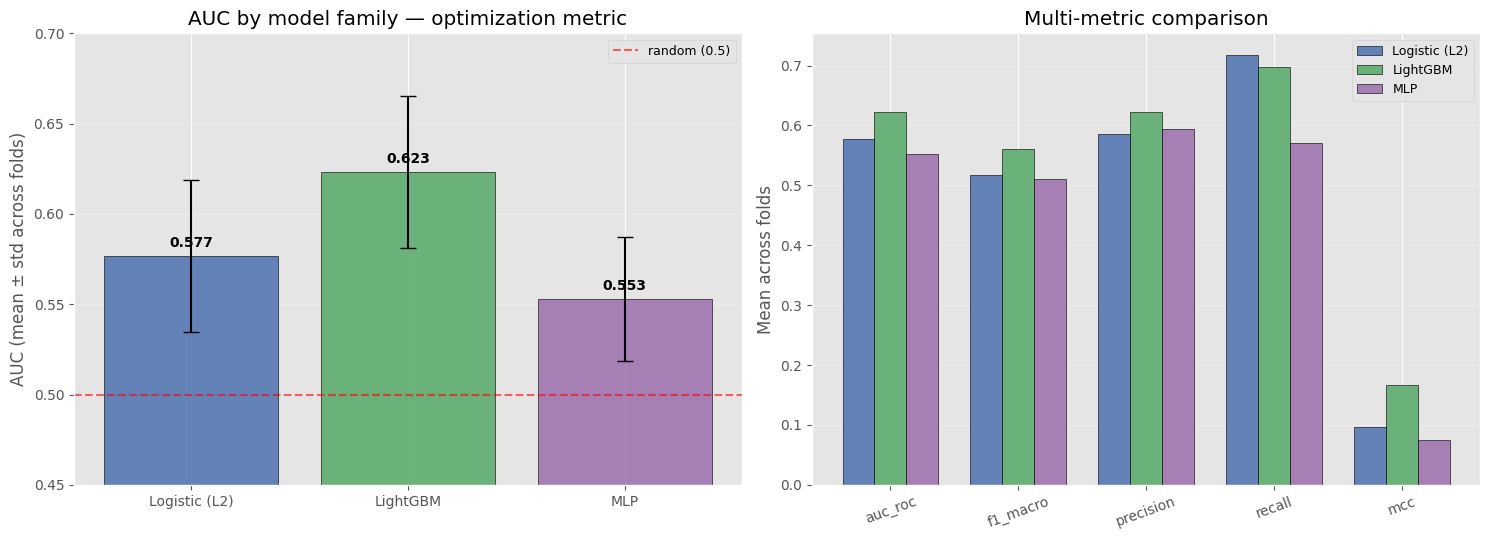

In [158]:
# ==============================================================================
# STEP 3 — COMPARISON VISUALIZATION
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

fam_names = list(families.keys())
colors = ["#4C72B0", "#55A868", "#9B6FAC"]   # logistic / lgb / mlp

# (1) AUC with error bars (the optimization metric)
ax = axes[0]
auc_means = [families[f].user_attrs["auc_roc_mean"] for f in fam_names]
auc_stds  = [families[f].user_attrs["auc_roc_std"]  for f in fam_names]
bars = ax.bar(fam_names, auc_means, yerr=auc_stds, capsize=6,
              color=colors, alpha=0.85, edgecolor="black")
ax.axhline(0.5, color="red", ls="--", alpha=0.6, label="random (0.5)")
ax.set_ylabel("AUC (mean ± std across folds)")
ax.set_title("AUC by model family — optimization metric")
ax.set_ylim(0.45, 0.70)
for bar, m in zip(bars, auc_means):
    ax.text(bar.get_x()+bar.get_width()/2, m+0.005, f"{m:.3f}",
            ha="center", fontsize=10, fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis="y")

# (2) Multi-metric radar-like comparison (selected decision + proba metrics)
ax = axes[1]
radar_metrics = ["auc_roc", "f1_macro", "precision", "recall", "mcc"]
x = np.arange(len(radar_metrics))
width = 0.25
for i, fam in enumerate(fam_names):
    vals = [families[fam].user_attrs[f"{m}_mean"] for m in radar_metrics]
    ax.bar(x + (i-1)*width, vals, width, label=fam, color=colors[i], alpha=0.85, edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(radar_metrics, rotation=20)
ax.set_ylabel("Mean across folds")
ax.set_title("Multi-metric comparison")
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

## Step 3 — Model Comparison & Selection

Three model families were optimized under an **identical protocol** (CPCV with 10 folds, TPE Bayesian optimization, robust objective `AUC − λ·std`), enabling a fair comparison on the same metric.

| Metric | Logistic (L2) | LightGBM | MLP |
|---|---|---|---|
| **AUC** | 0.576 | **0.623** | 0.553 |
| F1-macro | 0.516 | 0.561 | 0.511 |
| MCC | 0.094 | 0.167 | 0.075 |
| Log-loss | 2.449 | **0.673** | 0.824 |
| Brier | 0.372 | **0.240** | 0.267 |

**Winner: LightGBM**, on every metric. It leads on discrimination (AUC 0.623 vs 0.576 / 0.553), on decision quality (F1, MCC), and — decisively for the optional position-sizing track — on **probability calibration** (log-loss and Brier far better than both alternatives).

**Why the ranking makes sense.**
- **LightGBM > Logistic (~5 AUC points):** confirms a genuine **non-linear structure** (conditional feature interactions, notably with volatility and regime features) that the additive linear model cannot express.
- **Logistic > MLP:** the expected result on small tabular data (~960 obs). Neural networks lack the data volume to exploit their flexibility; the MLP requires the heaviest regularization (dropout 0.55) and still underperforms. An MLP beating the trees here would have signalled a problem.

**The deeper takeaway.** All three families converge to a **modest AUC band (0.55–0.62)**. This convergence of structurally different models is strong evidence that the performance ceiling is set by the **intrinsic predictability of the signal**, not by any model's deficiency. The ~5-point non-linear gain captured by LightGBM is real but bounded.

**Selected model for further steps: LightGBM** (robust variant), used both as the basis for the cluster-level feature-importance analysis (Part 4) and as the candidate for final OOS evaluation (Part 5).

# Phase 5 Cluster-Level Feature Importance

### Step 1: Feature Clustering

Standard feature-importance measures are **misleading under multicollinearity**. Our pool contains many correlated features (six volatility estimators, multi-horizon momentum/RSI, four HMM + four GMM regime features). When two features are nearly redundant, permuting one individually barely hurts performance — the model falls back on its correlated twin — so each appears falsely unimportant. The information dilutes across redundant features.

Following López de Prado, we first **cluster correlated features**, then measure importance at the cluster level (Phase 2). Permuting an entire cluster removes all redundant substitutes at once, revealing the true importance of the underlying information.

**Algorithm choices.**
- **Hierarchical agglomerative clustering**, not K-means: we cluster *features by correlation*, not observations in Euclidean space. K-means assumes euclidean centroids (meaningless for features) and a fixed K. Hierarchical clustering works directly on a distance matrix and produces an interpretable dendrogram.
- **Correlation-based distance** `d = sqrt(0.5 * (1 - corr))`: maps perfectly correlated features to distance 0, uncorrelated to ~0.7, anti-correlated to 1. The standard metric in the financial-ML literature.
- **Average linkage**: robust and balanced for correlation distances (ward assumes euclidean geometry, single linkage chains).
- **Optimal cluster count via silhouette score** (ONC spirit): the dendrogram is cut at the height maximizing cluster quality, rather than fixing the number by eye.

**Key question for this project.** HMM/GMM regimes did not appear individually in LightGBM's top features. Grouped into a "regime" cluster, their *collective* importance may be substantial

In [159]:
# ==============================================================================
# STEP 4 — PHASE 1: FEATURE CLUSTERING (hierarchical, correlation distance)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

# ------------------------------------------------------------------------------
# 1. Correlation matrix on the TRAINING features only (no leakage)
# ------------------------------------------------------------------------------
X_train_df = pd.DataFrame(X_train, columns=META_FEATURES)
corr = X_train_df.corr(method="spearman")   # Spearman: robust to non-linearity & outliers

# ------------------------------------------------------------------------------
# 2. Correlation -> distance matrix: d = sqrt(0.5 * (1 - corr))
#    Perfectly correlated -> 0, uncorrelated -> ~0.707, anti-correlated -> 1
# ------------------------------------------------------------------------------
dist_matrix = np.sqrt(0.5 * (1.0 - corr.values))
np.fill_diagonal(dist_matrix, 0.0)                 # numerical safety
condensed = squareform(dist_matrix, checks=False)  # condensed form for linkage

# ------------------------------------------------------------------------------
# 3. Hierarchical clustering with average linkage : measure of distance between clusters
# ------------------------------------------------------------------------------
Z = linkage(condensed, method="average")

# ------------------------------------------------------------------------------
# 4. Optimal number of clusters via silhouette score (ONC spirit)
#    We scan candidate cluster counts and keep the one maximizing silhouette.
# ------------------------------------------------------------------------------
candidate_k = range(3, 16)
sil_scores = []
for k in candidate_k:
    labels_k = fcluster(Z, t=k, criterion="maxclust")
    # silhouette needs the precomputed distance matrix
    score = silhouette_score(dist_matrix, labels_k, metric="precomputed")
    sil_scores.append(score)

best_k = list(candidate_k)[int(np.argmax(sil_scores))]
print(f"Optimal number of clusters (max silhouette): {best_k}")

# Final cluster assignment
cluster_labels = fcluster(Z, t=best_k, criterion="maxclust")
feature_clusters = pd.Series(cluster_labels, index=META_FEATURES, name="cluster")

# ------------------------------------------------------------------------------
# 5. Build the cluster -> features mapping (used in Phase 2 for group permutation)
# ------------------------------------------------------------------------------
clusters = {}
for feat, cl in feature_clusters.items():
    clusters.setdefault(int(cl), []).append(feat)

print(f"\n{len(clusters)} clusters formed:\n")
for cl in sorted(clusters):
    members = clusters[cl]
    print(f"  Cluster {cl} ({len(members)} features): {', '.join(members[:6])}"
          + (f", ... (+{len(members)-6})" if len(members) > 6 else ""))

Optimal number of clusters (max silhouette): 6

6 clusters formed:

  Cluster 1 (3 features): autocorr_return_20d, autocorr_return_60d, is_rb1s
  Cluster 2 (54 features): log_return, oc_spread, close_position, returns, returns_5, momentum_5d, ... (+48)
  Cluster 3 (6 features): primary_signal, atr_14, obv, vol_oi_ratio, lz_complexity_60d, is_cl1s
  Cluster 4 (6 features): volume_zscore_20d, log_volume_change, oi_change, oi_momentum_20d, corr_basket_20, corr_basket_60
  Cluster 5 (30 features): hl_spread, vol_5, realized_vol_5d, vol_10, realized_vol_10d, vol_20, ... (+24)
  Cluster 6 (1 features): is_ho1s


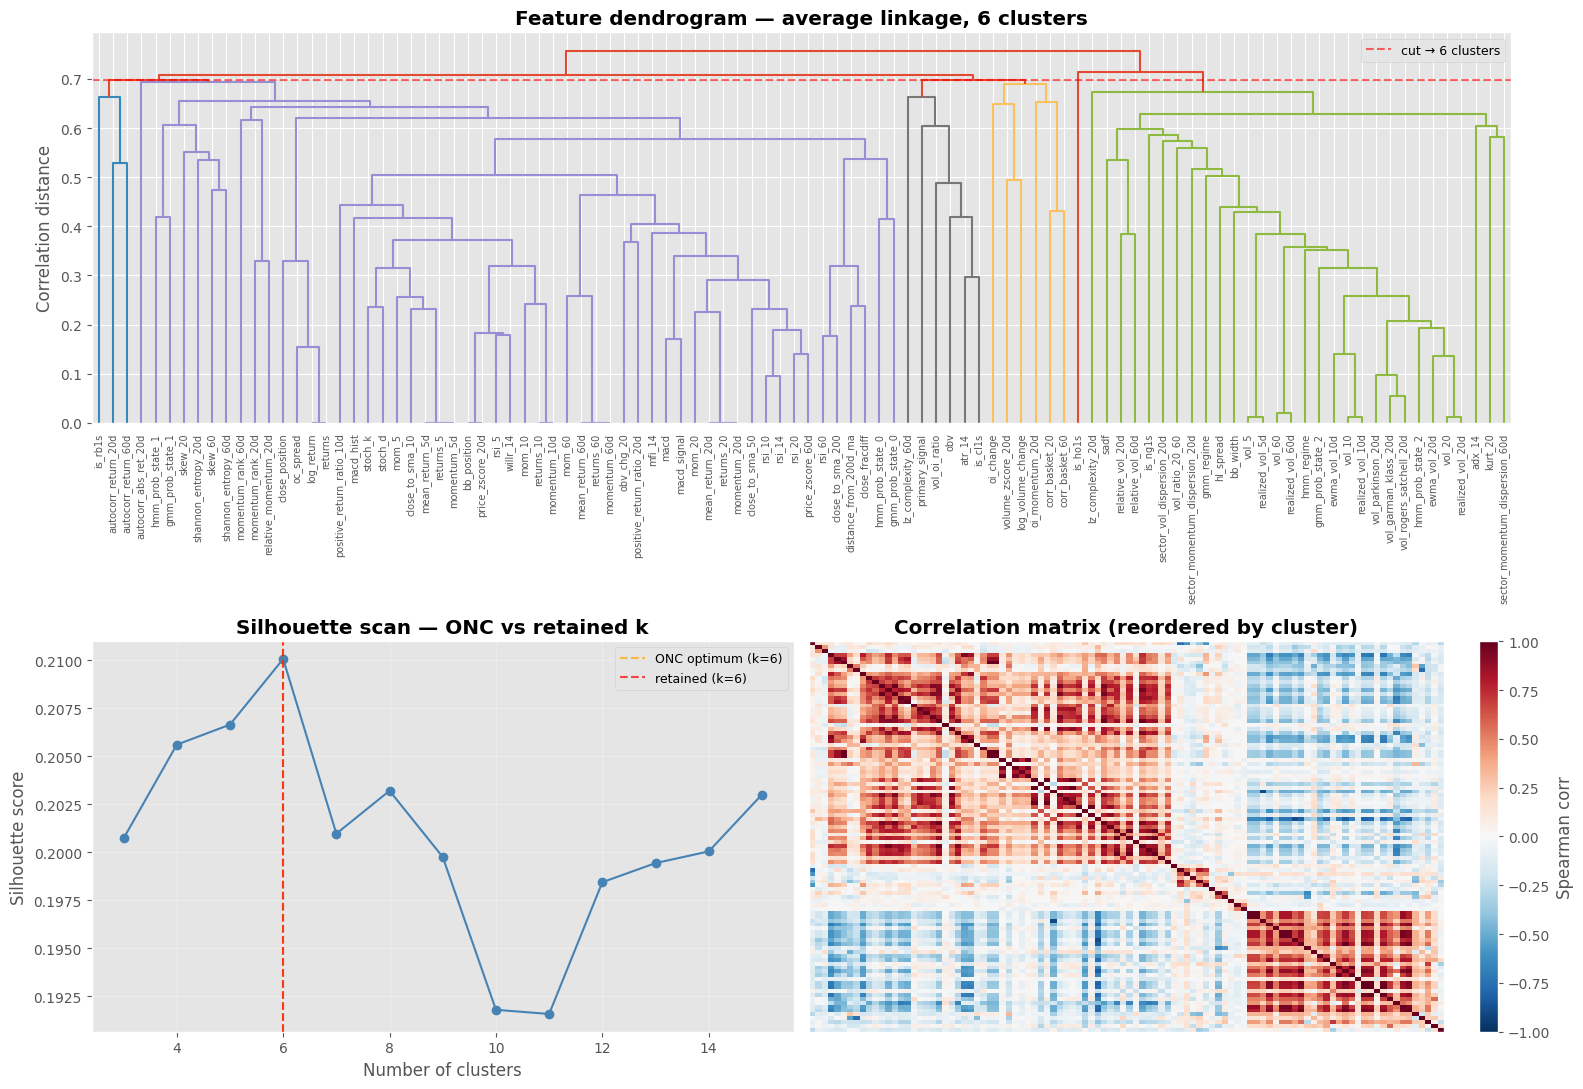

In [160]:
# ==============================================================================
# STEP 4 — PHASE 1: VISUALIZATIONS
# ==============================================================================
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 11))

# (1) Dendrogram
ax1 = fig.add_subplot(2, 1, 1)
dendrogram(
    Z, labels=META_FEATURES, ax=ax1,
    color_threshold=Z[-(best_k-1), 2],
    leaf_font_size=7,
)
ax1.set_title(f"Feature dendrogram — average linkage, {best_k} clusters", fontweight="bold")
ax1.set_ylabel("Correlation distance")
ax1.axhline(Z[-(best_k-1), 2], color="red", ls="--", alpha=0.6, label=f"cut → {best_k} clusters")
ax1.legend(fontsize=9)

# (2) Silhouette scan (ONC diagnostic) with both ONC and retained k marked
ax2 = fig.add_subplot(2, 2, 3)
ax2.plot(list(candidate_k), sil_scores, "o-", color="steelblue")
ax2.axvline(onc_k,  color="orange", ls="--", alpha=0.7, label=f"ONC optimum (k={onc_k})")
ax2.axvline(best_k, color="red",    ls="--", alpha=0.7, label=f"retained (k={best_k})")
ax2.set_xlabel("Number of clusters"); ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette scan — ONC vs retained k", fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# (3) Correlation heatmap reordered by cluster
ax3 = fig.add_subplot(2, 2, 4)
order = feature_clusters.sort_values().index
corr_ordered = corr.loc[order, order]
im = ax3.imshow(corr_ordered.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax3.set_title("Correlation matrix (reordered by cluster)", fontweight="bold")
ax3.set_xticks([]); ax3.set_yticks([])
fig.colorbar(im, ax=ax3, fraction=0.046, label="Spearman corr")

plt.tight_layout(); plt.show()

### Step 1 (revised): Semantic Feature Clusters

The hierarchical clustering above reveals a **weak correlation structure** (silhouette peaks at only 0.21) with one dominant ~53-feature block that does not split cleanly — raising k merely peels off isolated singletons while the core block stays intact. This is expected when features lie on a **correlation continuum** rather than in well-separated groups, consistent with the diffuse signal observed throughout the project.

We therefore adopt **semantic clusters** defined by economic meaning — an approach López de Prado explicitly endorses when correlation structure is weak. It is preferable here because: (1) the feature families are known by construction, (2) it yields balanced, interpretable groups, and (3) it produces a **clean regime cluster** (the 8 HMM/GMM features), enabling the key test of whether the regimes added *collective* value — impossible when those features are scattered across algorithmic clusters.

The dendrogram and silhouette scan are retained as **exploratory diagnostics** justifying this choice; the importance analysis (Phase 2) uses the semantic clusters below.

In [161]:
# ==============================================================================
# STEP 4 — PHASE 1 (REVISED): SEMANTIC FEATURE CLUSTERS
# ==============================================================================
# Clusters defined by economic meaning. Rules are ORDER-SENSITIVE (first match
# wins) to resolve ambiguous names correctly:
#   - vol_oi_ratio        -> Volume/OI   (not Volatility, despite "vol_")
#   - relative_vol_*       -> Cross-asset (relative, not raw volatility)
#   - sector_vol_dispersion-> Cross-asset
#   - momentum_rank_*      -> Cross-asset (ranked, not raw momentum)
import pandas as pd

semantic_rules = [
    # Regimes FIRST (clean isolation of the HMM/GMM pipeline output)
    ("Regimes (HMM/GMM)", lambda f: f.startswith(("hmm_", "gmm_"))),

    # Cross-asset BEFORE volatility/momentum (catches relative_*, sector_*, rank)
    ("Cross-asset", lambda f: any(k in f for k in
        ["corr_basket", "relative_vol", "relative_momentum", "momentum_rank",
         "sector_momentum", "sector_vol"])),

    # Volume / Open interest BEFORE volatility (catches vol_oi_ratio)
    ("Volume/OI", lambda f: any(k in f for k in
        ["obv", "mfi", "volume", "oi_change", "oi_momentum", "vol_oi"])),

    # Volatility
    ("Volatility", lambda f: any(k in f for k in
        ["vol_5", "vol_10", "vol_20", "vol_60", "realized_vol", "vol_parkinson",
         "vol_garman", "vol_rogers", "atr_", "bb_width", "bb_position",
         "vol_ratio", "ewma_vol"])),

    # Momentum / Trend / Oscillators
    ("Momentum/Trend", lambda f: any(k in f for k in
        ["momentum_", "mom_", "macd", "rsi_", "stoch", "willr", "adx",
         "close_to_sma", "distance_from_200d"])),

    # Returns / Price action
    ("Returns/Price", lambda f: any(k in f for k in
        ["returns", "log_return", "mean_return", "oc_spread", "hl_spread",
         "close_position", "price_zscore", "close_fracdiff",
         "positive_return_ratio"])),

    # Distribution / Complexity / Bubble
    ("Distribution/Complexity", lambda f: any(k in f for k in
        ["skew", "kurt", "autocorr", "shannon_entropy", "lz_complexity", "sadf"])),

    # Instrument one-hot
    ("Instrument", lambda f: f.startswith("is_")),

    # Primary signal (single feature, kept separate)
    ("Primary signal", lambda f: f == "primary_signal"),
]

def assign_cluster(feat):
    for name, rule in semantic_rules:
        if rule(feat):
            return name
    return "Other"

feature_clusters = pd.Series({f: assign_cluster(f) for f in META_FEATURES}, name="cluster")

clusters = {}
for feat, cl in feature_clusters.items():
    clusters.setdefault(cl, []).append(feat)

# Report, largest cluster first
print(f"{len(clusters)} semantic clusters:\n")
for cl in sorted(clusters, key=lambda c: -len(clusters[c])):
    members = clusters[cl]
    print(f"  {cl:26s} ({len(members):>2}): {', '.join(members[:6])}"
          + (f", ... (+{len(members)-6})" if len(members) > 6 else ""))

# Safety checks
assigned = sum(len(v) for v in clusters.values())
assert assigned == len(META_FEATURES), f"Mismatch: {assigned} vs {len(META_FEATURES)}"
print(f"\n✓ All {len(META_FEATURES)} features assigned.")
if "Other" in clusters:
    print(f"⚠ 'Other': {clusters['Other']}")
else:
    print("✓ No feature fell into 'Other'.")

9 semantic clusters:

  Momentum/Trend             (24): momentum_5d, rsi_5, mom_5, momentum_10d, rsi_10, mom_10, ... (+18)
  Returns/Price              (17): log_return, hl_spread, oc_spread, close_position, returns, returns_5, ... (+11)
  Volatility                 (17): vol_5, realized_vol_5d, vol_10, realized_vol_10d, vol_20, realized_vol_20d, ... (+11)
  Distribution/Complexity    (11): skew_20, kurt_20, skew_60, autocorr_return_20d, autocorr_abs_ret_20d, autocorr_return_60d, ... (+5)
  Cross-asset                (10): corr_basket_20, corr_basket_60, momentum_rank_20d, momentum_rank_60d, relative_vol_20d, relative_vol_60d, ... (+4)
  Volume/OI                  ( 8): obv, obv_chg_20, mfi_14, volume_zscore_20d, log_volume_change, oi_change, ... (+2)
  Regimes (HMM/GMM)          ( 8): hmm_regime, hmm_prob_state_0, hmm_prob_state_1, hmm_prob_state_2, gmm_regime, gmm_prob_state_0, ... (+2)
  Instrument                 ( 4): is_cl1s, is_ho1s, is_ng1s, is_rb1s
  Primary signal           

### Step 2: Cluster-Level Importance (MDI, MDA, SHAP)

We measure the importance of each semantic cluster using three complementary methods, all computed on the **winning LightGBM model**:

- **MDI (Mean Decrease Impurity)** — native LightGBM gain importance, summed per cluster. Fast but biased (favors high-cardinality features, measures in-sample split usefulness, not OOS predictive impact).
- **MDA (Mean Decrease Accuracy)** — López de Prado's preferred method. All features of a cluster are **permuted together** on the validation fold; the resulting AUC drop measures the cluster's true, non-substitutable predictive value. Computed in CPCV (no test leakage). This is the most reliable measure and directly answers whether regime features matter *collectively*.
- **SHAP** — mean absolute Shapley values summed per cluster. Theoretically grounded marginal-contribution attribution, providing a third independent view.

Cluster-level permutation is the key idea: permuting a whole cluster removes all redundant substitutes at once, so the AUC drop reflects the information the cluster uniquely carries.

In [162]:
# ==============================================================================
# STEP 4 — PHASE 2: CLUSTER-LEVEL IMPORTANCE (MDI, MDA, SHAP)
# ==============================================================================
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
from sklearn.metrics import roc_auc_score

cluster_names = list(clusters.keys())
feat_index = {f: i for i, f in enumerate(META_FEATURES)}   # feature -> column index

# ------------------------------------------------------------------------------
# Method 1 — MDI (native gain), summed per cluster (uses already-fitted best_lgb)
# ------------------------------------------------------------------------------
mdi_feat = pd.Series(best_lgb.feature_importances_, index=META_FEATURES)
mdi_cluster = {cl: mdi_feat[clusters[cl]].sum() for cl in cluster_names}
mdi_cluster = pd.Series(mdi_cluster)
mdi_cluster = mdi_cluster / mdi_cluster.sum()   # normalize to fractions

# ------------------------------------------------------------------------------
# Method 2 — MDA (clustered permutation) in CPCV, AUC drop per cluster
# ------------------------------------------------------------------------------
def clustered_mda(X, y, cv, clusters, params, n_repeats=3, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    # accumulate AUC drop per cluster across folds
    drops = {cl: [] for cl in clusters}
    for train_idx, val_idx in cv.split(X):
        model = lgb.LGBMClassifier(**params)
        model.fit(X[train_idx], y[train_idx])
        Xv = X[val_idx]
        base_auc = roc_auc_score(y[val_idx], model.predict_proba(Xv)[:, 1])
        for cl, feats in clusters.items():
            cols = [feat_index[f] for f in feats]
            rep_drops = []
            for _ in range(n_repeats):
                Xp = Xv.copy()
                # permute ALL columns of the cluster jointly (shuffle rows)
                perm = rng.permutation(len(Xp))
                Xp[:, cols] = Xp[perm][:, cols]
                auc_perm = roc_auc_score(y[val_idx], model.predict_proba(Xp)[:, 1])
                rep_drops.append(base_auc - auc_perm)
            drops[cl].append(np.mean(rep_drops))
    return pd.Series({cl: np.mean(v) for cl, v in drops.items()})

# Use the winning model's hyperparameters
mda_params = dict(objective="binary", verbosity=-1, random_state=RANDOM_STATE,
                  n_jobs=-1, class_weight="balanced", **best_params_lgb)
mda_cluster = clustered_mda(X_train, y_train, cpcv, clusters, mda_params)

# ------------------------------------------------------------------------------
# Method 3 — SHAP, mean|value| summed per cluster (on best_lgb over train)
# ------------------------------------------------------------------------------
explainer = shap.TreeExplainer(best_lgb)
sv = explainer.shap_values(X_train)
sv_pos = sv[:, :, 1] if (isinstance(sv, np.ndarray) and sv.ndim == 3) else sv
shap_feat = pd.Series(np.abs(sv_pos).mean(axis=0), index=META_FEATURES)
shap_cluster = {cl: shap_feat[clusters[cl]].sum() for cl in cluster_names}
shap_cluster = pd.Series(shap_cluster)
shap_cluster = shap_cluster / shap_cluster.sum()

# ------------------------------------------------------------------------------
# Combine into one comparison table (each method normalized to fractions/positive)
# ------------------------------------------------------------------------------
importance_df = pd.DataFrame({
    "MDI":  mdi_cluster,
    "MDA":  mda_cluster,
    "SHAP": shap_cluster,
}).fillna(0.0)

# Sort by MDA (the most reliable method)
importance_df = importance_df.sort_values("MDA", ascending=False)

print("="*70)
print("CLUSTER-LEVEL IMPORTANCE (sorted by MDA)")
print("="*70)
print(importance_df.round(4).to_string())
print("="*70)
print("\nNote: MDI & SHAP are normalized fractions; MDA is raw AUC drop")
print("(higher = more important; negative MDA = cluster adds noise).")

/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMCla

CLUSTER-LEVEL IMPORTANCE (sorted by MDA)
                            MDI     MDA    SHAP
Volatility               0.1916  0.0752  0.2529
Cross-asset              0.1150  0.0352  0.1206
Momentum/Trend           0.2667  0.0120  0.3165
Volume/OI                0.0977  0.0033  0.0615
Primary signal           0.0120  0.0025  0.0226
Distribution/Complexity  0.1450  0.0016  0.1007
Instrument               0.0008  0.0002  0.0003
Regimes (HMM/GMM)        0.0383 -0.0010  0.0247
Returns/Price            0.1330 -0.0029  0.1003

Note: MDI & SHAP are normalized fractions; MDA is raw AUC drop
(higher = more important; negative MDA = cluster adds noise).


/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


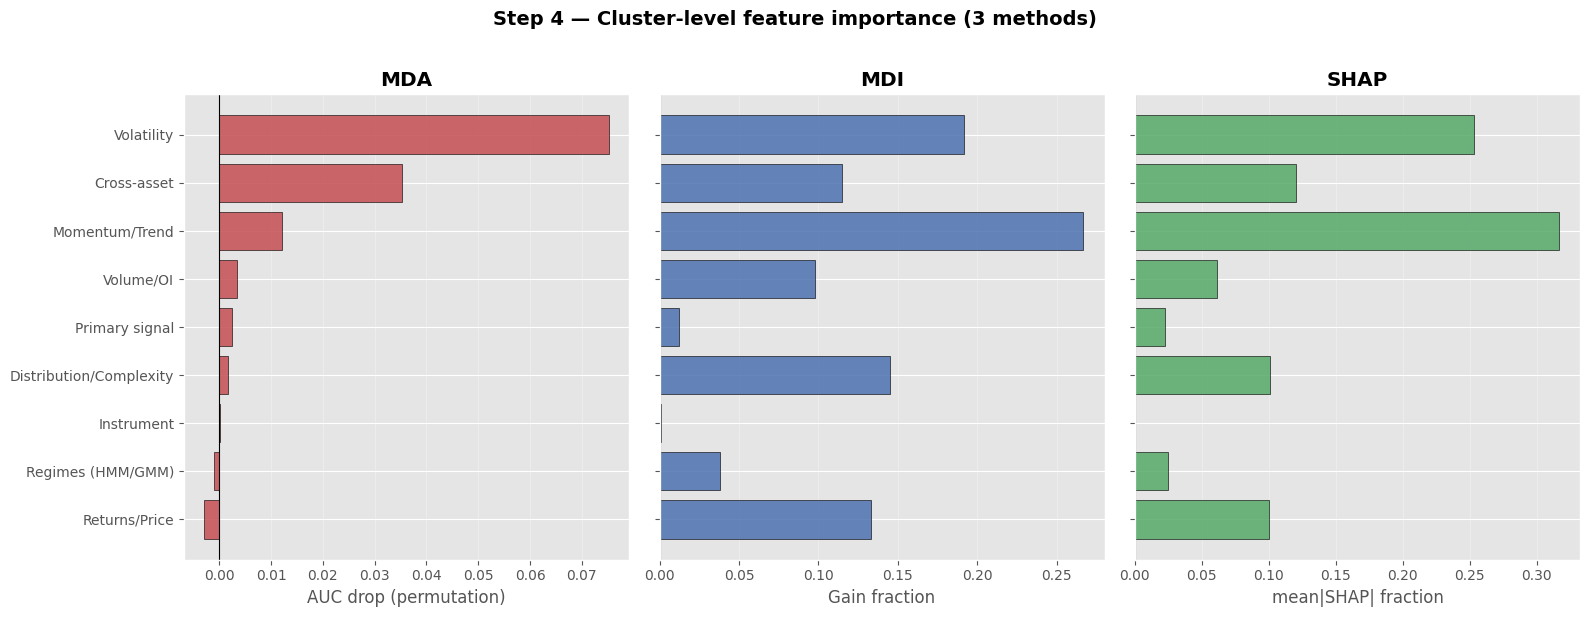

In [163]:
# ==============================================================================
# STEP 4 — PHASE 2: VISUALIZATION
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

order = importance_df.index.tolist()
y_pos = np.arange(len(order))

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

for ax, method, color in zip(axes, ["MDA", "MDI", "SHAP"],
                              ["#C44E52", "#4C72B0", "#55A868"]):
    vals = importance_df.loc[order, method].values
    ax.barh(y_pos, vals, color=color, alpha=0.85, edgecolor="black")
    ax.set_yticks(y_pos); ax.set_yticklabels(order)
    ax.invert_yaxis()
    ax.set_title(f"{method}", fontweight="bold")
    ax.axvline(0, color="black", lw=0.8)
    ax.grid(alpha=0.3, axis="x")

axes[0].set_xlabel("AUC drop (permutation)")
axes[1].set_xlabel("Gain fraction")
axes[2].set_xlabel("mean|SHAP| fraction")
fig.suptitle("Step 4 — Cluster-level feature importance (3 methods)",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## Step 4 — Conclusion: Cluster-Level Feature Importance

Importance was measured on the winning LightGBM model across nine semantic clusters, using three complementary methods (MDI, MDA, SHAP). The MDA (clustered permutation, computed in CPCV) is the most reliable as it captures *non-substitutable* predictive value.

**Volatility dominates.** It ranks first on MDA (0.075) and SHAP (0.253) and second on MDI — a consensus across all three methods making the conclusion robust. Volatility information is the backbone of the metamodel, which is economically sensible: in meta-labeling, the prevailing volatility regime is decisive for judging whether a primary signal will hold. **Cross-asset** features rank second on MDA (0.035), validating the relative and sector-dispersion features.

**MDI/MDA divergence reveals redundancy.** Momentum/Trend ranks first on MDI (0.267) and SHAP (0.317) but only third on MDA (0.012). This gap is the core insight cluster analysis provides: momentum is heavily *used* by the model but highly *substitutable* — permuting it costs little AUC because other features compensate. It is abundant but redundant information, unlike volatility which is both used and irreplaceable.

**The HMM/GMM regime pipeline added no marginal value.** The regime cluster has a **negative MDA (−0.001)**, with low MDI (0.038) and SHAP (0.025) — all three methods agree. Permuting the regime features does not hurt (slightly helps) AUC, meaning they carry no non-substitutable information at the metamodel level. The interpretation is clear and honest: market-regime information is **already captured, more directly, by the raw volatility features**. A regime is largely characterized by its volatility level, and `realized_vol`/`vol_60` express this more usably for the tree than the latent state probabilities of the HMM/GMM regimes. The latent-model machinery, while methodologically sound, is **redundant with direct volatility features** for this task.

**Candidates for pruning.** Both the regime cluster and Returns/Price show negative MDA, and the Instrument cluster is near-zero everywhere — all candidates for removal in a feature-refinement cycle. This analysis thus directly informs the next iteration: drop redundant/noise clusters, keep the volatility and cross-asset cores.

**Methodological note.** The analysis used semantic clusters rather than the algorithmic ones, because the correlation structure proved diffuse (silhouette ≈ 0.21, one oversized algorithmic cluster). Semantic grouping yields interpretable families and, crucially, a clean regime cluster — without which the regime verdict above would have been impossible.

## Ensembling — Combining the Three Families

The three model families capture different aspects of the signal: the linear model sees additive relationships, LightGBM non-linear interactions, the MLP yet another non-linear mapping. A weighted average of their **probabilities** often beats the best individual model, since their errors are partially decorrelated.

We evaluate the ensemble **in CPCV on the training set** (no test leakage), exactly as for the individual models, so the comparison is fair. The ensemble becomes the final model **only if it beats LightGBM's CPCV AUC (0.623)** — otherwise we keep LightGBM alone, since a weak member (the MLP at 0.553) can drag a naive average down.

We test two weighting schemes: a simple equal-weight average, and an AUC-weighted average favoring stronger models.

In [ ]:
# ==============================================================================
# ENSEMBLING — CPCV evaluation of probability averaging
# ==============================================================================
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# Retrieve the robust hyperparameters of each family
lgb_params = dict(objective="binary", verbosity=-1, random_state=RANDOM_STATE,
                  n_jobs=-1, class_weight="balanced", **best_params_lgb)
logreg_C = bt_robust.params["C"]
mlp_p = bt_mlp_robust.params
mlp_layers = mlp_p["n_layers"]
mlp_hidden = [mlp_p[f"n_units_l{i}"] for i in range(mlp_layers)]


def get_fold_probabilities(X, y, train_idx, val_idx):
    """Train all three families on train_idx, return their P(class=1) on val_idx."""
    # --- LightGBM (no scaling needed) ---
    m_lgb = lgb.LGBMClassifier(**lgb_params)
    m_lgb.fit(X[train_idx], y[train_idx])
    p_lgb = m_lgb.predict_proba(X[val_idx])[:, 1]

    # --- Logistic (scaled) ---
    m_log = Pipeline([("sc", RobustScaler()),
                      ("m", LogisticRegression(C=logreg_C, penalty="l2",
                            class_weight="balanced", solver="lbfgs",
                            max_iter=2000, random_state=RANDOM_STATE))])
    m_log.fit(X[train_idx], y[train_idx])
    p_log = m_log.predict_proba(X[val_idx])[:, 1]

    # --- MLP (scaled, with internal early-stopping split) ---
    cut = int(len(train_idx) * 0.8)
    inner_tr, inner_va = train_idx[:cut], train_idx[cut:]
    scaler = RobustScaler().fit(X[inner_tr])
    X_itr = scaler.transform(X[inner_tr]).astype(np.float32)
    X_iva = scaler.transform(X[inner_va]).astype(np.float32)
    X_val = scaler.transform(X[val_idx]).astype(np.float32)
    m_mlp = train_mlp(X_itr, y[inner_tr], X_iva, y[inner_va],
                      hidden_sizes=mlp_hidden, dropout=mlp_p["dropout"],
                      lr=mlp_p["lr"], weight_decay=mlp_p["weight_decay"])
    p_mlp = predict_proba_mlp(m_mlp, X_val)

    return p_log, p_lgb, p_mlp


# Collect per-fold AUC for: individuals, equal-weight, AUC-weighted ensembles
results = {"logistic": [], "lightgbm": [], "mlp": [],
           "ens_equal": [], "ens_weighted": []}

for train_idx, val_idx in cpcv.split(X_train):
    p_log, p_lgb, p_mlp = get_fold_probabilities(X_train, y_train, train_idx, val_idx)
    yv = y_train[val_idx]

    auc_log = roc_auc_score(yv, p_log)
    auc_lgb = roc_auc_score(yv, p_lgb)
    auc_mlp = roc_auc_score(yv, p_mlp)
    results["logistic"].append(auc_log)
    results["lightgbm"].append(auc_lgb)
    results["mlp"].append(auc_mlp)

    # Equal-weight average
    p_eq = (p_log + p_lgb + p_mlp) / 3
    results["ens_equal"].append(roc_auc_score(yv, p_eq))

    # AUC-weighted average (weights from this fold's individual AUCs, centered)
    w = np.array([auc_log, auc_lgb, auc_mlp]) - 0.5   # excess over random
    w = np.clip(w, 0, None); w = w / w.sum() if w.sum() > 0 else np.ones(3)/3
    p_wt = w[0]*p_log + w[1]*p_lgb + w[2]*p_mlp
    results["ens_weighted"].append(roc_auc_score(yv, p_wt))

# Summary
summary = pd.DataFrame({
    "mean_AUC": {k: np.mean(v) for k, v in results.items()},
    "std_AUC":  {k: np.std(v, ddof=1) for k, v in results.items()},
}).sort_values("mean_AUC", ascending=False)

print("="*60)
print("CPCV AUC — individuals vs ensembles")
print("="*60)
print(summary.round(4).to_string())
print("="*60)

best_approach = summary.index[0]
print(f"\nBest approach by CPCV AUC: {best_approach}")
if best_approach.startswith("ens"):
    print(">>> Ensemble wins — it will be the final model.")
else:
    print(">>> LightGBM (or other individual) wins — keep it as final model.")


# ------------------------------------------------------------------------------
# Freeze GLOBAL ensemble weights from CPCV mean AUCs (excess over 0.5).
# These fixed weights are reused everywhere (OOS proba, final eval) so the
# final model is reproducible — unlike per-fold weights which cannot be
# applied outside cross-validation.
# ------------------------------------------------------------------------------
auc_log_cv = summary.loc["logistic", "mean_AUC"]
auc_lgb_cv = summary.loc["lightgbm", "mean_AUC"]
auc_mlp_cv = summary.loc["mlp", "mean_AUC"]

w_raw = np.clip(np.array([auc_log_cv, auc_lgb_cv, auc_mlp_cv]) - 0.5, 0, None)
ENSEMBLE_WEIGHTS = w_raw / w_raw.sum()   # [w_logistic, w_lightgbm, w_mlp]

print(f"\nFrozen ensemble weights (logistic, lightgbm, mlp):")
print(f"  {ENSEMBLE_WEIGHTS.round(4)}")

/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-

CPCV AUC — individuals vs ensembles
              mean_AUC  std_AUC
ens_weighted    0.6333   0.0402
lightgbm        0.6209   0.0449
ens_equal       0.6161   0.0524
logistic        0.5767   0.0421
mlp             0.5531   0.0343

Best approach by CPCV AUC: ens_weighted
>>> Ensemble wins — it will be the final model.


/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Probability Calibration

Well-calibrated probabilities (a predicted 0.7 should correspond to ~70% actual win-rate) matter for the optional position-sizing track and for a meaningful threshold. We calibrate the final model's probabilities post-hoc.

**Key methodological point:** calibration must be learned on data the model did **not** train on, otherwise it fits over-optimistic in-sample probabilities. We therefore calibrate on the **CPCV out-of-sample probabilities of the training set** (honest, unseen-in-fold probabilities) — never on the test set.

**Placement in the pipeline:** after model selection, before threshold tuning (the threshold is then chosen on *calibrated* probabilities). We compare **Platt scaling** (sigmoid, robust on small data) and **Isotonic regression** (flexible, needs more data) via the Brier score, and keep the better one.

/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nathansebbag/venvs/pyarm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-

Brier score on train OOS probabilities (lower = better):
  raw (uncalibrated) : 0.2387
  Platt scaling      : 0.2368
  Isotonic           : 0.2306

>>> Selected: Isotonic


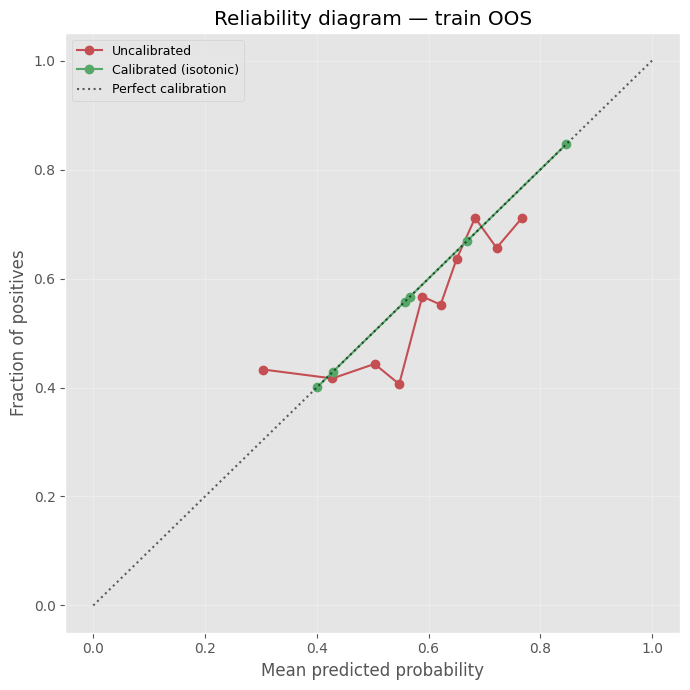

In [168]:
# ==============================================================================
# PROBABILITY CALIBRATION (learned on train OOS probabilities, no leakage)
# ==============================================================================
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# OOS probabilities of the FINAL model on the train set (already computed logic)
# Reuse get_oos_probabilities from the threshold step.
oos_proba_train = get_oos_probabilities(X_train, y_train, cpcv, FINAL_MODEL)

# --- Fit both calibrators on (oos_proba -> y_train) ---
# Platt: logistic regression on the single probability feature
platt = LogisticRegression(C=1e6, solver="lbfgs")   # C huge ≈ unregularized sigmoid fit
platt.fit(oos_proba_train.reshape(-1, 1), y_train)
proba_platt = platt.predict_proba(oos_proba_train.reshape(-1, 1))[:, 1]

# Isotonic: monotonic piecewise fit
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(oos_proba_train, y_train)
proba_iso = iso.predict(oos_proba_train)

# --- Compare calibration quality via Brier (lower = better) ---
brier_raw   = brier_score_loss(y_train, oos_proba_train)
brier_platt = brier_score_loss(y_train, proba_platt)
brier_iso   = brier_score_loss(y_train, proba_iso)

print("Brier score on train OOS probabilities (lower = better):")
print(f"  raw (uncalibrated) : {brier_raw:.4f}")
print(f"  Platt scaling      : {brier_platt:.4f}")
print(f"  Isotonic           : {brier_iso:.4f}")

# Choose the better calibrator
if brier_platt <= brier_iso:
    CALIBRATOR, calib_name = platt, "platt"
    print(f"\n>>> Selected: Platt scaling")
else:
    CALIBRATOR, calib_name = iso, "isotonic"
    print(f"\n>>> Selected: Isotonic")


def apply_calibration(proba_raw):
    """Apply the selected calibrator to raw probabilities."""
    if calib_name == "platt":
        return CALIBRATOR.predict_proba(proba_raw.reshape(-1, 1))[:, 1]
    return CALIBRATOR.predict(proba_raw)


# --- Reliability diagram: before vs after ---
fig, ax = plt.subplots(figsize=(7, 7))
for proba, label, color in [(oos_proba_train, "Uncalibrated", "#C44E52"),
                            (apply_calibration(oos_proba_train), f"Calibrated ({calib_name})", "#55A868")]:
    frac_pos, mean_pred = calibration_curve(y_train, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", label=label, color=color)
ax.plot([0, 1], [0, 1], "k:", alpha=0.6, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Fraction of positives")
ax.set_title("Reliability diagram — train OOS")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Step 5a — Decision Threshold Optimization

The model outputs a probability; the binary decision (take the trade or not) requires a threshold. The default 0.5 is arbitrary. In meta-labeling the costs are **asymmetric** — a false positive (a losing trade taken) costs real money, while a false negative (a winning trade missed) is only an opportunity cost — so a higher, more selective threshold is often preferable.

**Crucially, the threshold is chosen on the TRAINING set's OOS probabilities (via CPCV), never on the test set.** This keeps the test untouched until the single final evaluation. We sweep thresholds and select the one maximizing MCC (robust to imbalance), then apply it once to the test in Step 5b.

In [ ]:
# ==============================================================================
# STEP 5a — THRESHOLD OPTIMIZATION (on train OOS probabilities, no leakage)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef

# --- Set the final model based on the ensembling decision above ---
# If the ensemble won, FINAL_MODEL = "ensemble"; else "lightgbm".
FINAL_MODEL = "lightgbm" if not best_approach.startswith("ens") else "ensemble"
print(f"Final model for threshold tuning: {FINAL_MODEL}\n")


def get_oos_probabilities(X, y, cv, model_kind):
    """OOS P(class=1) for each obs, averaged over folds where it was validation."""
    proba_sum = np.zeros(len(X)); proba_count = np.zeros(len(X))
    for train_idx, val_idx in cv.split(X):
        p_log, p_lgb, p_mlp = get_fold_probabilities(X, y, train_idx, val_idx)
        if model_kind == "lightgbm":
            p = p_lgb
        else:  # weighted ensemble using the FROZEN global weights
            p = (ENSEMBLE_WEIGHTS[0]*p_log +
                 ENSEMBLE_WEIGHTS[1]*p_lgb +
                 ENSEMBLE_WEIGHTS[2]*p_mlp)
        proba_sum[val_idx] += p; proba_count[val_idx] += 1
    return proba_sum / np.maximum(proba_count, 1)


def threshold_analysis(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.30, 0.71, 0.02)
    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        n_pos = int(y_pred.sum())
        rows.append({
            "threshold":  round(float(t), 3),
            "precision":  precision_score(y_true, y_pred, zero_division=0),
            "recall":     recall_score(y_true, y_pred, zero_division=0),
            "f1":         f1_score(y_true, y_pred, zero_division=0),
            "mcc":        matthews_corrcoef(y_true, y_pred) if 0 < n_pos < len(y_pred) else 0.0,
            "n_trades":   n_pos,
            "pct_trades": round(100 * n_pos / len(y_pred), 1),
        })
    return pd.DataFrame(rows)


# Threshold tuned on CALIBRATED OOS probabilities
oos_proba_train_cal = apply_calibration(oos_proba_train)
thr_df = threshold_analysis(y_train, oos_proba_train_cal)
print(thr_df.to_string(index=False))
best_threshold = thr_df.loc[thr_df["mcc"].idxmax(), "threshold"]

print(f"\nOptimal threshold (max MCC): {best_threshold}")
print("Comparison default 0.5 vs optimal:")
print(thr_df[thr_df["threshold"].isin([0.5, best_threshold])].to_string(index=False))

Final model for threshold tuning: ensemble

 threshold  precision   recall       f1      mcc  n_trades  pct_trades
      0.30   0.555671 1.000000 0.714381 0.071813       961        99.6
      0.32   0.555671 1.000000 0.714381 0.071813       961        99.6
      0.34   0.555671 1.000000 0.714381 0.071813       961        99.6
      0.36   0.555671 1.000000 0.714381 0.071813       961        99.6
      0.38   0.555671 1.000000 0.714381 0.071813       961        99.6
      0.40   0.560557 0.979401 0.713020 0.078087       933        96.7
      0.42   0.585213 0.874532 0.701201 0.140025       798        82.7
      0.44   0.641156 0.705993 0.672014 0.220533       588        60.9
      0.46   0.641156 0.705993 0.672014 0.220533       588        60.9
      0.48   0.641156 0.705993 0.672014 0.220533       588        60.9
      0.50   0.641156 0.705993 0.672014 0.220533       588        60.9
      0.52   0.641156 0.705993 0.672014 0.220533       588        60.9
      0.54   0.641156 0.705993 0.

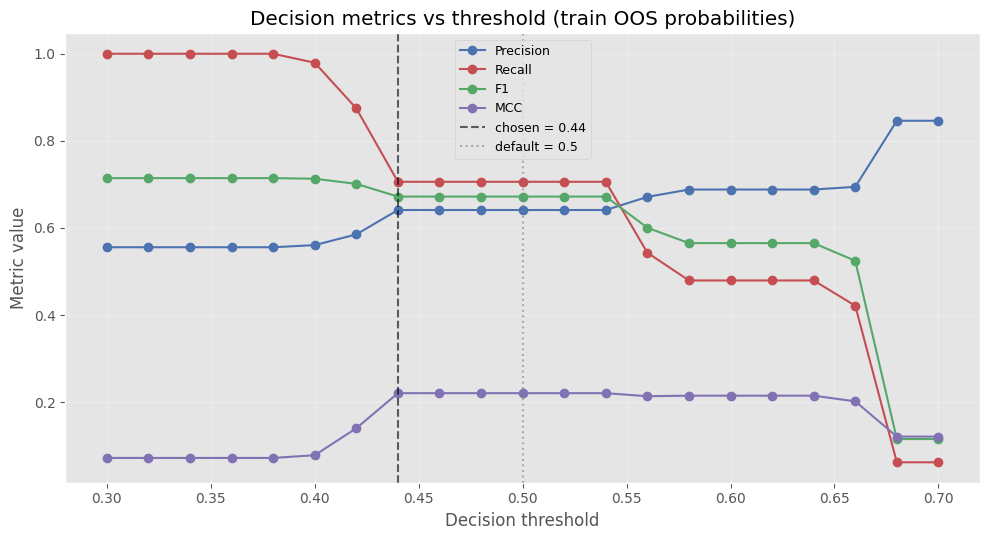

In [170]:
# ==============================================================================
# STEP 5a — THRESHOLD VISUALIZATION
# ==============================================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(thr_df["threshold"], thr_df["precision"], "o-", label="Precision", color="#4C72B0")
ax.plot(thr_df["threshold"], thr_df["recall"],    "o-", label="Recall",    color="#C44E52")
ax.plot(thr_df["threshold"], thr_df["f1"],        "o-", label="F1",        color="#55A868")
ax.plot(thr_df["threshold"], thr_df["mcc"],       "o-", label="MCC",       color="#8172B3")
ax.axvline(best_threshold, color="black", ls="--", alpha=0.6, label=f"chosen = {best_threshold}")
ax.axvline(0.5, color="grey", ls=":", alpha=0.6, label="default = 0.5")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Metric value")
ax.set_title("Decision metrics vs threshold (train OOS probabilities)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Step 5b — Final Out-of-Sample Evaluation

This is the **single, final use of the test set**. The model (final choice from ensembling) and the decision threshold (tuned on train OOS) are now **frozen**. We:
1. Refit the final model on the full training set.
2. Predict on the untouched test set, apply the frozen threshold.
3. Report all metrics, the confusion matrix, a **per-instrument breakdown**, and a comparison against the **baseline** (blindly following every primary signal).

The baseline is the meta-labeling benchmark: what would happen if we took *every* primary signal without filtering. The metamodel earns its place only if it beats this baseline.

In [ ]:
"""# ==============================================================================
# STEP 5b — FINAL OOS EVALUATION (test touched ONCE)
# ==============================================================================
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 1. Refit the final model on the FULL training set
# ------------------------------------------------------------------------------
if FINAL_MODEL == "lightgbm":
    final_model = lgb.LGBMClassifier(**lgb_params)
    final_model.fit(X_train, y_train)
    proba_test = final_model.predict_proba(X_test)[:, 1]
else:
    # Ensemble: refit all three on full train, average probabilities on test
    m_lgb = lgb.LGBMClassifier(**lgb_params); m_lgb.fit(X_train, y_train)
    m_log = Pipeline([("sc", RobustScaler()),
                      ("m", LogisticRegression(C=logreg_C, penalty="l2",
                            class_weight="balanced", solver="lbfgs",
                            max_iter=2000, random_state=RANDOM_STATE))])
    m_log.fit(X_train, y_train)
    cut = int(len(X_train) * 0.8)
    scaler = RobustScaler().fit(X_train[:cut])
    m_mlp = train_mlp(scaler.transform(X_train[:cut]).astype(np.float32), y_train[:cut],
                      scaler.transform(X_train[cut:]).astype(np.float32), y_train[cut:],
                      hidden_sizes=mlp_hidden, dropout=mlp_p["dropout"],
                      lr=mlp_p["lr"], weight_decay=mlp_p["weight_decay"])
    p_lgb = m_lgb.predict_proba(X_test)[:, 1]
    p_log = m_log.predict_proba(X_test)[:, 1]
    p_mlp = predict_proba_mlp(m_mlp, scaler.transform(X_test).astype(np.float32))
    proba_test = (ENSEMBLE_WEIGHTS[0]*p_log +
                  ENSEMBLE_WEIGHTS[1]*p_lgb +
                  ENSEMBLE_WEIGHTS[2]*p_mlp)

# Apply the frozen calibrator to test probabilities
proba_test_raw = proba_test.copy()           # keep raw for comparison if needed
proba_test = apply_calibration(proba_test)    # calibrated probabilities

# Then the frozen threshold on calibrated probabilities
y_pred_test = (proba_test >= best_threshold).astype(int)

# ------------------------------------------------------------------------------
# 3. Full metric report
# ------------------------------------------------------------------------------
test_metrics = compute_all_metrics(y_test, y_pred_test, proba_test)
print("="*60)
print(f"FINAL OOS METRICS — model={FINAL_MODEL}, threshold={best_threshold}")
print("="*60)
for k, v in test_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

conf = compute_confusion(y_test, y_pred_test)
print(f"\nConfusion matrix (OOS):")
print(f"               Pred 0    Pred 1")
print(f"True 0     {conf['tn']:>8}  {conf['fp']:>8}")
print(f"True 1     {conf['fn']:>8}  {conf['tp']:>8}")

# ------------------------------------------------------------------------------
# 4. Baseline: blindly follow every primary signal (take ALL trades)
#    Meta-label = 1 means "the primary signal was profitable". Taking every
#    trade => predict all 1 => baseline metrics.
# ------------------------------------------------------------------------------
y_pred_baseline = np.ones_like(y_test)
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
print("\n" + "="*60)
print("BASELINE — follow every primary signal (no filtering)")
print("="*60)
print(f"  accuracy : {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"  precision: {precision_score(y_test, y_pred_baseline, zero_division=0):.4f}")
print(f"  recall   : {recall_score(y_test, y_pred_baseline, zero_division=0):.4f}")
print(f"  f1       : {f1_score(y_test, y_pred_baseline, zero_division=0):.4f}")
print(f"  (baseline takes all {len(y_test)} trades)")

# Win-rate comparison: fraction of taken trades that are winners
base_winrate  = y_test.mean()                                    # all trades
model_winrate = y_test[y_pred_test == 1].mean() if y_pred_test.sum() > 0 else 0
print(f"\nWin-rate of taken trades:")
print(f"  baseline (all trades) : {base_winrate:.4f}")
print(f"  metamodel (filtered)  : {model_winrate:.4f}  on {int(y_pred_test.sum())} trades")
print(f"  >>> improvement: {model_winrate - base_winrate:+.4f}")"""

'# ==============================================================================\n# STEP 5b — FINAL OOS EVALUATION (test touched ONCE)\n# ==============================================================================\nimport numpy as np\nimport pandas as pd\n\n# ------------------------------------------------------------------------------\n# 1. Refit the final model on the FULL training set\n# ------------------------------------------------------------------------------\nif FINAL_MODEL == "lightgbm":\n    final_model = lgb.LGBMClassifier(**lgb_params)\n    final_model.fit(X_train, y_train)\n    proba_test = final_model.predict_proba(X_test)[:, 1]\nelse:\n    # Ensemble: refit all three on full train, average probabilities on test\n    m_lgb = lgb.LGBMClassifier(**lgb_params); m_lgb.fit(X_train, y_train)\n    m_log = Pipeline([("sc", RobustScaler()),\n                      ("m", LogisticRegression(C=logreg_C, penalty="l2",\n                            class_weight="balanced", solver=

In [172]:
"""# ==============================================================================
# STEP 5b — PER-INSTRUMENT BREAKDOWN
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

# Recover instrument for each test row from the one-hot columns
instrument_cols = [c for c in META_FEATURES if c.startswith("is_")]
inst_idx = [META_FEATURES.index(c) for c in instrument_cols]
inst_names = [c.replace("is_", "") for c in instrument_cols]
test_instrument = np.array(inst_names)[X_test[:, inst_idx].argmax(axis=1)]

rows = []
for inst in inst_names:
    mask = test_instrument == inst
    if mask.sum() == 0:
        continue
    y_t = y_test[mask]; y_p = y_pred_test[mask]; p_t = proba_test[mask]
    # win-rate model vs baseline for this instrument
    base_wr  = y_t.mean()
    taken    = y_p == 1
    model_wr = y_t[taken].mean() if taken.sum() > 0 else np.nan
    rows.append({
        "instrument": inst,
        "n_test":     int(mask.sum()),
        "AUC":        roc_auc_score(y_t, p_t) if len(np.unique(y_t)) > 1 else np.nan,
        "precision":  precision_score(y_t, y_p, zero_division=0),
        "recall":     recall_score(y_t, y_p, zero_division=0),
        "f1":         f1_score(y_t, y_p, zero_division=0),
        "n_trades_taken": int(taken.sum()),
        "baseline_winrate": round(base_wr, 3),
        "model_winrate":    round(model_wr, 3) if not np.isnan(model_wr) else np.nan,
    })

breakdown = pd.DataFrame(rows)
print("="*90)
print("PER-INSTRUMENT BREAKDOWN (OOS)")
print("="*90)
print(breakdown.to_string(index=False))"""

'# ==============================================================================\n# STEP 5b — PER-INSTRUMENT BREAKDOWN\n# ==============================================================================\nimport pandas as pd\nimport numpy as np\nfrom sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score\n\n# Recover instrument for each test row from the one-hot columns\ninstrument_cols = [c for c in META_FEATURES if c.startswith("is_")]\ninst_idx = [META_FEATURES.index(c) for c in instrument_cols]\ninst_names = [c.replace("is_", "") for c in instrument_cols]\ntest_instrument = np.array(inst_names)[X_test[:, inst_idx].argmax(axis=1)]\n\nrows = []\nfor inst in inst_names:\n    mask = test_instrument == inst\n    if mask.sum() == 0:\n        continue\n    y_t = y_test[mask]; y_p = y_pred_test[mask]; p_t = proba_test[mask]\n    # win-rate model vs baseline for this instrument\n    base_wr  = y_t.mean()\n    taken    = y_p == 1\n    model_wr = y_t[taken].mean() if take

# Phase 6 — Position Sizing Strategy (Optional Track)

We convert the metamodel's calibrated probabilities into a trading strategy. The objective shifts from classification (AUC) to **financial performance** (Sharpe ratio).

**Design (performance-oriented):**
- **Overlapping trades**: each trade's PnL is spread over its holding period (entry→exit) to build a **daily** return series, correctly handling simultaneous open positions.
- **Sizing**: we compare binary, proportional, and **fractional Kelly** sizing. Fractional Kelly (not pure Kelly) is used because the return distribution has heavy tails (min −92%, max +117%); pure Kelly over-bets and a single tail trade ruins the curve.
- **Portfolio-level volatility targeting**: exploits diversification across the four instruments to maximize risk-adjusted return.
- **All parameters tuned on TRAIN** (via CPCV OOS calibrated probabilities); the test is touched once at the end.

In [176]:
# ==============================================================================
# PHASE 6 — STRATEGY ENGINE
# ==============================================================================
import numpy as np
import pandas as pd

TRADING_DAYS = 252

# ------------------------------------------------------------------------------
# 1. Sizing functions: probability -> position size
# ------------------------------------------------------------------------------
def compute_sizes(proba, threshold=0.5, mode="kelly", kelly_frac=0.5, payoff_ratio=1.0):
    proba = np.asarray(proba)
    if mode == "binary":
        return (proba >= threshold).astype(float)
    if mode == "proportional":
        return np.clip((proba - threshold) / (1.0 - threshold), 0.0, 1.0)
    if mode == "kelly":
        # Kelly fraction f* = p - (1-p)/b ; b = payoff ratio (avg win / avg loss)
        f = proba - (1.0 - proba) / payoff_ratio
        return kelly_frac * np.clip(f, 0.0, 1.0)
    raise ValueError(mode)


# ------------------------------------------------------------------------------
# 2. Build DAILY PnL from overlapping trades (vectorized)
#    Each trade's (size * return) is spread evenly over its business-day holding
#    period. Daily PnL = sum of all active trades' daily contributions.
# ------------------------------------------------------------------------------
def build_daily_pnl(entry_dates, exit_dates, sizes, returns):
    df = pd.DataFrame({"entry": pd.to_datetime(entry_dates),
                       "exit":  pd.to_datetime(exit_dates),
                       "size":  sizes,
                       "ret":   returns})
    df = df[df["size"] > 0].copy()
    if len(df) == 0:
        return pd.Series(dtype=float)

    cal = pd.date_range(df["entry"].min(), df["exit"].max(), freq="B")
    day_pos = {d: i for i, d in enumerate(cal)}
    daily = np.zeros(len(cal))

    # Vectorized accumulation via start/end indices on the business-day calendar
    for entry, exit_, size, ret in df[["entry", "exit", "size", "ret"]].itertuples(index=False):
        # snap to nearest business days within calendar
        hold = pd.date_range(entry, exit_, freq="B")
        hold = hold[hold.isin(day_pos)]
        if len(hold) == 0:
            continue
        contrib = (size * ret) / len(hold)
        idx = [day_pos[d] for d in hold]
        daily[idx] += contrib

    return pd.Series(daily, index=cal)


# ------------------------------------------------------------------------------
# 3. Volatility targeting: scale daily PnL to a target annual volatility
#    Uses a rolling realized vol (shifted to avoid look-ahead).
# ------------------------------------------------------------------------------
def apply_vol_target(daily_pnl, target_vol=0.15, lookback=60):
    if daily_pnl.std() == 0 or len(daily_pnl) < lookback + 1:
        return daily_pnl
    realized = daily_pnl.rolling(lookback).std() * np.sqrt(TRADING_DAYS)
    scale = (target_vol / realized).shift(1)            # shift: use only past vol
    scale = scale.clip(upper=5.0).fillna(1.0)           # cap leverage, fill warmup
    return daily_pnl * scale


# ------------------------------------------------------------------------------
# 4. Performance metrics
# ------------------------------------------------------------------------------
def performance_metrics(daily_pnl):
    if len(daily_pnl) == 0 or daily_pnl.std() == 0:
        return {k: 0.0 for k in ["sharpe", "sortino", "cagr", "vol", "max_dd", "n_days"]}
    eq = (1 + daily_pnl).cumprod()
    ann_ret = eq.iloc[-1] ** (TRADING_DAYS / len(daily_pnl)) - 1
    ann_vol = daily_pnl.std() * np.sqrt(TRADING_DAYS)
    downside = daily_pnl[daily_pnl < 0].std() * np.sqrt(TRADING_DAYS)
    sharpe  = daily_pnl.mean() / daily_pnl.std() * np.sqrt(TRADING_DAYS)
    sortino = daily_pnl.mean() * TRADING_DAYS / downside if downside > 0 else 0.0
    running_max = eq.cummax()
    max_dd = ((eq - running_max) / running_max).min()
    return {"sharpe": sharpe, "sortino": sortino, "cagr": ann_ret,
            "vol": ann_vol, "max_dd": max_dd, "n_days": len(daily_pnl)}


print("Strategy engine defined: compute_sizes, build_daily_pnl, apply_vol_target, performance_metrics")

Strategy engine defined: compute_sizes, build_daily_pnl, apply_vol_target, performance_metrics


In [177]:
# ==============================================================================
# PHASE 6 — TUNE STRATEGY ON TRAIN (no test leakage)
# ==============================================================================
import numpy as np
import pandas as pd

# --- Assemble the TRAIN trade table from calibrated OOS probabilities ---
# train_df is aligned with X_train / y_train; recover trade info from it.
train_trades = pd.DataFrame({
    "entry_date": pd.to_datetime(train_df["date"].values),
    "exit_date":  pd.to_datetime(train_df["tb_exit_date"].values),
    "ret":        train_df["tb_trade_return"].values,
    "proba":      apply_calibration(oos_proba_train),   # calibrated OOS proba
})

# Payoff ratio (avg win / avg loss) estimated on TRAIN for Kelly
wins = train_trades["ret"][train_trades["ret"] > 0]
losses = train_trades["ret"][train_trades["ret"] < 0]
payoff_ratio = wins.mean() / abs(losses.mean())
print(f"Payoff ratio (train): {payoff_ratio:.3f}")

def evaluate_strategy(trades, mode, threshold, kelly_frac, target_vol, payoff_ratio):
    sizes = compute_sizes(trades["proba"].values, threshold, mode, kelly_frac, payoff_ratio)
    daily = build_daily_pnl(trades["entry_date"], trades["exit_date"], sizes, trades["ret"].values)
    daily = apply_vol_target(daily, target_vol=target_vol)
    return performance_metrics(daily)

# --- Compare the three sizing modes (quick) at default settings ---
print("\n=== Sizing mode comparison (train, vol-targeted 15%) ===")
for mode in ["binary", "proportional", "kelly"]:
    m = evaluate_strategy(train_trades, mode, 0.5, 0.5, 0.15, payoff_ratio)
    print(f"  {mode:13s}: Sharpe={m['sharpe']:.3f}  Sortino={m['sortino']:.3f}  "
          f"CAGR={m['cagr']:.3f}  maxDD={m['max_dd']:.3f}")

# --- Grid-search the best config on TRAIN, maximizing Sharpe ---
print("\n=== Grid search on train (maximize Sharpe) ===")
best = {"sharpe": -np.inf}
for mode in ["proportional", "kelly"]:
    for threshold in [0.45, 0.50, 0.55, 0.60]:
        for kelly_frac in ([0.25, 0.5, 0.75, 1.0] if mode == "kelly" else [None]):
            for target_vol in [0.10, 0.15, 0.20]:
                m = evaluate_strategy(train_trades, mode, threshold,
                                      kelly_frac if kelly_frac else 0.5,
                                      target_vol, payoff_ratio)
                if m["sharpe"] > best["sharpe"]:
                    best = {**m, "mode": mode, "threshold": threshold,
                            "kelly_frac": kelly_frac, "target_vol": target_vol}

print(f"\nBest train config:")
for k in ["mode", "threshold", "kelly_frac", "target_vol"]:
    print(f"  {k:12s}: {best[k]}")
print(f"  -> Sharpe={best['sharpe']:.3f}  Sortino={best['sortino']:.3f}  "
      f"CAGR={best['cagr']:.3f}  maxDD={best['max_dd']:.3f}")

# Freeze the winning config for the final OOS backtest
STRAT_CONFIG = {k: best[k] for k in ["mode", "threshold", "kelly_frac", "target_vol"]}
STRAT_PAYOFF = payoff_ratio

Payoff ratio (train): 1.216

=== Sizing mode comparison (train, vol-targeted 15%) ===
  binary       : Sharpe=3.402  Sortino=3.978  CAGR=16.749  maxDD=-0.959
  proportional : Sharpe=4.943  Sortino=5.328  CAGR=2.989  maxDD=-0.644
  kelly        : Sharpe=5.787  Sortino=7.459  CAGR=2.484  maxDD=-0.472

=== Grid search on train (maximize Sharpe) ===

Best train config:
  mode        : kelly
  threshold   : 0.45
  kelly_frac  : 0.25
  target_vol  : 0.15
  -> Sharpe=6.150  Sortino=9.085  CAGR=1.943  maxDD=-0.302
